# Teaching Python

A one-sitting tour of Python built around a single question: **flip a coin 500 times - how many
come up heads?** Everything below answers that question, and each section answers it a little
better than the one before.

Run the cells in order, top to bottom. Later sections use names defined in earlier ones.

| | Part | What you walk away with |
| --- | --- | --- |
| 1 | Calculator · Evaluate · Memory · Show Its Work | the raw material - numbers, true/false, names, the four containers, and how to say what you found |
| 2 | Random · Loops · Functions | enough Python to simulate almost anything |
| 3 | Repetition | one flip is a coin toss; a hundred thousand of them are a *shape* |
| 4 | Make Iterations Faster | the same answer computed seven ways, each one trying to beat the one before |
| 5 | The binary bonus | an eighth way that beats all seven, using no library at all |

### Paths through this notebook

Nobody gets through every cell in one sitting, and you don't need to. Run **Setup** first,
then pick a column. Every "skip" below has been tested - the notebook still runs clean without
those cells.

| Section | 60 min | 90 min | Full tour |
| --- | :---: | :---: | :---: |
| Setup | **run** | **run** | **run** |
| A Fancy Calculator · That Can Also Evaluate | run | run | run |
| With A Flexible Memory | Lists + Dicts only | Lists + Dicts only | all four |
| That Can Show Its Work | run | run | run |
| Random Values | **required** | **required** | **required** |
| Iterate With Loops and Lists | run | run | run |
| Repeatable With Functions | skim | run | run |
| Repetition As Understanding | first part only | run | run |
| Repetition With A Goal | **required** | **required** | **required** |
| Make Iterations Faster | **run - this is the point** | **run** | **run** |
| Bonus: Binary | skip | skim | run |
| Super Bonus → the closing three sections | run | run | run |

**Two sections are load-bearing.** *Random Values* imports `random`, and *Repetition With A
Goal* sets `n_simulations` and the baseline time that every later speedup is measured against.
Cutting either one breaks the speed arc. Everything else can go.

**The 101 code cells in "With A Flexible Memory" are reference material.** Demo lists and
dictionaries live; hand tuples, sets and Combining out as take-home. Nothing later in the
notebook depends on them.

### How to read the code

Most code cells are **for you to read**. Three markers tell you when a cell is different. Each
one shows up in a comment at the top of the cell:

| Marker | What it means |
| --- | --- |
| `# CHART` | draws a picture - **read the picture, skip the code** |
| `# PLUMBING` | timing, hardware, experiment setup - **read the output, skip the code** |
| `# GOTCHA:` | a trap, sprung on purpose - **read this one closely** |

CHART and PLUMBING cells lean on Python this notebook never teaches.

**Skip the code, not the cell.** Run them anyway - later cells use the numbers and the tools
they produce. You just never have to read how they got them. Everywhere else, the code is the
lesson.

---

**Where this came from.** [github.com/statmike/teaching-python](https://github.com/statmike/teaching-python)
- the readme there covers running it locally, GPU setup, and notes for teaching from it.
Apache License 2.0.

## Setup - Run This First

One cell of plumbing: the libraries every later section shares, and the colour palette every
chart uses. Each of these is also introduced properly in the section where it first earns its
place - this cell exists so you can **skip a section in a short class without the rest falling
over.**

In [1]:
# Shared by everything below. Later sections import these again where they are taught -
# Python loads a library once and re-uses it, so the repeat is a lookup, not a reload.
import random                       # coin flips        - taught in "Random Values"
import time as time_module          # the stopwatch     - taught in "Repetition With A Goal"
import numpy as np                  # fast arrays       - taught in "Repetition As Understanding"
import matplotlib.pyplot as plt     # every chart in the notebook
from collections import Counter     # counting made easy - taught with Dictionaries
from matplotlib.ticker import NullFormatter

# A colorblind-safe palette we reuse for EVERY chart in this notebook.
# (Validated for color-vision deficiency; a color always means the same thing.)
PALETTE = {
    'blue':    '#2a78d6',
    'orange':  '#eb6834',
    'aqua':    '#1baf7a',
    'yellow':  '#eda100',
    'magenta': '#e87ba4',
    'violet':  '#4a3aa7',
    'teal':    '#0b7a8c',
    'muted':   '#898781',
}
# Fixed order for the speed approaches later on (slot 1 = baseline, etc.)
CATEGORICAL = [PALETTE['blue'], PALETTE['orange'], PALETTE['aqua'],
               PALETTE['yellow'], PALETTE['magenta']]

# Charts get projected in a classroom, not read at arm's length: scale text up
# from matplotlib's 10pt default and give the PNGs pixels to be zoomed into.
plt.rcParams.update({
    'font.size':        13,     # everything that doesn't name a size
    'figure.dpi':       125,    # crisper when a teacher zooms in
    'savefig.dpi':      125,
    'axes.titleweight': 'bold',
})

print("Setup complete - every section below can now be run on its own.")

Setup complete - every section below can now be run on its own.


## A Fancy Calculator

*~3 min · 5 cells · core*

Before Python is anything else, it is a calculator that never makes an arithmetic mistake. Type
an expression, run the cell, get a number back.


In [2]:

# simple addition
1+1

2

In [3]:
# complex equations
(1 + 2*(35 - 14) + 3**4 ) / 4

31.0

In [4]:
# exponents
2**4

16

In [5]:
# division, floor division, remainder (modulus) division
7/3, 7//3, 7%3

(2.3333333333333335, 2, 1)

## That Can Also Evaluate

*~5 min · 13 cells · core*

The same box also answers **questions**. Ask one and you get back `True` or `False` instead of a
number - and that is the raw material of every decision a program will ever make.


### Comparing Two Things

Six comparisons cover nearly everything: `==`, `!=`, `>`, `<`, `>=`, `<=`.

In [6]:
# is it equal?
2==2, 2==3

(True, False)

In [7]:
# is it not equal?
2!=2, 2!=3

(False, True)

In [8]:
# inequality
2>3, 2<3

(False, True)

In [9]:
2>=2, 2<=3

(True, True)

### Combining Answers - and, or, not

One `True` is rarely enough on its own. These three words glue answers together into a single
decision.

In [10]:
# logic with and - BOTH conditions must be True
age = 16
has_license = True
age >= 16 and has_license  # Can you drive?

True

In [11]:
# logic with or - AT LEAST ONE condition must be True
is_weekend = False
is_holiday = True
is_weekend or is_holiday  # Do you get to sleep in?

True

In [12]:
# logic with negation - not - flips True to False and False to True
is_raining = True
not is_raining  # Should you leave your umbrella at home?

False

In [13]:
True and True

True

In [14]:
True and False

False

In [15]:
True or False

True

## With A Flexible Memory

*~15 min live · 141 cells · mostly **reference** - see the note at the end of this line*

A calculator that forgets its answer the moment you look away is not much use. Python remembers:
first by giving one value a **name**, then by giving one name a whole **collection** of values.

Names come first. After that, the four containers Python hands you for free - **lists**,
**dictionaries**, **tuples** and **sets**. Each one gets the same five questions, in the same
order, so you can compare them fairly: create it, inspect it, reach into it, change it, and what
to watch out for.

> **Teaching note.** This is the biggest section in the notebook - 101 code cells - and it runs
> in about a second. It is a **reference**, not a lecture. In a live session, demo **Lists** and
> **Dictionaries** and hand the rest out as take-home; nothing later in the notebook depends on
> Tuples, Sets or Combining. (Verified: dropping this entire section and re-running leaves the
> rest of the notebook clean.)


### Variables

Holders of information

#### 1 · Name a value

`=` is not "equals" here. It means *store this value under this name*.

In [16]:
a = 5

In [17]:
a

5

In [18]:
b = 10

In [19]:
b

10

In [20]:
a + b * a

55

#### 2 · Change what it holds

A name can be pointed at something new whenever you like - including at something worked out
from what it already held.

In [21]:
# Variable reassignment
score = 10
score

10

In [22]:
score = score + 5
score

15

#### 3 · Why it's worth the trouble

Retyping the same number in three places is three chances to get it wrong. Name it once, and
changing the input becomes a one-line edit.

In [23]:
# Why variables matter - reusable computation
# Without variables - have to retype the value every time
(68 - 32) * 5/9  # convert 68°F to Celsius

20.0

In [24]:
# Change the input, get new output
fahrenheit = 100
celsius = (fahrenheit - 32) * 5/9
celsius

37.77777777777778

In [25]:
# With variables - much better!
fahrenheit = 68
celsius = (fahrenheit - 32) * 5/9
celsius

20.0

#### 4 · Text is a value too

Names don't only hold numbers. Text - a **string** - is a value like any other, and it arrives
with methods of its own.

In [26]:
words = 'words here'
words

'words here'

In [27]:
# String operations - length
len(words)

10

In [28]:
# String operations - split into list
words.split()

['words', 'here']

In [29]:
# String operations - uppercase
words.upper()

'WORDS HERE'

#### 5 · What kind of thing is it?

`type()` reports what a name is currently holding. Python keeps track of this for you, and it
matters more than it looks - `7/3` and `7//3` give different *types*, not just different answers.

In [30]:
# Data types
type(a)  # int (integer - whole numbers)

int

In [31]:
type(celsius)  # float (decimal numbers)

float

In [32]:
type(words)  # str (string - text)

str

One name, one value. That is enough for a temperature or a score - but not for five hundred coin
flips. For that you need a name that holds *many* values at once, which is what the next four
sections are about.

### Lists

**What it's for:** holding many values **in a known order**, when the collection will grow
and change as you go. The everyday workhorse - a list of coin-flip results, of scores, of names.

**Written as:** `[1, 2, 3]` - square brackets, values separated by commas.

| Question | Answer |
| --- | --- |
| Kept in order? | **Yes** - item 0 stays item 0 |
| Can I change it? | **Yes** - add, remove, overwrite (MUTABLE) |
| Duplicates allowed? | **Yes** |
| Look things up by… | **position**: `mylist[0]` |

**Reach for a list when** you need to remember things *in the order they happened*.

> Every structure in this section walks the same five beats, so once you learn the rhythm
> you can predict what comes next: **create it · inspect it · reach into it · change it · watch out.**

#### 1 · Create it

In [33]:
# Create an empty list
empty_list = []
empty_list

[]

In [34]:
mylist = [1, 2, 3]
mylist

[1, 2, 3]

#### 2 · Inspect it - how big, what's inside?

In [35]:
# Check the length
len(mylist)

3

In [36]:
# Check if item exists in list
3 in mylist, 10 in mylist

(True, False)

#### 3 · Reach in - pull values out by position

In [37]:
mylist[0]

1

In [38]:
mylist[1]

2

In [39]:
mylist[-1]

3

In [40]:
mylist[0:2]

[1, 2]

In [41]:
mylist[2:]

[3]

In [42]:
# strings are also list:
words = 'words here'
words[0:5]

'words'

#### 4 · Change it

In [43]:
mylist.append(4)
mylist

[1, 2, 3, 4]

In [44]:
# + builds a NEW list and hands it back
mylist + [5]

[1, 2, 3, 4, 5]

In [45]:
# ...so mylist itself is unchanged
mylist

[1, 2, 3, 4]

In [46]:
# But += changes the list in place
mylist += [5]

In [47]:
# Now mylist HAS changed
mylist

[1, 2, 3, 4, 5]

In [48]:
mylist * 2

[1, 2, 3, 4, 5, 1, 2, 3, 4, 5]

In [49]:
mylist.append('word')
mylist

[1, 2, 3, 4, 5, 'word']

In [50]:
# Remove by index (first item)
mylist.pop(0)
mylist

[2, 3, 4, 5, 'word']

In [51]:
# Remove last item and return it
removed = mylist.pop()
removed, mylist

('word', [2, 3, 4, 5])

In [52]:
# Remove by value
mylist.remove(5)
mylist

[2, 3, 4]

#### 5 · Watch out

A list is *shared*, not copied, when you assign it to a second name.

In [53]:
# GOTCHA: two names can point at ONE list. Assignment does not copy.
a = [1, 2, 3]
b = a              # b is not a copy - it is a second name for the SAME list
b.append(99)
a                  # ...so a changed too!

[1, 2, 3, 99]

In [54]:
# The fix: ask for an actual copy
a = [1, 2, 3]
b = a.copy()       # also spelled list(a) or a[:]
b.append(99)
a, b               # now they really are two different lists

([1, 2, 3], [1, 2, 3, 99])

### Dictionaries

**What it's for:** looking a value up **by name** instead of by position - when "the 3rd one"
is meaningless but "the one called `'heads'`" is exactly what you want.

**Written as:** `{'key1': 'value 1', 'key2': 2}` - curly braces holding `key: value` pairs.

| Question | Answer |
| --- | --- |
| Kept in order? | Insertion order is remembered, but you don't *use* it - you look up by key |
| Can I change it? | **Yes** (MUTABLE) |
| Duplicates allowed? | Keys must be **unique**; values can repeat |
| Look things up by… | **key**: `mydict['key1']` |

**Reach for a dict when** your data has labels - counts per outcome, settings by name,
a record with named fields.

> Same five beats: **create it · inspect it · reach into it · change it · watch out.**

#### 1 · Create it

In [55]:
# Create an empty dictionary
empty_dict = {}
empty_dict

{}

In [56]:
mydict = {'key1': 'value 1', 'key2': 2}
mydict

{'key1': 'value 1', 'key2': 2}

#### 2 · Inspect it - how big, is that key there?

In [57]:
# Check the length (number of key-value pairs)
len(mydict)

2

In [58]:
# Check if key exists
'key1' in mydict, 'key5' in mydict

(True, False)

#### 3 · Reach in - by key, or all at once

In [59]:
mydict['key1']

'value 1'

In [60]:
# Get all key-value pairs
mydict.items()

dict_items([('key1', 'value 1'), ('key2', 2)])

In [61]:
# Get all values
mydict.values()

dict_values(['value 1', 2])

In [62]:
# Get all keys
mydict.keys()

dict_keys(['key1', 'key2'])

#### 4 · Change it

In [63]:
# Add a new key-value pair
mydict['key3'] = 2+3

In [64]:
mydict

{'key1': 'value 1', 'key2': 2, 'key3': 5}

In [65]:
# Modify an existing value
mydict['key2'] = 100
mydict

{'key1': 'value 1', 'key2': 100, 'key3': 5}

In [66]:
# Remove a key and return its value
mydict.pop('key1')

'value 1'

In [67]:
mydict

{'key2': 100, 'key3': 5}

In [68]:
# .pop() with default value (avoids errors if key doesn't exist)
mydict.pop('key_not_there', 'default value')

'default value'

#### 5 · Watch out

A missing key is an **error**, not a blank.

In [69]:
# GOTCHA: asking for a key that isn't there is an ERROR, not an empty answer
try:
    mydict['nope']
except KeyError as e:
    print("KeyError:", e)

# .get() asks safely - it hands back None, or any default you name
print(mydict.get('nope'))
print(mydict.get('nope', 'not found'))

KeyError: 'nope'
None
not found


### Tuples

**What it's for:** a small, **fixed** group of values that belong together and should *not*
change - a coordinate `(x, y)`, an RGB color, a `(heads, tails)` summary.

**Written as:** `(10, 20)` - and it's the **comma** that makes a tuple, not the parentheses.

| Question | Answer |
| --- | --- |
| Kept in order? | **Yes** |
| Can I change it? | **No** - frozen the moment it's created (IMMUTABLE) |
| Duplicates allowed? | **Yes** |
| Look things up by… | **position**: `mytup[0]` |

**Reach for a tuple when** the number of items is fixed and known, and changing it would be
a bug rather than a feature. "Can't be changed" is the *point*: it makes a value safe to hand
around, and it's why a tuple can be a dictionary key when a list cannot.

> Same five beats: **create it · inspect it · reach into it · change it · watch out.**

#### 1 · Create it

In [70]:
# Pair (coordinates, for example)
coordinates = (10, 20)
coordinates

(10, 20)

In [71]:
# Single element - NOTE the comma!
single = (5,)
single

(5,)

In [72]:
# Empty tuple
empty_tuple = ()
empty_tuple

()

In [73]:
mytup = ('a', 4, 45)
mytup

('a', 4, 45)

#### 2 · Inspect it

In [74]:
# Check the length
len(mytup)

3

In [75]:
# Check membership
4 in mytup, 100 in mytup

(True, False)

#### 3 · Reach in - position, slice, or unpack

In [76]:
mytup[0]

'a'

In [77]:
mytup[0:2]

('a', 4)

In [78]:
mytup[-1]

45

In [79]:
# Tuple unpacking - assign multiple variables at once
first, second, third = mytup
first, second, third

('a', 4, 45)

#### 4 · Change it - you can't, so you rebuild it

There is no way to edit a tuple. The move is: turn it into a list, change that, and freeze it back.

In [80]:
# To modify: convert to list, modify, convert back to tuple
temp_list = list(mytup)
temp_list

['a', 4, 45]

In [81]:
# Modify the list
temp_list[1] = 100
temp_list

['a', 100, 45]

In [82]:
# Convert back to tuple
new_tuple = tuple(temp_list)
new_tuple

('a', 100, 45)

#### 5 · Watch out

Frozen means frozen - and a lone comma is easy to lose.

In [83]:
# GOTCHA 1: a tuple really is frozen - changing one is an error, not a no-op
try:
    mytup[0] = 'z'
except TypeError as e:
    print("TypeError:", e)

TypeError: 'tuple' object does not support item assignment


In [84]:
# GOTCHA 2: the COMMA makes a tuple - the parentheses are just punctuation
not_a_tuple = (5)      # parentheses around a number... is still just a number
a_tuple     = (5,)     # the comma is what does it
also_tuple  = 5, 6     # no parentheses needed at all
type(not_a_tuple), type(a_tuple), type(also_tuple)

(int, tuple, tuple)

### Sets

**What it's for:** a bag of **distinct** things where all you care about is membership -
"which outcomes did we ever see?", "who's in both classes?" Duplicates disappear automatically.

**Written as:** `{1, 2, 3}` - curly braces with no `key: value` pairs. (An empty set is
`set()`, because `{}` was already claimed by dictionaries.)

| Question | Answer |
| --- | --- |
| Kept in order? | **No** - there is no "first" item, so there's no `myset[0]` |
| Can I change it? | **Yes** - add and remove (MUTABLE) |
| Duplicates allowed? | **No** - they're silently dropped |
| Look things up by… | you don't fetch, you **ask**: `3 in myset` - and it's very fast |

**Reach for a set when** the question is *"is it in there?"* or *"what's the overlap?"*

> Sets are the one structure you can't reach *into*, so beat 3 becomes their superpower
> instead: **create it · inspect it · change it · set math · watch out.**

#### 1 · Create it

In [85]:
# Empty set - NOTE: use set() not {}
empty_set = set()
empty_set

set()

In [86]:
myset = {1, 2, 3, 1, 1, 1}
myset

{1, 2, 3}

#### 2 · Inspect it - how big, is it in there?

In [87]:
# Check the length
len(myset)

3

In [88]:
# Check membership - VERY FAST for sets!
3 in myset, 10 in myset

(True, False)

#### 3 · Change it

In [89]:
myset.add(4)
myset

{1, 2, 3, 4}

In [90]:
myset.add(4)
myset

{1, 2, 3, 4}

In [91]:
myset.discard(1)
myset

{2, 3, 4}

In [92]:
# Remove with .remove() - raises error if not found
myset.remove(2)

In [93]:
myset

{3, 4}

#### 4 · Set math - the superpower

Sets answer questions about *groups*: what's in both, what's in only one, what's unique. These four operators are the reason sets exist.

In [94]:
# Set operations - UNION (all items from both)
set_a = {1, 2, 3}
set_b = {3, 4, 5}
set_a | set_b

{1, 2, 3, 4, 5}

In [95]:
# INTERSECTION (only items in both)
set_a & set_b

{3}

In [96]:
# DIFFERENCE (items in set_a but not in set_b)
set_a - set_b

{1, 2}

In [97]:
# SYMMETRIC DIFFERENCE (items in either but not both)
set_a ^ set_b

{1, 2, 4, 5}

In [98]:
# Practical use: remove duplicates from a list
numbers_with_dupes = [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]
unique_numbers = set(numbers_with_dupes)
unique_numbers

{1, 2, 3, 4}

In [99]:
# Convert back to list if needed
list(unique_numbers)

[1, 2, 3, 4]

#### 5 · Watch out

No braces-for-empty, and no such thing as item number 0.

In [100]:
# GOTCHA 1: {} is an empty DICT, not an empty set
type({}), type(set())

(dict, set)

In [101]:
# GOTCHA 2: a set has no order, so there is no "first item" to ask for
try:
    myset[0]
except TypeError as e:
    print("TypeError:", e)
print("Ask 'is it in there?' instead:", 3 in myset)

TypeError: 'set' object is not subscriptable
Ask 'is it in there?' instead: True


### Combining Data Structures

These aren't either/or choices - they work together!

Real programs combine lists, dicts, tuples, and sets to solve problems efficiently.

Each structure has strengths - use the right tool for each part of the job.

#### Example 1 · A gradebook - dict of lists

In [102]:
# Example 1: Student gradebook - Dictionary of lists
# Keys = student names, Values = list of grades
gradebook = {
    'Alice': [95, 88, 92],
    'Bob': [78, 85, 80],
    'Charlie': [90, 93, 88]
}
gradebook

{'Alice': [95, 88, 92], 'Bob': [78, 85, 80], 'Charlie': [90, 93, 88]}

In [103]:
# Get Alice's grades
gradebook['Alice']

[95, 88, 92]

In [104]:
# Calculate Alice's average
sum(gradebook['Alice']) / len(gradebook['Alice'])

91.66666666666667

#### Example 2 · Student records - dict of dicts

In [105]:
# Example 2: Student data with metadata - Dictionary of dictionaries
students = {
    'Alice': {'grades': [95, 88, 92], 'email': 'alice@school.edu', 'graduated': False},
    'Bob': {'grades': [78, 85, 80], 'email': 'bob@school.edu', 'graduated': False}
}
students

{'Alice': {'grades': [95, 88, 92],
  'email': 'alice@school.edu',
  'graduated': False},
 'Bob': {'grades': [78, 85, 80],
  'email': 'bob@school.edu',
  'graduated': False}}

In [106]:
# Get Bob's email
students['Bob']['email']

'bob@school.edu'

#### Example 3 · Who is in both classes? - sets from dict keys

In [107]:
# Example 3: Finding common students - Sets from dict keys
class_a = {'Alice', 'Bob', 'Charlie', 'Diana'}
class_b = {'Bob', 'Charlie', 'Eve', 'Frank'}

# Who is in both classes?
class_a & class_b

{'Bob', 'Charlie'}

In [108]:
# Who is in class A but not class B?
class_a - class_b

{'Alice', 'Diana'}

#### Example 4 · A leaderboard - list of tuples, sorted

In [109]:
# Example 4: Leaderboard - List of tuples, sorted
# Each tuple is (score, name)
scores = [(95, 'Alice'), (78, 'Bob'), (92, 'Charlie'), (88, 'Diana')]
scores

[(95, 'Alice'), (78, 'Bob'), (92, 'Charlie'), (88, 'Diana')]

In [110]:
# Sort by score (descending) - highest first!
sorted(scores, reverse=True)

[(95, 'Alice'), (92, 'Charlie'), (88, 'Diana'), (78, 'Bob')]

#### Example 5 · Word frequency - all of them at once

In [111]:
# Example 5: Word frequency - The practical combo!
# Start with text
text = "the quick brown fox jumps over the lazy dog the fox"
text

'the quick brown fox jumps over the lazy dog the fox'

In [112]:
# Split into list of words
words = text.split()
words

['the',
 'quick',
 'brown',
 'fox',
 'jumps',
 'over',
 'the',
 'lazy',
 'dog',
 'the',
 'fox']

In [113]:
# Get unique words with set
unique_words = set(words)
unique_words

{'brown', 'dog', 'fox', 'jumps', 'lazy', 'over', 'quick', 'the'}

In [114]:
# Count frequency with Counter - a dictionary specialized for counting!
from collections import Counter
word_counts = Counter(words)
word_counts

Counter({'the': 3,
         'fox': 2,
         'quick': 1,
         'brown': 1,
         'jumps': 1,
         'over': 1,
         'lazy': 1,
         'dog': 1})

In [115]:
# Most common words - Counter has a built-in method for this!
word_counts.most_common()

[('the', 3),
 ('fox', 2),
 ('quick', 1),
 ('brown', 1),
 ('jumps', 1),
 ('over', 1),
 ('lazy', 1),
 ('dog', 1)]

**Note:** `Counter` is part of Python's `collections` module, which has other useful tools for working with data structures. We'll see Counter again when we do simulations!

### So Which One Do I Use?

All four side by side - and because this notebook is about flipping coins, here's the job
each one would do in that world.

| | List | Dict | Tuple | Set |
| --- | --- | --- | --- | --- |
| **Written as** | `[1, 2, 3]` | `{'heads': 1}` | `(1, 2)` | `{1, 2}` |
| **Kept in order?** | yes | by key, not position | yes | no |
| **Changeable?** | yes | yes | **no** | yes |
| **Duplicates?** | yes | keys are unique | yes | **no** |
| **Look up by** | position | key | position | membership only |
| **"Is X in it?"** | slow - checks every item | **fast** | slow - checks every item | **fast** |
| **Coin-flip job** | every result, in order | how many of each outcome | one fixed `(heads, tails)` summary | which outcomes ever showed up |

The sentence worth memorizing:

> Use a **list** to remember *order*, a **dict** to remember *labels*, a **tuple** to promise
> *nothing changes*, and a **set** to answer *"is it in there?"*

In [116]:
# The same eight coin flips, seen through all four structures
flips = ['heads', 'tails', 'tails', 'heads', 'heads', 'tails', 'heads', 'tails']

results_list  = flips                                    # LIST:  every flip, in order
counts_dict   = {'heads': flips.count('heads'),          # DICT:  a count per label
                 'tails': flips.count('tails')}
summary_tuple = (counts_dict['heads'], counts_dict['tails'])   # TUPLE: fixed (heads, tails)
seen_set      = set(flips)                               # SET:   which outcomes appeared

print("list  ->", results_list)
print("dict  ->", counts_dict)
print("tuple ->", summary_tuple)
print("set   ->", seen_set)

list  -> ['heads', 'tails', 'tails', 'heads', 'heads', 'tails', 'heads', 'tails']
dict  -> {'heads': 4, 'tails': 4}
tuple -> (4, 4)
set   -> {'heads', 'tails'}


## That Can Show Its Work - print and f-strings

*~3 min · 8 cells · core*

For every cell so far, the notebook has quietly shown you the value of that cell's **last line**.
It is a generous default with one hard limit: **a cell shows you its last line and nothing else.**

That limit is why the cell right above this one had to say `print` four times, and why rebuilding
a tuple back in the Tuples section took three separate cells instead of one.

Two tools fix it, and from here on you will see both in nearly every cell that has something to
say.

In [117]:
# A cell can work out as much as it likes - only the LAST line comes back
demo_heads = 264
demo_total = 500

demo_heads                 # asked for it...
demo_total                 # ...asked for this too...
demo_heads / demo_total    # ...but only this one is shown

0.528

### print - Show More Than One Thing

`print(...)` shows a value **the moment its line runs**, last line or not. Ask three times, get
three answers.

Commas inside one `print` put several values on one line with a space between each - that is the
form the four-structures cell just above was using. And once we reach loops, `print` is how you
watch one work: a loop repeats a block of code over and over, but the values inside that block
are never what the cell hands back.

In [118]:
# The same three values, this time asked for out loud
print(demo_heads)
print(demo_total)
print(demo_heads / demo_total)

# Commas: as many values as you like in one print, spaces supplied for free
print("heads:", demo_heads, "out of", demo_total)

264
500
0.528
heads: 264 out of 500


### f-strings - Put The Value Inside The Sentence

Commas get you a value *next to* some words. Usually you want it *inside* a sentence, in a spot
you pick. Put an **`f` in front of the quotes** and every `{name}` in that string is swapped for
what the name holds.

In [119]:
# The f before the quote is the whole trick
print(f"Got {demo_heads} heads out of {demo_total} flips.")

# The braces hold an EXPRESSION, not just a name - Python works it out first
print(f"Tails came up {demo_total - demo_heads} times.")

# GOTCHA: no f, no swap - the braces are just characters in a string
print("Got {demo_heads} heads.")

Got 264 heads out of 500 flips.
Tails came up 236 times.
Got {demo_heads} heads.


### Four Shapes For A Value

`1.893939393939394` is a true answer and a terrible sentence. A **colon** inside the braces says
what *shape* to print the value in. Four shapes cover nearly every one in the rest of the
notebook.

| Write | Does | Example |
| --- | --- | --- |
| `{x:.2f}` | keep exactly two decimals | `1.893939...` -> `1.89` |
| `{n:,}` | separate the thousands | `50000000` -> `50,000,000` |
| `{n:5}` | pad the value out to five characters wide | `47` -> 3 blanks, then `47` |
| `{s:>10}` | push the value to the right edge of its width | `'heads'` -> 5 blanks, then `heads` |

Inside its width a number goes to the right edge on its own; **text goes to the left edge.** So a
column of numbers lines up with a bare width, and the text heading above it needs the `>`.

They stack. `{t:6.3f}` is six wide **and** three decimals, `{n:11,}` is eleven wide **and**
grouped - that pair is how the timing tables later in this notebook keep their columns straight.

In [120]:
demo_ratio = demo_total / demo_heads   # flips per head - endless decimals
demo_big   = 50000000                  # fifty million flips - unreadable as typed

# 1 - ".2f" keeps two decimals, which is all the sentence needed
print(f"raw ratio : {demo_ratio}")
print(f"rounded   : {demo_ratio:.2f}")

# 2 - "," groups the thousands so the number can be read at a glance
print(f"raw count : {demo_big}")
print(f"grouped   : {demo_big:,}")

# 3 - a bare number is a WIDTH - it pads short values so a column lines up
demo_heads_10  = 6
demo_heads_100 = 47
print(f"heads in  10 flips: {demo_heads_10:5}")
print(f"heads in 100 flips: {demo_heads_100:5}")
print(f"heads in 500 flips: {demo_heads:5}")

# 4 - a width fills TEXT from the left, so a heading needs ">" to sit over its column
print(f"|{'heads':10}|  text fills its width from the LEFT")
print(f"|{'heads':>10}|  a '>' pushes it to the right, the way numbers already go")
print(f"|{demo_heads_100:10}|  a number needs no '>'")

raw ratio : 1.893939393939394
rounded   : 1.89
raw count : 50000000
grouped   : 50,000,000
heads in  10 flips:     6
heads in 100 flips:    47
heads in 500 flips:   264
|heads     |  text fills its width from the LEFT
|     heads|  a '>' pushes it to the right, the way numbers already go
|        47|  a number needs no '>'


## Random Values

*~4 min · 12 cells · **required** - every simulation below flips coins with this*

Every simulation in this notebook rests on one thing: the computer producing an outcome we cannot
predict. That comes from the `random` module, which will either hand you a **number** or **pick
something out of a list** for you.


In [121]:
import random

### Random Numbers

Four ways to get a number, depending on whether you want a decimal or a whole one, and over
what span.

In [122]:
# from (0, 1)
random.random()

0.6460726890545144

In [123]:
# from (a, b) as float
random.uniform(0,10)

6.083873777798549

In [124]:
# from [a, b] as int
random.randint(0, 10)

8

In [125]:
# from a range(from, to, stepsize) - remember that to is not included [from, to)
random.randrange(1, 6, 2)

3

### Random Picks From A List

Often you don't want a number at all - you want *one of these things*. That is a coin flip.

In [126]:
# choice form list
random.choice(['heads', 'tails'])

'tails'

In [127]:
# choices from list with weighting, like a biased coin
random.choices(['heads', 'tails'], weights = [.6, .4], k = 10)

['heads',
 'heads',
 'tails',
 'heads',
 'tails',
 'heads',
 'tails',
 'tails',
 'tails',
 'tails']

In [128]:
# select k random items from a list
random.sample(['a', 'b', 'c'], k = 2)

['a', 'c']

In [129]:
# shuffle a list
temp = ['a', 'b', 'c']
random.shuffle(temp)
temp

['c', 'a', 'b']

## Iterate With Loops and Lists

*~7 min · 18 cells · core, but safe to cut if you are short*


What if we want to flip a coin many times? We can't type `random.choice(['heads', 'tails'])` hundreds of times!

We need a way to repeat actions - that's what loops do!

### For Loops - Repeat a Specific Number of Times

In [130]:
# Flip a coin 10 times - print each result
for i in range(10):
    flip = random.choice(['heads', 'tails'])
    print(f"Flip {i+1}: {flip}")

Flip 1: tails
Flip 2: heads
Flip 3: tails
Flip 4: tails
Flip 5: heads
Flip 6: heads
Flip 7: tails
Flip 8: heads
Flip 9: heads
Flip 10: tails


In [131]:
# Count how many heads we got in 10 flips
heads_count = 0
for i in range(10):
    flip = random.choice(['heads', 'tails'])
    if flip == 'heads':
        heads_count += 1

print(f"Got {heads_count} heads out of 10 flips")

Got 3 heads out of 10 flips


In [132]:
# Store all 20 flips in a list
flips = []
for i in range(20):
    flip = random.choice(['heads', 'tails'])
    flips.append(flip)

flips

['tails',
 'tails',
 'tails',
 'tails',
 'heads',
 'heads',
 'tails',
 'heads',
 'heads',
 'tails',
 'heads',
 'heads',
 'heads',
 'tails',
 'tails',
 'heads',
 'tails',
 'tails',
 'heads',
 'heads']

### While Loops - Repeat Until a Condition is Met

What if we don't know how many times to repeat? What if we want to flip **until** we get 5 heads?

In [133]:
# Flip until we get 5 heads
heads = 0
while heads < 5:
    flip = random.choice(['heads', 'tails'])
    if flip == 'heads':
        heads += 1
        print(f"Got heads! Total heads: {heads}")

Got heads! Total heads: 1
Got heads! Total heads: 2
Got heads! Total heads: 3
Got heads! Total heads: 4
Got heads! Total heads: 5


In [134]:
# How many total flips did it take to get 10 heads?
heads = 0
total_flips = 0
while heads < 10:
    flip = random.choice(['heads', 'tails'])
    total_flips += 1
    if flip == 'heads':
        heads += 1

print(f"It took {total_flips} flips to get {heads} heads")

It took 19 flips to get 10 heads


### List Comprehension - Build a List in One Line

We already built a list of 20 flips up above - empty list, loop, append:

```python
flips = []
for i in range(20):
    flip = random.choice(['heads', 'tails'])
    flips.append(flip)
```

Python has a one-line form for exactly that. Take **the thing you append** - `flip` is only a
name for `random.choice(['heads', 'tails'])`, so that expression is what you collect. Put it
first, then bring the `for` line along behind it:

`[` *what to collect* `for` *name* `in` *what to loop over* `]`

That loop never uses `i` - `range(20)` is only there to say how many times. A loop variable you
will not use gets named `_` by convention. It is an ordinary name; the underscore just says
"ignoring this."

In [135]:
# The same 20-flip list as the loop above - collect first, loop second
flips = [random.choice(['heads', 'tails']) for _ in range(20)]
flips

['tails',
 'tails',
 'tails',
 'heads',
 'tails',
 'tails',
 'heads',
 'tails',
 'heads',
 'heads',
 'tails',
 'tails',
 'tails',
 'heads',
 'tails',
 'heads',
 'heads',
 'tails',
 'heads',
 'tails']

#### Filter As You Build - The `if` At The End

A comprehension can throw items away while it collects. Put an `if` at the end and only the
items that pass it reach the list.

In [136]:
# Same comprehension, plus a filter - tails never make it into the list
lc_heads_only = [flip for flip in flips if flip == 'heads']

print(len(flips), "flips in,", len(lc_heads_only), "heads out")
lc_heads_only

20 flips in, 8 heads out


['heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads']

#### Counting Without Building The List

We built a whole list of heads just to measure it with `len()`. If the number is all we want,
the list was wasted work. Three changes to the line above:

- collect **`1`** instead of the flip - one `1` per head
- wrap the whole thing in `sum()` to add those 1s up
- now drop the `[` and `]` - the parentheses `sum()` already brought are enough

With no brackets Python never builds the list; it hands `sum()` the 1s **one at a time**. That
form is a **generator expression**, and the `1` is not special - `sum(random.choice([0, 1]) for
_ in range(20))` adds up 0s and 1s the same way. The brackets can only vanish inside a call.

In [137]:
# One 1 per head, added up - no list is ever built
heads_count = sum(1 for flip in flips if flip == 'heads')
print(f"Got {heads_count} heads out of {len(flips)} flips")

Got 8 heads out of 20 flips


### Putting It All Together

Now we have all the tools to answer interesting questions like:

**"How many flips does it take to get 50 heads?"**

Let's write code that tracks both the total flips and the heads:

In [138]:
# Flip until we get 50 heads
heads = 0
total_flips = 0

while heads < 50:
    flip = random.choice(['heads', 'tails'])
    total_flips += 1
    if flip == 'heads':
        heads += 1

print(f"It took {total_flips} flips to get {heads} heads")
print(f"That's {total_flips/heads:.2f} flips per head")

It took 91 flips to get 50 heads
That's 1.82 flips per head


**Notice:** Each time you run this, you get a different answer! That's because coin flips are random.

**Question:** If we flip many times, how many total flips does it usually take to get 100 heads? 

To answer this, we'd need to run this experiment many times and look at the average. That's what **simulations** are for - and we'll explore that later!

## Repeatable With Functions

*~7 min · 20 cells · core, but safe to cut if you are short*


What if we want to run our coin-flipping experiment with different numbers?

Copy-paste the code and change the numbers each time? That's messy and error-prone!

**Functions** let us package code into reusable recipes.

### Basic Function - Make It Reusable

In [139]:
# Turn our experiment into a function
def flip_until_heads(target_heads):
    """Flip coins until we get target_heads number of heads."""
    heads = 0
    total_flips = 0
    
    while heads < target_heads:
        flip = random.choice(['heads', 'tails'])
        total_flips += 1
        if flip == 'heads':
            heads += 1
    
    return total_flips

In [140]:
# Now we can easily try different numbers!
flip_until_heads(10)

26

In [141]:
flip_until_heads(50)

85

In [142]:
flip_until_heads(100)

205

### Functions That Return Multiple Values

In [143]:
# Return both total flips AND the ratio
def flip_experiment(target_heads):
    """Run coin flip experiment and return total flips and ratio."""
    total_flips = flip_until_heads(target_heads)
    ratio = total_flips / target_heads
    return total_flips, ratio

In [144]:
# Try it a few times - notice the variation!
flips, ratio = flip_experiment(100)
print(f"Took {flips} flips, ratio: {ratio:.2f}")

Took 200 flips, ratio: 2.00


In [145]:
# Run it again - different result!
flips, ratio = flip_experiment(100)
print(f"Took {flips} flips, ratio: {ratio:.2f}")

Took 243 flips, ratio: 2.43


### Functions with Multiple Parameters

What if we want to test a **biased** coin?

In [146]:
# Add a parameter for probability of heads
def flip_until_heads_biased(target_heads, prob_heads=0.5):
    """Flip coins until target_heads, with customizable probability."""
    heads = 0
    total_flips = 0
    
    while heads < target_heads:
        # Use random.random() to check against probability
        if random.random() < prob_heads:
            heads += 1
        total_flips += 1
    
    return total_flips

In [147]:
# Fair coin (default)
flip_until_heads_biased(50)

101

In [148]:
# Biased coin - 70% chance of heads
flip_until_heads_biased(50, prob_heads=0.7)

77

In [149]:
# Unfair coin - only 30% chance of heads (takes more flips!)
flip_until_heads_biased(50, prob_heads=0.3)

157

### The Big Reveal: Functions + Loops = Simulations!

Now here's where it gets powerful - we can run our function MANY times!

In [150]:
# Run the experiment 10 times
results = [flip_until_heads(100) for _ in range(10)]
results

[196, 189, 208, 206, 186, 213, 205, 217, 205, 186]

In [151]:
# Look at the variation
print(f"Minimum: {min(results)} flips")
print(f"Maximum: {max(results)} flips")
print(f"Average: {sum(results)/len(results):.1f} flips")

Minimum: 186 flips
Maximum: 217 flips
Average: 201.1 flips


**This is a simulation!**

We just ran the same experiment 10 times and analyzed the results.

**What if we ran it 1,000 times? Or 10,000 times?**

That's exactly what we'll explore in the simulation section - using functions to run experiments thousands of times and discover patterns in randomness!

## Repetition As Understanding

*~12 min · 30 cells · the **first subsection is required** (it defines `count_heads`). The array subsection right after it is what makes the NumPy in the two charts below readable. If you are short, cut the Law of Large Numbers and Central Limit Theorem parts at the end.*

For a given number of flips, how many time do we need to repeat the experiment to prove the coins is fair (50/50)?


We **know** a fair coin should give us heads 50% of the time.

But does it always give us **exactly** 50%?

Let's find out through repetition!

### Single Experiment - What Happens Once?

In [152]:
# Function to count heads in n flips
def count_heads(n_flips):
    """Flip a coin n times and count how many heads."""
    heads = 0
    for _ in range(n_flips):
        if random.choice(['heads', 'tails']) == 'heads':
            heads += 1
    return heads

In [153]:
# Flip 100 coins once
result = count_heads(100)
print(f"Got {result} heads out of 100 flips")
print(f"That's {result}% heads")

Got 54 heads out of 100 flips
That's 54% heads


**The Puzzle:** Is 52 heads normal? What about 48? Or 45?

One experiment can't tell us! We need to see the **pattern** across many experiments.

### Meet the Array - A List That Does Math

Seeing that pattern means making a lot of numbers at once, and asking questions of all of them at
once. A Python **list** is the wrong tool for that job.

An **array** holds many numbers, in order, the way a list does. It is not part of Python - it comes
from **NumPy**. The difference shows up the moment you do arithmetic to it: **a list repeats, an
array calculates.**

The two charts at the end of this section are built on that one sentence.

In [154]:
import numpy as np      # Setup already ran this - here is where it earns its place

# From a list you already have...
arr_flips5 = np.array([1, 0, 1, 1, 0])      # five flips: 1 = heads, 0 = tails

# ...or by counting, the way range() does - except the answer IS an array
arr_nth5 = np.arange(1, 6)                  # 1 up to but NOT including 6 - the [from, to) rule range() uses

print(arr_flips5)                           # no commas between the values - that is how you spot an array
print(arr_nth5)
print(type(arr_flips5), len(arr_flips5))
print(arr_flips5[0], arr_flips5[1:3])       # position and slice work exactly as they do on a list

[1 0 1 1 0]
[1 2 3 4 5]
<class 'numpy.ndarray'> 5
1 [0 1]


In [155]:
# GOTCHA: * means one thing to a list and something else entirely to an array
plain_flips = [1, 0, 1]
array_flips = np.array([1, 0, 1])

print("list  * 2 ->", plain_flips * 2)   # REPEATS the flips - six of them, the same * you saw under Lists
print("array * 2 ->", array_flips * 2)   # does the MATH - every value doubled, still three of them
                                         # any single number works, and with + - / too

list  * 2 -> [1, 0, 1, 1, 0, 1]
array * 2 -> [2 0 2]


In [156]:
# Whole-array questions: one call, one answer for all of it
arr_coins = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 1])   # ten flips, 1 = heads, 0 = tails

print("heads:      ", np.sum(arr_coins))     # add every value
print("share heads:", np.mean(arr_coins))    # the average - with 0s and 1s, the share of heads
print("so far:     ", np.cumsum(arr_coins))  # sum's cousin - the running total at each step
# np.std is the third one you will meet - "how spread out are they?" - it turns up two subsections from now

# The same two answers written as methods hanging off the array - both spellings show up below
print("as methods: ", arr_coins.sum(), arr_coins.mean())

# np.sum and np.mean take a plain list too - NumPy converts it on the way in
print("mean of a list:", np.mean([1, 0, 1, 1, 0]))

heads:       6
share heads: 0.6
so far:      [1 1 2 3 3 4 4 4 5 6]
as methods:  6 0.6
mean of a list: 0.6


In [157]:
# Two arrays of the SAME LENGTH line up pair by pair: 1st with 1st, 2nd with 2nd, ...
arr_so_far = np.cumsum(arr_coins)                 # heads after each flip
arr_nth    = np.arange(1, len(arr_coins) + 1)     # which flip it was: 1, 2, 3, ...

print("heads so far:", arr_so_far)
print("flip number: ", arr_nth)
print("tails so far:", arr_nth - arr_so_far)      # every pair subtracted, in one line
print("share heads: ", arr_so_far / arr_nth)      # one division, ten answers

# The same division on two LISTS is not slower - it is impossible
try:
    [1, 1, 2] / [1, 2, 3]
except TypeError as e:
    print("TypeError:", e)

heads so far: [1 1 2 3 3 4 4 4 5 6]
flip number:  [ 1  2  3  4  5  6  7  8  9 10]
tails so far: [0 1 1 1 2 2 3 4 4 4]
share heads:  [1.         0.5        0.66666667 0.75       0.6        0.66666667
 0.57142857 0.5        0.55555556 0.6       ]
TypeError: unsupported operand type(s) for /: 'list' and 'list'


**A list holds numbers. An array does arithmetic to them.** That is the whole difference, and it is
why the charts below can ask for a running proportion in one line instead of a loop.

That last line - a running total divided by a count - *is* the Law of Large Numbers chart at the end
of this section, at ten flips instead of twenty thousand. `np.sqrt` and `np.exp` in the chart after
it behave the same way: one value in, one value out, for every slot.

Arrays come back in **Approach 4** for a completely different reason - not what they let you say,
but how fast they run. The name for what you just did waits until then.

### Making It Repeatable - Random Seeds

Every time we run these experiments we get *different* numbers - that is real randomness, and it is the whole point.

But sometimes we need the **same** "random" numbers twice: to debug a program, to compare two approaches *fairly*, or so a classmate can reproduce our exact result. A **seed** does that - it sets randomness to a known starting point.

In [158]:
# Same seed -> the same "random" numbers, every single time
random.seed(42)
first = [random.choice(['heads', 'tails']) for _ in range(5)]

random.seed(42)                     # reset to the SAME starting point
second = [random.choice(['heads', 'tails']) for _ in range(5)]

print(f"First run:  {first}")
print(f"Second run: {second}")
print(f"Identical?  {first == second}")

# NumPy has its own randomness - seed it the modern way with a Generator.
# It hands back an ARRAY of 0s and 1s, not a list - the thing we just met.
rng = np.random.default_rng(42)
print(f"\nNumPy, seeded: {rng.integers(0, 2, size=10)}")

# We'll leave the seed OFF for the experiments below, so you still see natural
# variation - but turn it ON later when we need a fair, repeatable comparison.

First run:  ['heads', 'heads', 'tails', 'heads', 'heads']
Second run: ['heads', 'heads', 'tails', 'heads', 'heads']
Identical?  True



NumPy, seeded: [0 1 1 0 0 1 0 1 0 0]


### Multiple Experiments - The Pattern Emerges

In [159]:
# Run 1,000 simulations - each flips 100 coins
sims = 1000
results = [count_heads(100) for _ in range(sims)]

print(f"Ran {sims} simulations")
print(f"Each simulation flipped 100 coins")

Ran 1000 simulations
Each simulation flipped 100 coins


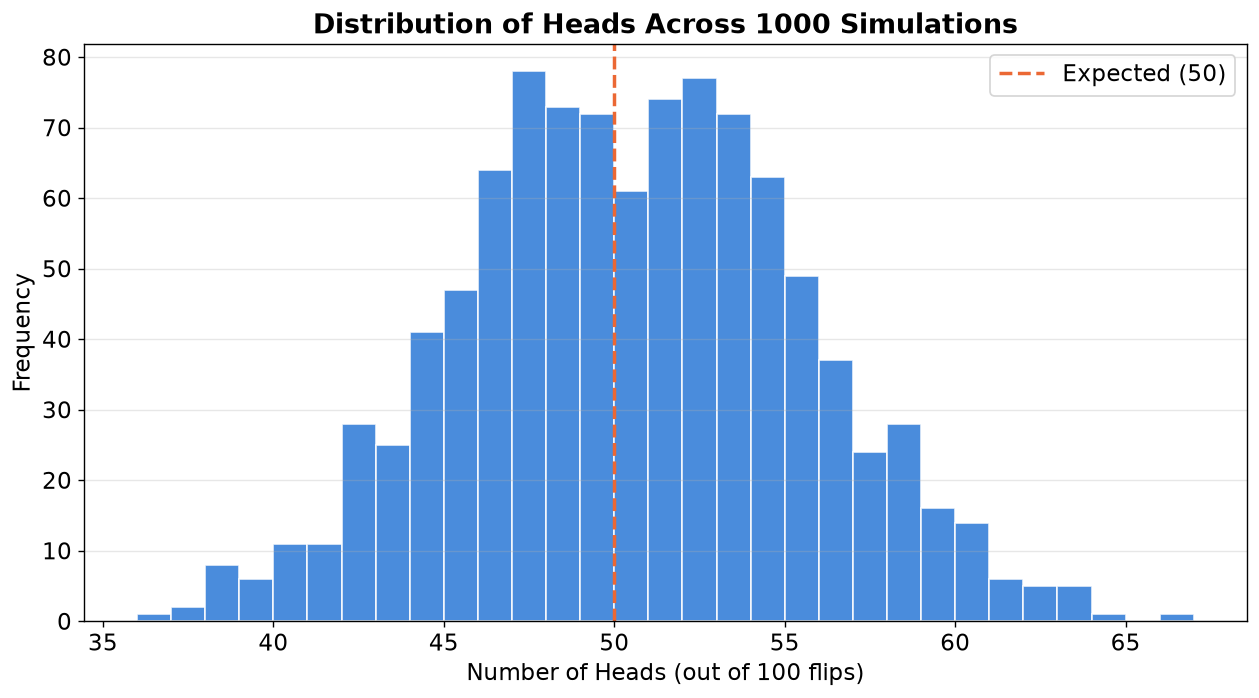

In [160]:
# CHART - read the picture, skip the code. (One thing to know about all of them:
# PALETTE comes from the Setup cell, so a colour always means the same thing.)

# Plot the distribution
plt.figure(figsize=(12, 6))
bin_min = min(results)
bin_max = max(results)
bins = range(bin_min, bin_max + 2)  # +2 to include the max value
plt.hist(results, bins=bins, edgecolor='white', alpha=0.85, color=PALETTE['blue'])
plt.axvline(50, color=PALETTE['orange'], linestyle='--', linewidth=2, label='Expected (50)')
plt.xlabel('Number of Heads (out of 100 flips)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Heads Across {sims} Simulations')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

**The Pattern Revealed!** Most results cluster around 50 heads, forming a bell curve.

### Understanding the Distribution

In [161]:
# Calculate statistics
mean_heads = np.mean(results)
std_heads = np.std(results)
min_heads = min(results)
max_heads = max(results)

print(f"Average heads: {mean_heads:.1f}")
print(f"Standard deviation: {std_heads:.1f}")
print(f"Minimum heads: {min_heads}")
print(f"Maximum heads: {max_heads}")

Average heads: 50.1
Standard deviation: 5.0
Minimum heads: 36
Maximum heads: 66


In [162]:
# How common are different results?
from collections import Counter

# Count how many times we got each result
counts = Counter(results)

# Most common results
print("Most common results:")
for heads, frequency in counts.most_common(5):
    print(f"  {heads} heads: {frequency} times ({frequency/sims*100:.1f}%)")

Most common results:
  47 heads: 78 times (7.8%)
  52 heads: 77 times (7.7%)
  51 heads: 74 times (7.4%)
  48 heads: 73 times (7.3%)
  49 heads: 72 times (7.2%)


In [163]:
# How likely are extreme results?
close_to_50 = sum(1 for r in results if 45 <= r <= 55)
very_extreme = sum(1 for r in results if r < 40 or r > 60)

print(f"\nResults between 45-55 heads: {close_to_50} ({close_to_50/sims*100:.1f}%)")
print(f"Extreme results (<40 or >60): {very_extreme} ({very_extreme/sims*100:.1f}%)")


Results between 45-55 heads: 730 (73.0%)
Extreme results (<40 or >60): 35 (3.5%)


**Key Insights:**
- Results close to the expected value are most common
- Values near the expected value occur frequently
- Extreme results (far from expected) are rare but possible
- **Randomness creates predictable patterns!**

**The Power of Simulation!**

Notice how the pattern becomes **smoother and clearer** with more simulations:
- The bell curve shape emerges clearly
- The mean stays very close to the expected value
- The standard deviation is consistent

**Key Discovery:** We can't predict a single coin flip, but we CAN predict the pattern of many flips!

This is the essence of simulation:
- Run an experiment many times
- Observe the distribution of outcomes
- Discover patterns that individual runs don't reveal
- Answer "what usually happens?" instead of "what will happen?"

**You've just used simulation to turn randomness into understanding!**

### The Law of Large Numbers - Watching an Average Settle

The bell curve showed the *spread* of many experiments. Here is the other half of the story: as we flip **more and more** coins, the running proportion of heads settles closer and closer to the true 0.5. That is the **Law of Large Numbers** - more data, less luck.

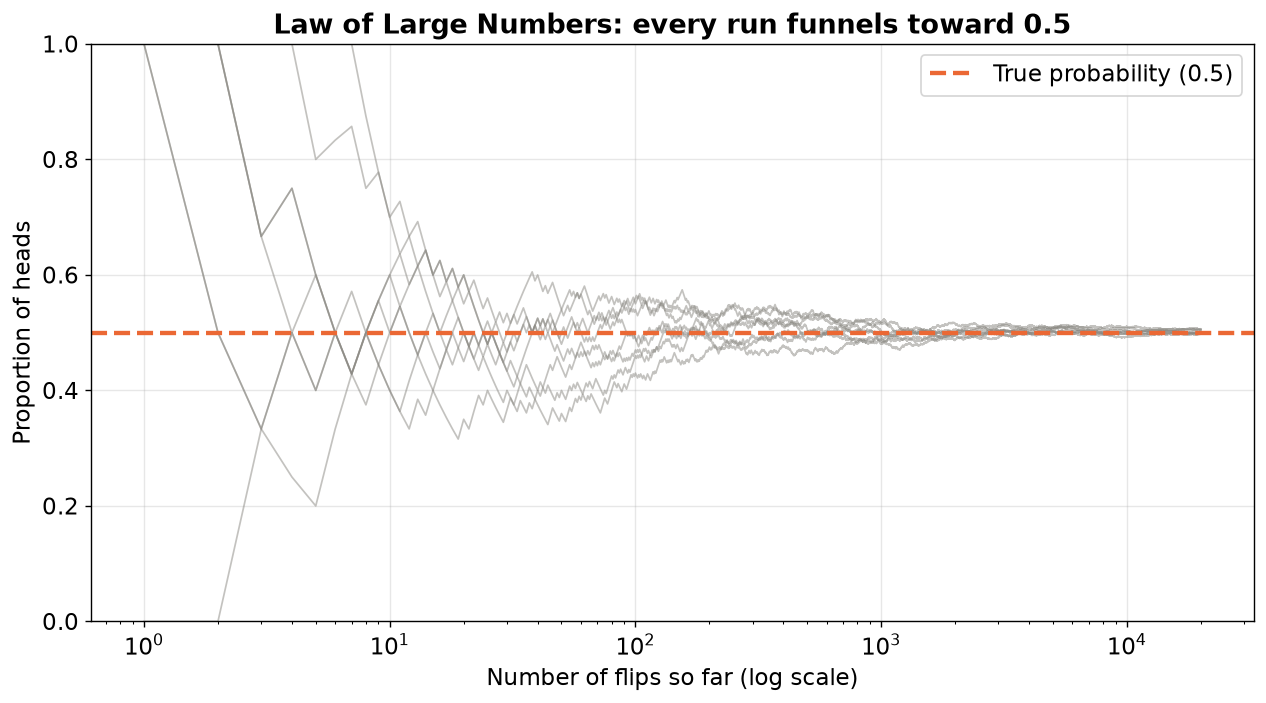

In [164]:
# CHART - read the picture, skip the code.
# Flip several long sequences and track the running proportion of heads in each
rng = np.random.default_rng(7)
n = 20_000

plt.figure(figsize=(12, 6))
for _ in range(8):
    flips = rng.integers(0, 2, size=n)                 # 0 = tails, 1 = heads
    running_proportion = np.cumsum(flips) / np.arange(1, n + 1)
    plt.plot(range(1, n + 1), running_proportion,
             color=PALETTE['muted'], alpha=0.5, linewidth=1)

plt.axhline(0.5, color=PALETTE['orange'], linestyle='--', linewidth=2.5,
            label='True probability (0.5)')
plt.xscale('log')                                       # log x: the early wobble is the story
plt.xlabel('Number of flips so far (log scale)')
plt.ylabel('Proportion of heads')
plt.title('Law of Large Numbers: every run funnels toward 0.5')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Early on, luck dominates** - the first handful of flips might be 70% heads. But after thousands of flips every run is pinned near 0.5. This is *why* casinos, insurers, and pollsters trust large numbers: a single outcome is unpredictable, yet the average is almost guaranteed.

### Simulation Meets Theory - The Central Limit Theorem

We *simulated* our way to that bell curve by brute force. But mathematicians can **predict** its exact shape without flipping a single coin. For `n` flips of a coin with heads-probability `p`:

- center (mean): `n * p`
- spread (standard deviation): `sqrt(n * p * (1 - p))`

That prediction is the **Central Limit Theorem**. Let's lay the math on top of our simulation and see how well they agree.

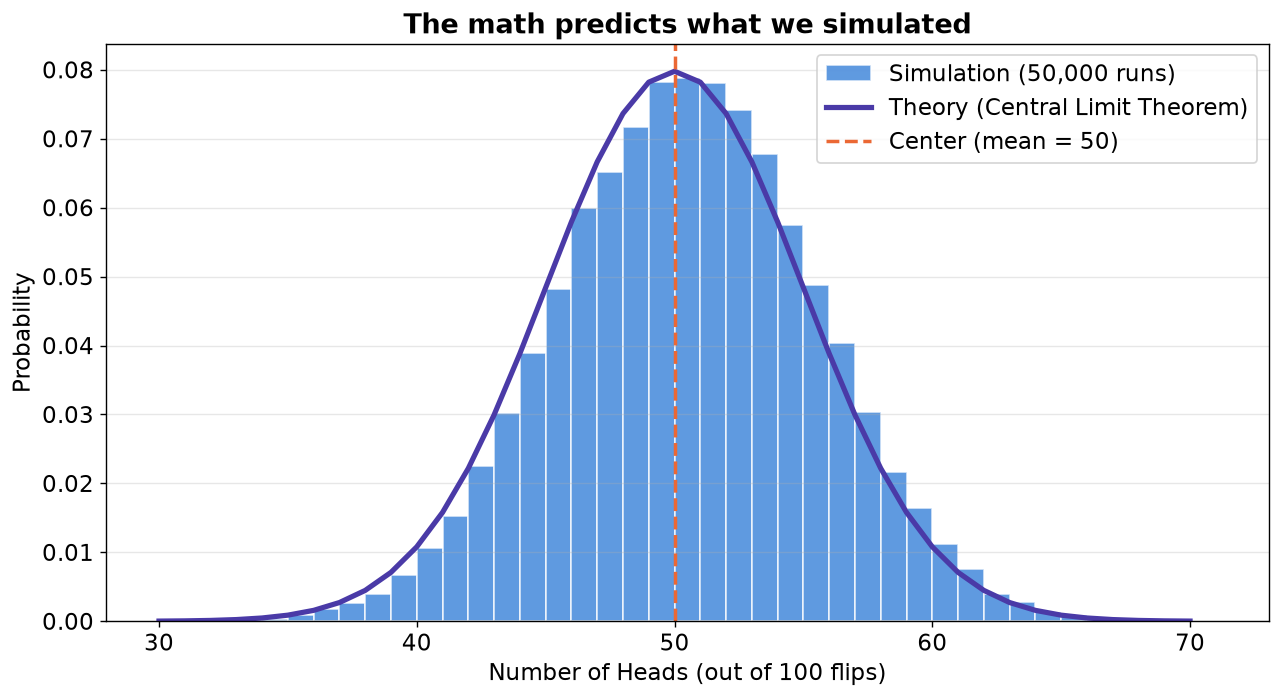

Simulated mean: 50.03   |   Theory says: 50.00
Simulated std:   4.99   |   Theory says:  5.00


In [165]:
# CHART - read the picture, skip the code. Exception: mu and sigma below are the two
# formulas from the cell above, written out.
# Simulate 100-flip experiments the fast way, then overlay the theoretical curve
rng = np.random.default_rng(1)
n_flips, p, trials = 100, 0.5, 50_000

# np.random.binomial does the whole experiment: "100 flips at prob p, repeated 50,000 times"
heads = rng.binomial(n_flips, p, size=trials)

# The theory: a Normal (bell) curve described by just two numbers
mu = n_flips * p                              # center
sigma = (n_flips * p * (1 - p)) ** 0.5        # spread
x = np.arange(30, 71)
theory = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

plt.figure(figsize=(12, 6))
plt.hist(heads, bins=range(30, 72), density=True, alpha=0.75,
         color=PALETTE['blue'], edgecolor='white', label='Simulation (50,000 runs)')
plt.plot(x, theory, color=PALETTE['violet'], linewidth=3,
         label='Theory (Central Limit Theorem)')
plt.axvline(mu, color=PALETTE['orange'], linestyle='--', linewidth=2,
            label=f'Center (mean = {mu:.0f})')
plt.xlabel('Number of Heads (out of 100 flips)')
plt.ylabel('Probability')
plt.title('The math predicts what we simulated')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Simulated mean: {heads.mean():5.2f}   |   Theory says: {mu:5.2f}")
print(f"Simulated std:  {heads.std():5.2f}   |   Theory says: {sigma:5.2f}")

**They line up almost perfectly.** Two very different roads - flipping millions of virtual coins, or evaluating one formula - arrive at the same bell curve. That is the payoff of this whole notebook:

- Don't know the math? **Simulate it.**
- Know the math? **Simulation confirms it.**

Real data science leans on both: simulation to *explore*, theory to *explain*.

## Repetition With A Goal

*~4 min · 5 cells · **required** - sets `n_simulations` and the baseline time that every later speedup is measured against*

We already **know the answer**: flip 500 coins and you should average about 250 heads. That
makes this the perfect thing to simulate - we can check the computer's answer against the math.

So let's run it **100,000 times**. Two things come out of that one run, and the rest of the
notebook is built on both of them:

1. **A statistical result** - the distribution of outcomes, and how tightly it hugs 250.
2. **A stopwatch reading** - how long the obvious, straightforward way to write this actually takes.

The first one is the science. The second one turns out to be the start of a much longer story.


In [166]:
# Set up our simulation parameters
expected = 250            # Half of 500 flips
n_simulations = 100_000   # Run 100,000 simulations

print(f"Running {n_simulations:,} simulations")
print(f"Each simulation flips 500 coins")
print(f"Expected average: {expected} heads")
print(f"Total coin flips: {n_simulations * 500:,}")

Running 100,000 simulations
Each simulation flips 500 coins
Expected average: 250 heads
Total coin flips: 50,000,000


In [167]:
import time as time_module

# Approach 1: One-at-a-time (baseline)
print("Running baseline approach...")
start_time = time_module.time()

all_results = []
for _ in range(n_simulations):
    result = count_heads(500)
    all_results.append(result)

end_time = time_module.time()
elapsed_time = end_time - start_time

# Calculate results
average = np.mean(all_results)
difference = abs(average - expected)

print(f"✓ Completed {len(all_results):,} simulations")
print(f"  Average: {average:.6f} heads")
print(f"  Difference from expected: {difference:.6f}")
print(f"  Time: {elapsed_time:.2f} seconds")
print(f"  Rate: {len(all_results)/elapsed_time:.0f} sims/sec")

Running baseline approach...


✓ Completed 100,000 simulations
  Average: 249.959180 heads
  Difference from expected: 0.040820
  Time: 18.19 seconds
  Rate: 5498 sims/sec


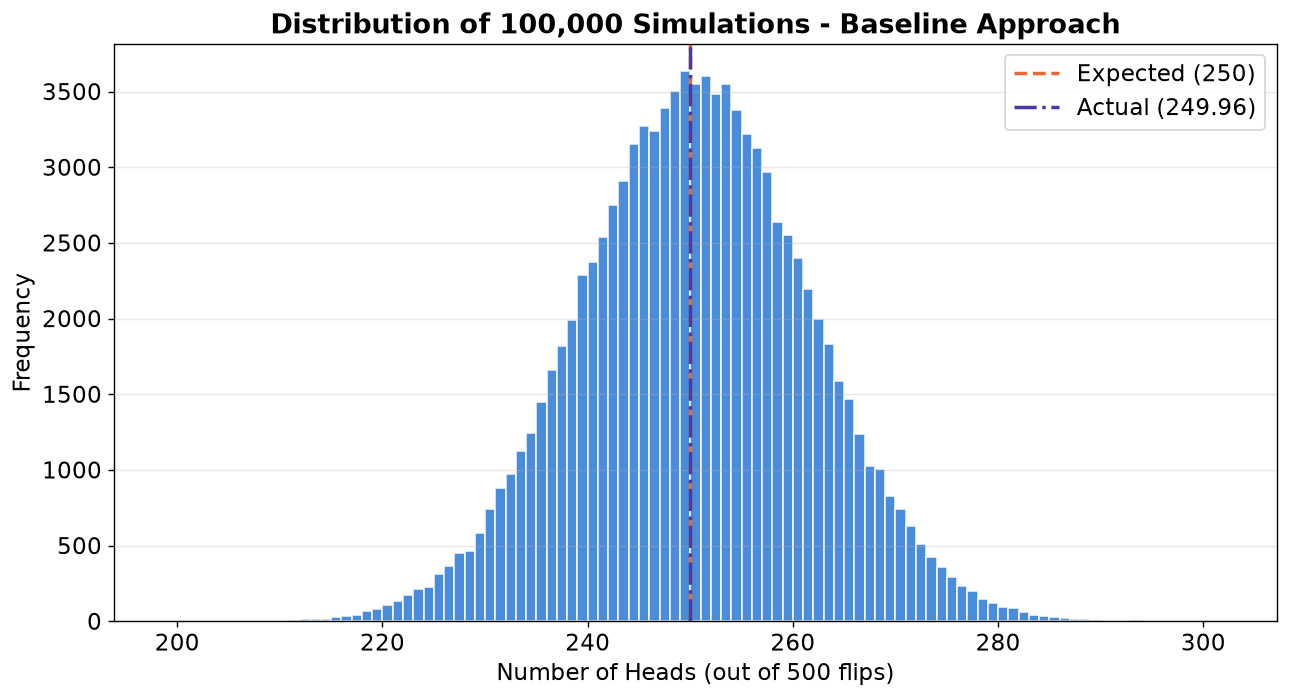

In [168]:
# CHART - read the picture, skip the code.
# Visualize the distribution
plt.figure(figsize=(12, 6))

bin_min = min(all_results)
bin_max = max(all_results)
bins = range(bin_min, bin_max + 2)

plt.hist(all_results, bins=bins, edgecolor='white', alpha=0.85, color=PALETTE['blue'])
plt.axvline(expected, color=PALETTE['orange'], linestyle='--', linewidth=2, label=f'Expected ({expected})')
plt.axvline(average, color=PALETTE['violet'], linestyle='-.', linewidth=2, label=f'Actual ({average:.2f})')
plt.xlabel('Number of Heads (out of 500 flips)')
plt.ylabel('Frequency')
plt.title(f'Distribution of {len(all_results):,} Simulations - Baseline Approach')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

**What We Learned:**

1. **Large numbers stabilize.** With this many simulations our average lands very close to the
   expected value - and the histogram is a clean bell curve, not a jagged mess.
2. **The Law of Large Numbers in action.** The more simulations we run, the closer the average
   creeps to the theoretical answer.
3. **Predictable patterns come out of randomness.** Any single flip is unknowable. The shape of
   fifty million of them is not.

---

**Now look at the clock.**

The science is finished - we got the right answer. But that took **a real number of seconds**,
and it did so on a problem small enough to fit in a notebook. Scale it up the way a real
simulation would be - a million experiments, or ten thousand coins each - and the same code
takes hours.

The rest of this notebook asks a different question. Not *"what is the answer?"* but
**"how fast can we get the same answer?"** - and the surprising part is that we will never
change the math. Every single approach below produces the same 250. All we ever change is how
we ask the computer to do it.

## Make Iterations Faster

*~27 min · 59 cells · **the payoff.** Cut whatever you must in order to reach this.*

Same simulation. Same answer. Seven ways to compute it, each one trying to beat the one before.

Most of them will. **Approach 5 might not** - it is the one approach whose payoff depends on
hardware we can't predict from here, and on some machines it lands *slower* than approach 4. If
that happens on yours, nothing is broken: it is the most useful result in the section, and we
stop and work out why.

| | Approach | The one thing that changes |
| --- | --- | --- |
| 1 | Baseline | flip one coin at a time, as words | 
| 2 | Numbers | a coin becomes `0`/`1` instead of `'heads'`/`'tails'` |
| 3 | Batched | flip coins in groups instead of singly |
| 4 | Vectorized | NumPy flips all 500 in one operation |
| 5 | Parallel | every CPU core works at once |
| 6 | JAX (CPU) | compile the whole simulation to machine code |
| 7 | JAX (GPU) | run that same compiled code on a graphics card |

Then a **Super Bonus** at the very end that beats all seven with no libraries at all.


### The Method: One Change At A Time

Speed work goes wrong when you change three things and can't say which one helped. So this
section follows one rule, strictly:

> **Each approach changes exactly one thing from the approach before it.**

That rule costs us something - approach 2 will look like a total waste of time - and it buys us
something much more valuable: at the end, we can say *why* the fast version is fast.

After every approach we redraw the same three-panel scoreboard - **execution time**,
**throughput**, and **speedup vs the baseline** - with every method tried so far. The newest
contender is spotlighted; the earlier ones fade back so you can watch the race build.

Along the way, three approaches have a **dial** on them - a number somebody had to choose. Each
of those gets its own short experiment, because "what number should I use?" is a question you
will face constantly, and the answer is always the same: *measure it.*

Before the first chart, two things about *how* it's drawn are worth a minute - both are choices,
and both change what you're able to see.

#### Reading a Log Scale (probably a new one)

Our times are about to span from **tens of seconds** down to **hundredths of a second** -
something like a **thousandfold**, though the exact spread depends on the machine you're on.
That range breaks an ordinary axis, so the scoreboard uses a **log scale**. Here's the whole idea:

| | A normal (linear) axis | A **log** axis |
| --- | --- | --- |
| Equal steps mean | equal **amounts** | equal **multiples** |
| Ticks might read | 0, 5, 10, 15 | 0.01, 0.1, 1, 10 |
| Each tick is | +5 more than the last | **10x** the last |

So on a log axis, **"one tick to the right" always means "ten times bigger"** - no matter
where on the axis you are. Two ticks is 100x. Three is 1000x.

Two consequences to keep in your head:

- **It's the only way to see everything at once.** On a linear axis, once one point sits out at
  tens of seconds, everything under a second is squashed into a line at the left edge - all our
  best work becomes invisible.
- **It makes huge differences look modest.** A dot that sits only a little to the left of
  another can easily be 5x or 10x faster. Your eye will under-read the gap, which is why every
  dot on the scoreboard is also **labeled with its actual number**. When they disagree, trust
  the number.

There's also **no zero on a log axis** - you can keep dividing by ten forever and never arrive.
That's why the scoreboard plots **dots and not bars**: a bar means "compare my length, measured
from zero," and there's no zero here to measure from. A dot only claims a position, which is a
promise this axis can actually keep.

The chart below makes both points at once - same five numbers, drawn twice. Those five are
stand-ins, picked to look like a run of this section; the real ones we measure in a moment.

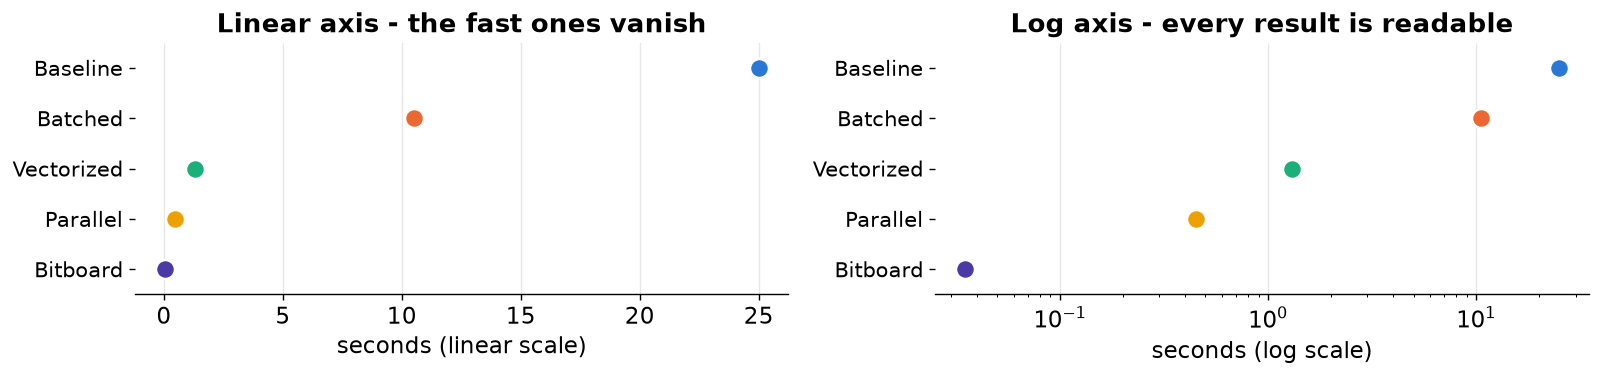

Bitboard is 714x faster than Baseline.
On the left you cannot even find it. On the right it is about 3 ticks away - and
3 ticks means 10 x 10 x 10 = 1000x, which is the right ballpark.


In [169]:
# CHART - read the picture, skip the code.
# Same five (made-up but realistic) times, drawn on both kinds of axis.
demo_names = ["Baseline", "Batched", "Vectorized", "Parallel", "Bitboard"]
demo_times = [25.0, 10.5, 1.3, 0.45, 0.035]
demo_colors = [PALETTE["blue"], PALETTE["orange"], PALETTE["aqua"],
               PALETTE["yellow"], PALETTE["violet"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
for ax, scale, title in zip(axes, ("linear", "log"),
                            ("Linear axis - the fast ones vanish",
                             "Log axis - every result is readable")):
    ax.set_xscale(scale)
    for y, (v, c) in enumerate(zip(demo_times, demo_colors)):
        ax.plot(v, y, "o", markersize=11, color=c,
                markeredgecolor="white", markeredgewidth=1.5)
    ax.set_yticks(range(len(demo_names)))
    ax.set_yticklabels(demo_names, fontsize=12)
    ax.set_ylim(len(demo_names) - 0.5, -0.5)
    ax.set_xlabel(f"seconds ({scale} scale)")
    ax.set_title(title, fontweight="bold", fontsize=15)
    ax.grid(axis="x", alpha=0.3)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Bitboard is {25.0 / 0.035:.0f}x faster than Baseline.")
print("On the left you cannot even find it. On the right it is about 3 ticks away - and")
print("3 ticks means 10 x 10 x 10 = 1000x, which is the right ballpark.")

In [170]:
# =====================================================================
#  PLUMBING - SCAFFOLDING FOR THE RACE (read the output, skip the code)
#
#  This one cell holds all the *plumbing* the speed race relies on:
#    1. the scoreboard chart          (add_approach / show_race)
#    2. picking JAX's backend for THIS machine (Mac / Linux / Windows)
#    3. cataloging the hardware we see (CPU always, GPU when present)
#
#  Every lesson after this stays tiny: change the algorithm, time it,
#  call add_approach(...) + show_race(). Peek in here only if you're
#  curious how the chart is drawn or how the GPU is detected.
# =====================================================================
import os, glob, platform, subprocess
from matplotlib.ticker import NullFormatter

# ---- 0. Honest timing -------------------------------------------------------
def best_time(fn, repeats=5):
    """Run fn() several times and keep the FASTEST run.

    A computer is never doing only your work - the OS, the browser, and this
    notebook's own kernel all interrupt. Those interruptions can only ever make a
    measurement *slower*, never faster, so the minimum of several runs is the
    closest thing to "how long does this actually take." We use it for the side
    experiments, where one noisy point would break the shape of a curve."""
    best = float("inf")
    for _ in range(repeats):
        start = time_module.perf_counter()
        fn()
        best = min(best, time_module.perf_counter() - start)
    return best

# ---- 0b. Where the time went ------------------------------------------------
# A total is one number, and one number hides the story. As the approaches get
# cleverer they stop being pure math and start needing MACHINERY: worker processes
# to start, a function to compile, a device to copy answers back from. We record
# those parts as we measure them, and take them apart at the very end in
# "Where The Time Really Goes".
TIME_PARTS = {}   # name -> {"setup", "moving", "math", "setup_label", "color"}

def record_parts(name, math, moving=0.0, setup=0.0, setup_label="", color=None):
    """Split one approach's time into machinery vs the numerical work we wanted.

    setup   - paid ONCE and then reused: compiling, starting workers, waking a GPU
    moving  - paid EVERY run but isn't math: handing out work, copying results back
    math    - paid EVERY run, and is the whole reason we ran anything
    """
    TIME_PARTS[name] = {"setup": max(setup, 0.0), "moving": max(moving, 0.0),
                        "math": max(math, 0.0), "setup_label": setup_label,
                        "color": color or PALETTE["muted"]}

def fmt_seconds(v):
    """Same number of useful digits whether it's 14 seconds or 14 milliseconds."""
    if v >= 10:    return f"{v:.1f}s"
    if v >= 1:     return f"{v:.2f}s"
    if v >= 0.01:  return f"{v:.3f}s"
    return f"{v * 1000:.1f}ms"

# ---- 1. The scoreboard ------------------------------------------------------
RESULTS = []   # ordered list of {name, seconds, sims, color}

def add_approach(name, seconds, color, sims=None):
    """Record an approach's time. Re-running a cell REPLACES its entry, so the
    scoreboard never grows duplicate rows."""
    sims = n_simulations if sims is None else sims
    RESULTS[:] = [r for r in RESULTS if r["name"] != name]
    RESULTS.append({"name": name, "seconds": seconds, "sims": sims, "color": color})

def show_race():
    """Draw the scoreboard so far - time, throughput, and speedup side by side.
    The newest approach is spotlighted; earlier ones fade back for comparison.

    Why DOTS and not bars? A bar says "compare my length, measured from zero."
    A log axis has no zero on it, so a bar drawn there has an arbitrary length
    and quietly lies. A dot only claims a *position* - which is exactly what a
    log axis can show honestly."""
    baseline = RESULTS[0]["seconds"]
    names    = [r["name"].replace("\n", " ") for r in RESULTS]
    times    = [r["seconds"] for r in RESULTS]
    rates    = [r["sims"] / r["seconds"] for r in RESULTS]
    speedups = [baseline / r["seconds"] for r in RESULTS]
    colors   = [r["color"] for r in RESULTS]
    newest   = RESULTS[-1]
    n = len(RESULTS)
    rows   = range(n)
    alphas = [0.55] * (n - 1) + [1.0]        # spotlight the newcomer
    sizes  = [9] * (n - 1) + [15]
    fig = plt.figure(figsize=(15, 1.8 + 0.55 * n))
    panels = [
        ("Execution Time",      times,    "seconds (log scale)",       "{:.3g}s"),
        ("Throughput",          rates,    "sims / second (log scale)", "{:,.0f}"),
        ("Speedup vs Baseline", speedups, "times faster (log scale)",  "{:.2f}x"),
    ]
    for pos, (title, vals, xlabel, fmt) in enumerate(panels, start=1):
        ax = fig.add_subplot(1, 3, pos)
        ax.set_xscale("log")                 # spans reach ~1000x - log keeps every dot readable
        for y in rows:                       # dotted rule = "which row am I on", not a value
            ax.axhline(y, color=PALETTE["muted"], alpha=0.25,
                       linewidth=0.8, linestyle=":", zorder=0)
        for y, v, c, a, size in zip(rows, vals, colors, alphas, sizes):
            ax.plot(v, y, "o", markersize=size, color=c, alpha=a,
                    markeredgecolor="white", markeredgewidth=1.5, zorder=3)
            ax.annotate(fmt.format(v), (v, y), textcoords="offset points",
                        xytext=(0, 11), ha="center", fontweight="bold", fontsize=11)
        lo, hi = min(vals) / 4, max(vals) * 4       # room for the value labels
        if hi / lo < 100:                           # early on the spread is small; widen
            mid = (lo * hi) ** 0.5                  # it so the tick labels stay legible
            lo, hi = mid / 10, mid * 10
        ax.set_xlim(lo, hi)
        ax.xaxis.set_minor_formatter(NullFormatter())   # powers of ten only - no clutter
        ax.set_yticks(list(rows)); ax.set_yticklabels(names, fontsize=12)
        ax.set_ylim(n - 0.4, -0.9)           # first approach on top, newest at the bottom
        ax.set_xlabel(xlabel); ax.set_title(title, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        if title.startswith("Speedup"):
            ax.axvline(1.0, color=PALETTE["muted"], linestyle="--", linewidth=1)
    label = newest["name"].replace("\n", " ")
    plural = "" if n == 1 else "es"
    fig.suptitle(f"The race so far - {n} approach{plural}   "
                 f"(newest: {label}, {baseline / newest['seconds']:.2f}x vs baseline)",
                 fontweight="bold", fontsize=17)
    plt.tight_layout()
    plt.show()

# ---- 2. Pick JAX's backend for THIS machine (must run BEFORE importing jax) --
from importlib.metadata import version, PackageNotFoundError
def _installed(pkg):
    try:
        version(pkg); return True
    except PackageNotFoundError:
        return False

_system, _machine = platform.system(), platform.machine()
if _system == "Darwin" and _machine == "arm64":
    # macOS / Apple Silicon: light up the Metal GPU via jax-mps when it's installed.
    os.environ.setdefault("JAX_PLATFORMS", "cpu,mps" if _installed("jax-mps") else "cpu")
elif _system == "Windows":
    os.environ.setdefault("JAX_PLATFORMS", "cpu")   # native Windows has no JAX GPU (use WSL2)
elif _system == "Linux" and not glob.glob("/dev/nvidia[0-9]*"):
    # Linux with JAX's CUDA build installed but no NVIDIA card in the machine.
    # Ask for CPU up front: otherwise the CUDA plugin tries to start, fails, and
    # prints an alarming (but harmless) traceback before falling back to CPU anyway.
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
# Linux WITH an NVIDIA card: let JAX auto-detect so it uses the GPU.

# ---- 3. Catalog the hardware (CPU always; GPU when present) ------------------
def _mac_chip():
    """Marketing name of the Apple Silicon chip, e.g. 'Apple M4 Pro' (macOS only)."""
    try:
        return subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"],
                              capture_output=True, text=True).stdout.strip()
    except Exception:
        return None

def _mac_gpu_cores():
    """GPU core count from system_profiler (macOS only); None if unavailable."""
    try:
        out = subprocess.run(["system_profiler", "SPDisplaysDataType"],
                             capture_output=True, text=True).stdout
        for line in out.splitlines():
            if "Total Number of Cores" in line:
                return int(line.split(":")[1].strip())
    except Exception:
        pass
    return None

def _physical_cores():
    """Real, separate cores - not hyperthreads. None if we can't find out."""
    try:
        if _system == "Darwin":
            out = subprocess.run(["sysctl", "-n", "hw.physicalcpu"],
                                 capture_output=True, text=True, timeout=10)
            return int(out.stdout.strip())
        if _system == "Linux":
            # A core is unique per (socket, core id); hyperthreads repeat the pair.
            seen, phys, core = set(), None, None
            with open("/proc/cpuinfo") as fh:
                for line in fh:
                    if line.startswith("physical id"): phys = line.split(":")[1].strip()
                    elif line.startswith("core id"):   core = line.split(":")[1].strip()
                    elif not line.strip() and phys is not None and core is not None:
                        seen.add((phys, core)); phys = core = None
            return len(seen) or None
        if _system == "Windows":
            out = subprocess.run(
                ["powershell", "-NoProfile", "-Command",
                 "(Get-CimInstance Win32_Processor | "
                 "Measure-Object -Property NumberOfCores -Sum).Sum"],
                capture_output=True, text=True, timeout=30)
            return int(out.stdout.strip())
    except Exception:
        pass
    return None

def cpu_topology():
    """Three different numbers that all get called 'cores'. See the parallel section."""
    logical = os.cpu_count() or 1
    # process_cpu_count (Python 3.13+) respects CPU limits set on this process -
    # which is how a container or a Colab runtime can hand you fewer than the box has.
    usable = getattr(os, "process_cpu_count", lambda: None)() or logical
    return {"logical": logical, "physical": _physical_cores(), "usable": usable}

def cpu_summary():
    """'What and how many' for the CPU doing the work."""
    chip = _mac_chip() or platform.processor() or platform.machine()
    return f"{chip}, {os.cpu_count()} logical CPUs"

def nvidia_card():
    """The NVIDIA GPU's own name via nvidia-smi, whether or not JAX can use it.
    JAX only sees a GPU it has a plugin for; the driver sees the card regardless."""
    try:
        out = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                              "--format=csv,noheader"],
                             capture_output=True, text=True, timeout=15)
        if out.returncode == 0 and out.stdout.strip():
            return out.stdout.strip().splitlines()[0].strip()
    except Exception:
        pass
    return None

def device_summary(dev):
    """'What and how big' for a JAX device - type plus memory when reported."""
    mem = ""
    try:
        limit = dev.memory_stats().get("bytes_limit")
        if limit:
            mem = f", {limit / 1e9:.1f} GB memory"
    except Exception:
        pass
    if dev.platform == "mps":                     # Metal reports a generic 'gpu' kind...
        chip = _mac_chip() or "Apple Silicon"     # ...so name the actual chip + GPU cores
        cores = _mac_gpu_cores()
        label = f"{chip} GPU" + (f", {cores} GPU cores" if cores else "")
        return f"{label}{mem}"
    return f"{dev.device_kind}{mem}"               # CUDA already gives a descriptive kind

try:
    import jax
    import jax.numpy as jnp
    from jax import random as jax_random
    JAX_AVAILABLE = True
    cpu_device = jax.devices("cpu")[0]
    # An "accelerator" is any non-CPU device: Metal ('mps') on Mac, CUDA ('gpu') on Linux.
    ACCELERATOR = None
    for _plat in ("mps", "gpu", "cuda", "tpu"):
        try:
            _found = jax.devices(_plat)
        except Exception:
            continue
        if _found:
            ACCELERATOR = _found[0]
            break
except ImportError:
    JAX_AVAILABLE, cpu_device, ACCELERATOR = False, None, None

# ---- A one-line snapshot of what this machine brings to the race ------------
print(f"Environment: {_system} ({_machine})")
print(f"CPU: {cpu_summary()}")
if JAX_AVAILABLE:
    print(f"JAX {jax.__version__} ready.")
    if ACCELERATOR is not None:
        print(f"GPU: {device_summary(ACCELERATOR)}  -> the optional GPU section will run.")
    else:
        # No GPU *that JAX can use*. That is not the same as "no GPU" - say which.
        card = nvidia_card()
        if card and _system == "Windows":
            print(f"GPU: {card} is installed, but JAX cannot use it on native Windows.")
            print("     (JAX ships CUDA support for Linux only - see the readme for WSL2")
            print("      or Google Colab. The race runs CPU-only; the GPU section skips.)")
            print("      readme: https://github.com/statmike/teaching-python")
        elif card:
            print(f"GPU: {card} is installed, but JAX's CUDA build is not.")
            print("     Run: uv sync --extra gpu-nvidia   (the GPU section skips for now.)")
        elif _system == "Darwin" and _machine == "arm64" and not _installed("jax-mps"):
            print("GPU: this Mac has one, but the JAX Metal plugin is not installed.")
            print("     Run: uv sync --extra gpu-apple    (the GPU section skips for now.)")
        else:
            print("GPU: none found - the race runs CPU-only (the GPU section will skip).")
else:
    print("JAX not installed - the JAX / GPU approaches will be skipped.")

Environment: Linux (x86_64)
CPU: x86_64, 32 logical CPUs
JAX 0.10.2 ready.
GPU: none found - the race runs CPU-only (the GPU section will skip).


### Approach 1 · One Coin At A Time

Our starting line is the code we already wrote and already ran, up in the simulation section:

```python
def count_heads(n_flips):
    heads = 0
    for _ in range(n_flips):
        if random.choice(['heads', 'tails']) == 'heads':
            heads += 1
    return heads
```

Nothing is wrong with it. It is exactly how you'd explain a coin flip to a person, and that is
worth a great deal - you can read it and immediately believe it. It is also doing **fifty
million** trips around a Python loop, each one asking Python to pick between two *words* and
compare one of them against another word.

Every approach that follows is measured against this. It's the 1.00x on every chart.

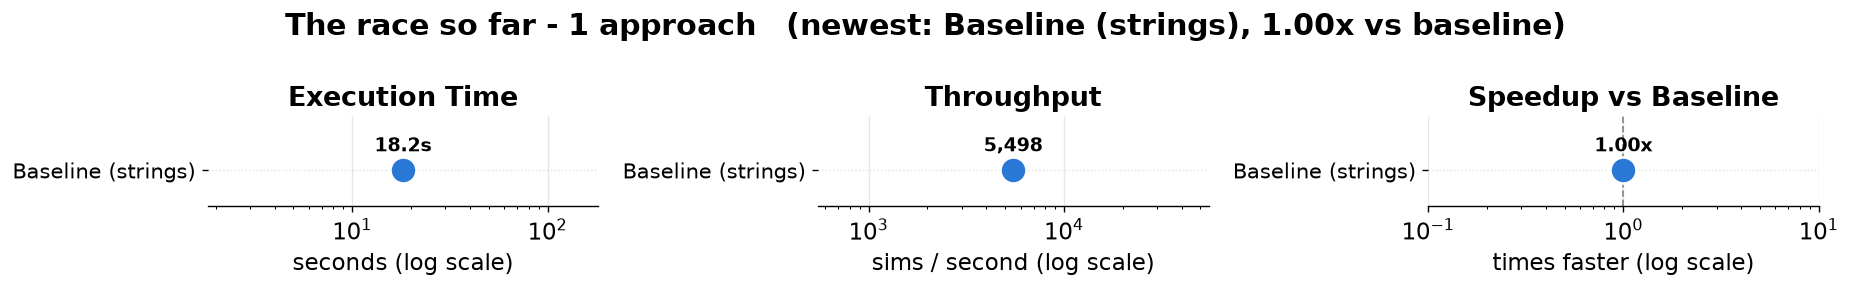

In [171]:
# The baseline is our first contender - the starting line every method races against.
add_approach("Baseline\n(strings)", elapsed_time, PALETTE["blue"])
show_race()

### Approach 2 · Change Nothing But The Coin

Here is the smallest change we can possibly make. Same loop. Same `random.choice`. Same number
of flips. The only difference is what a coin **is**:

| | Baseline | Approach 2 |
| --- | --- | --- |
| A coin is | `'heads'` / `'tails'` | `0` / `1` |
| Counting a head means | `if ... == 'heads': heads += 1` | `heads += flip` |

Comparing two words *feels* more expensive than adding a number, so this should be a free win.

Make a prediction before you run it. How much faster?

In [172]:
# Approach 2: identical to the baseline, except a coin is a NUMBER
def count_heads_ints(n_flips):
    """Same loop as count_heads() - but a coin is 0 or 1, not a word."""
    heads = 0
    for _ in range(n_flips):
        heads += random.choice([0, 1])     # a 1 IS a head, so just add it
    return heads

print("Running the numbers approach...")
start_time = time_module.time()

all_results_ints = [count_heads_ints(500) for _ in range(n_simulations)]

elapsed_time_ints = time_module.time() - start_time
average_ints = np.mean(all_results_ints)

print(f"✓ Completed {len(all_results_ints):,} simulations")
print(f"  Average: {average_ints:.6f} heads   (expected {expected})")
print(f"  Time: {elapsed_time_ints:.2f} seconds")
print(f"  Rate: {len(all_results_ints)/elapsed_time_ints:,.0f} sims/sec")
print(f"  vs baseline: {elapsed_time / elapsed_time_ints:.2f}x")

Running the numbers approach...


✓ Completed 100,000 simulations
  Average: 249.938120 heads   (expected 250)
  Time: 17.07 seconds
  Rate: 5,859 sims/sec
  vs baseline: 1.07x


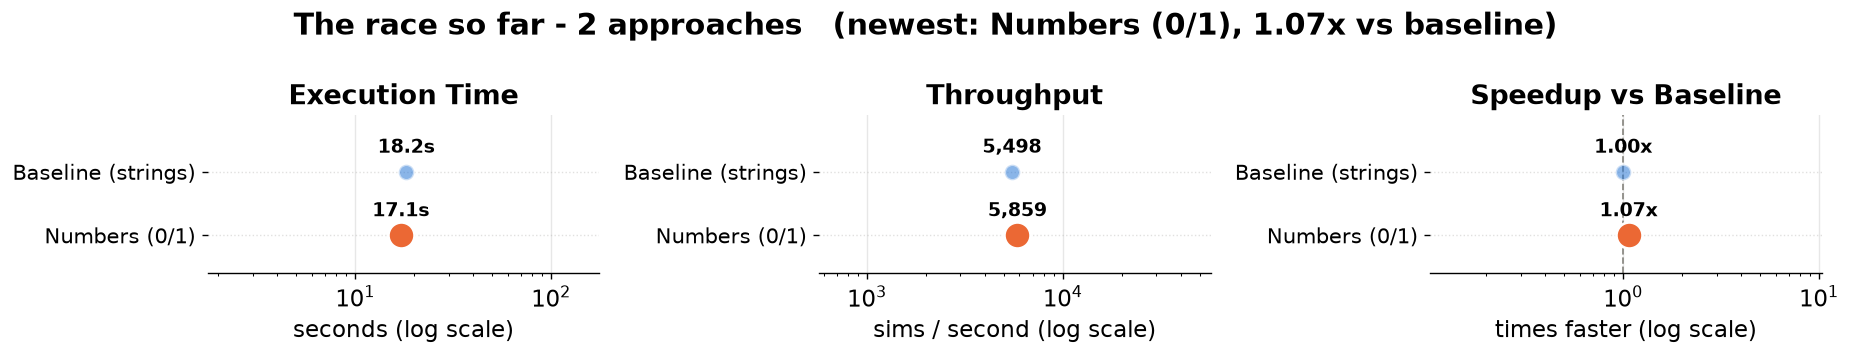

In [173]:
# Numbers join the race - redraw the scoreboard
add_approach("Numbers\n(0/1)", elapsed_time_ints, PALETTE["orange"])
show_race()

#### The Dot That Didn't Move

Almost nothing happened. Whatever number you got, treat it as a tie: these two cells each take
tens of seconds, and anything else the computer decides to do in that window lands in our
stopwatch. Run them again and the winner can easily swap. (This is also why the side experiments
below use `best_time()` - keeping the *fastest* of several runs is how you see the code instead
of the interruptions.)

**This is the most useful result in the whole section,** and it is worth sitting with:

- Our intuition said "words are heavy, numbers are light." Our intuition was **wrong**.
- The real cost isn't the comparison at all - it's the *fifty million trips around a Python
  loop*, and we didn't touch those. Every flip still costs one `random.choice()` call, one
  Python function call, one loop iteration. Swapping the payload doesn't change the postage.
- Had we bundled this change in with the next one, we'd have credited it with a speedup it
  never earned. That is exactly why we're changing one thing at a time.

**So why keep it?** Because of what it makes *possible*:

> You **cannot** hand a list of `'heads'` and `'tails'` to NumPy and add it up.
> You **can** hand it a list of `0`s and `1`s - and later, a GPU array of them.

Representation matters far less for what it *costs* and far more for the **doors it opens**.
Approach 2 bought us no speed. It bought us approaches 3 through 7.

### Approach 3 · Flip In Batches

Approach 2 told us the expensive part is the **loop itself**, not what's inside it. Fifty million
trips, and each trip costs the same fixed overhead: check the loop condition, call a function,
return a value, come back around.

So attack the trip count. `random.choices(k=100)` flips **100 coins in a single call**. Do that
five times and a 500-flip simulation costs 5 trips instead of 500.

**The one thing that changes:** how many coins we ask for per call.

That's a 100-fold cut in loop overhead, so this should be enormous. Make another prediction.

#### First, One Line Worth Questioning

To batch, we have to add up 100 numbers at a time. Python gives us two ways to do that:

| | |
| --- | --- |
| `sum(batch)` | Python's builtin |
| `np.sum(batch)` | NumPy's version |

NumPy is *the* fast-array library, and adding up numbers is exactly what it is for, so `np.sum()`
looks like the obvious pick. Almost everyone reaches for it here.

We have a stopwatch, though, and checking costs three lines.

Two of those lines start with `lambda:`. `best_time()` needs the **work**, not the answer:
`sum(one_batch)` on its own would be finished before `best_time()` ever saw it. `lambda:` builds a
throwaway function out of whatever follows, right where the argument goes, so
`lambda: sum(one_batch)` is *the instruction to add* rather than the total. Each run repeats that
instruction 20,000 times, because one addition is far too fast to time, and we divide back out at
the end. Where the work is longer we give it a name with `def` and hand `best_time()` the name
instead. A number after the function sets how many runs.

**Predict first: which one wins, and by how much?**

In [174]:
# Two ways to add up one batch of 100 coins. Same answer - is one faster?
one_batch = random.choices([0, 1], k=100)
reps = 20_000

t_builtin = best_time(lambda: [sum(one_batch)    for _ in range(reps)])
t_numpy   = best_time(lambda: [np.sum(one_batch) for _ in range(reps)])

print(f"sum(batch)      {t_builtin / reps * 1e6:6.2f} microseconds per call")
print(f"np.sum(batch)   {t_numpy   / reps * 1e6:6.2f} microseconds per call")
print(f"\nThe builtin is {t_numpy / t_builtin:.1f}x faster on a list this size.")

sum(batch)        0.49 microseconds per call
np.sum(batch)     8.07 microseconds per call

The builtin is 16.5x faster on a list this size.


**The builtin wins, and it isn't close.**

`np.sum()` cannot add up a Python list as it stands. Before it can add anything it has to walk the
list, work out a data type, and copy all 100 values into an array it owns - and that copy costs far
more than the addition ever will. The builtin `sum()` just walks the list once, adding as it goes.

This is the first sighting of the idea the rest of the section is built on: **a NumPy call carries
a fixed cost that has nothing to do with how much data you hand it.** On 100 loose Python integers
that fixed cost *is* the entire bill. On a large array it vanishes into the noise. We'll measure
exactly where the crossover sits in Approach 4.

> **"Use NumPy, it's faster" is not a rule.** It's a rule with a size attached - and we just found
> a size where it's false. An optimization you didn't measure is a guess wearing a lab coat.

So: `sum()` inside the batch, and on with the actual approach.

In [175]:
# Batched version - flip coins in groups of 100
def count_heads_batched(n_flips, batch_size=100):
    """Flip coins in batches - one call to random.choices per batch, not per coin."""
    heads = 0
    
    # Process full batches
    full_batches = n_flips // batch_size
    for _ in range(full_batches):
        # Flip batch_size coins at once using 0/1 instead of strings
        batch = random.choices([0, 1], k=batch_size)
        heads += sum(batch)               # the builtin, not np.sum - measured above
    
    # Process remaining flips
    remainder = n_flips % batch_size
    if remainder > 0:
        batch = random.choices([0, 1], k=remainder)
        heads += sum(batch)
    
    return heads

# Test it
count_heads_batched(500)

261

Notice this builds straight on top of Approach 2 - the coins inside the batch are the
`0`/`1` numbers we switched to, and `sum()` adds them without caring what they mean. The
door Approach 2 opened is the one we just walked through.

In [176]:
# Approach 3: Batched
print("Running batched approach...")
start_time = time_module.time()

all_results_batched = []
for _ in range(n_simulations):
    result = count_heads_batched(500, batch_size=100)
    all_results_batched.append(result)

end_time = time_module.time()
elapsed_time_batched = end_time - start_time

# Calculate results
average_batched = np.mean(all_results_batched)
difference_batched = abs(average_batched - expected)

print(f"✓ Completed {len(all_results_batched):,} simulations")
print(f"  Average: {average_batched:.6f} heads")
print(f"  Difference from expected: {difference_batched:.6f}")
print(f"  Time: {elapsed_time_batched:.2f} seconds")
print(f"  Rate: {len(all_results_batched)/elapsed_time_batched:.0f} sims/sec")

Running batched approach...


✓ Completed 100,000 simulations
  Average: 249.966090 heads
  Difference from expected: 0.033910
  Time: 3.69 seconds
  Rate: 27108 sims/sec


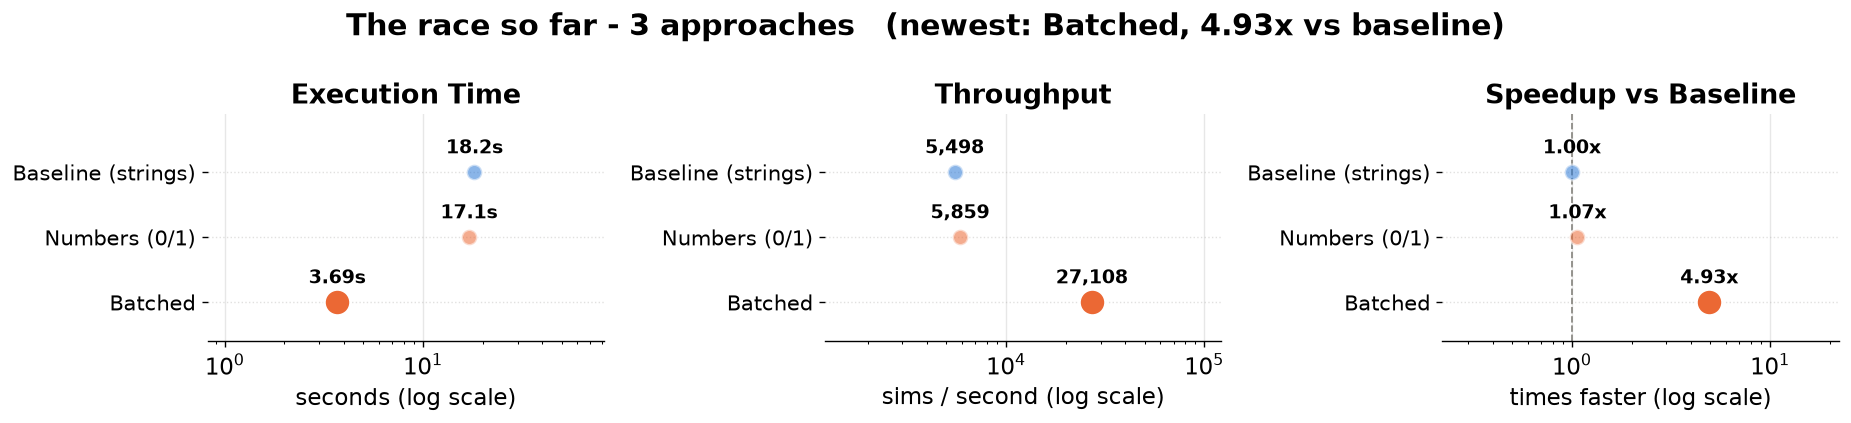

In [177]:
# Batching joins the race - redraw the scoreboard
add_approach("Batched", elapsed_time_batched, PALETTE["orange"])
show_race()

#### Did Batching Help?

Yes, properly this time - check the scoreboard for your number. But hold it up against what we
actually changed: we cut the trips around the inner loop **one hundred fold**, and got back a
handful. Where did the rest go?

`random.choices([0, 1], k=100)` doesn't hand back 100 cheap numbers. It builds a **Python list**
of 100 objects, and building that list costs about what the 100 loop iterations cost. We removed
work with one hand and added some of it back with the other.

That is a genuinely useful thing to learn: **the size of a speedup is almost never the size of the
change you made,** and the gap between them only shows up if you measure both ends.

But batching also handed us the question that drives the rest of this section:

> ### How many Python loops are left?

| Approach | Loop over the 100,000 simulations | Loop over the 500 flips | Trips around a Python loop |
| --- | --- | --- | --- |
| 1. Baseline | Python `for` | Python `for` | **50,000,000** |
| 2. Numbers | Python `for` | Python `for` | **50,000,000** |
| 3. Batched | Python `for` | Python `for`, 5 batches of 100 | **500,000** |
| 4. Vectorized *(next)* | Python `for` | **gone** | **100,000** |

Watch that last column all the way down the section. It's the whole story.

#### The Dial: What Batch Size Should We Use?

We picked 100 out of thin air. Somebody always does. So let's do the thing you should do every
time you find a made-up number in your code: **sweep it and look.**

We'll run the same simulation with batch sizes from 1 to 500 - where 1 means "no batching at all"
and 500 means "the whole simulation in one call" - on a smaller number of simulations so the
experiment is quick.

Timing 1,500 simulations at each batch size (best of 5)...


  batch_size=   1  ->   0.390s


  batch_size=   5  ->   0.122s


  batch_size=  10  ->   0.092s


  batch_size=  25  ->   0.067s


  batch_size=  50  ->   0.059s


  batch_size= 100  ->   0.053s


  batch_size= 250  ->   0.049s


  batch_size= 500  ->   0.050s


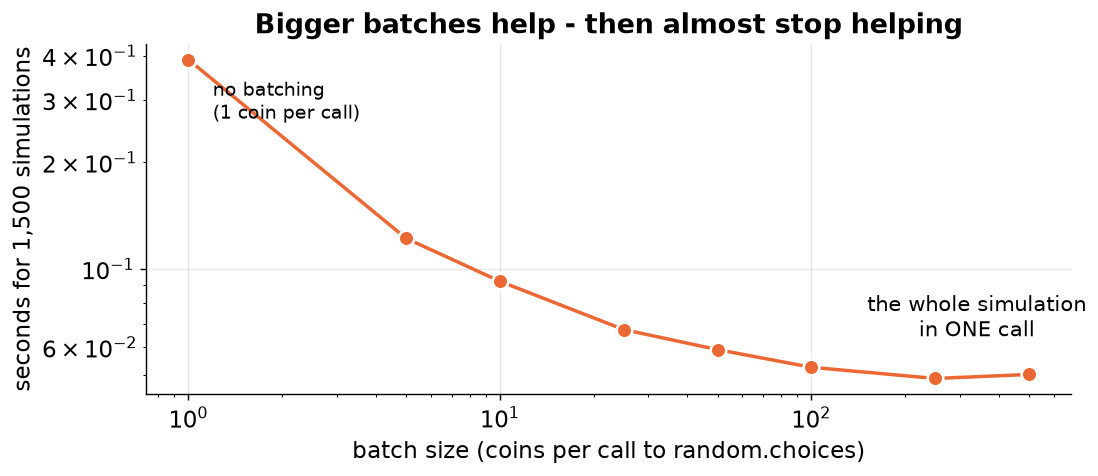


1 -> 25:      5.8x faster
25 -> 500:    1.3x faster  (20x the batch size, for that)


In [178]:
# CHART - read the picture, skip the code.
# Sweep the batch_size dial. Fewer simulations so this stays quick, and
# best_time() (see the scaffolding cell) so one hiccup can't bend the curve.
sweep_sims = 1_500
batch_sizes = [1, 5, 10, 25, 50, 100, 250, 500]
batch_times = []

count_heads_batched(500, batch_size=50)      # warm-up: never time the first call

print(f"Timing {sweep_sims:,} simulations at each batch size (best of 5)...")
for bs in batch_sizes:
    t = best_time(lambda: [count_heads_batched(500, batch_size=bs)
                           for _ in range(sweep_sims)])
    batch_times.append(t)
    print(f"  batch_size={bs:4}  ->  {t:6.3f}s")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(batch_sizes, batch_times, "-o", color=PALETTE["orange"], linewidth=2,
        markersize=9, markeredgecolor="white", markeredgewidth=1.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("batch size (coins per call to random.choices)")
ax.set_ylabel(f"seconds for {sweep_sims:,} simulations")
ax.set_title("Bigger batches help - then almost stop helping", fontweight="bold")
ax.grid(alpha=0.3)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.annotate("no batching\n(1 coin per call)", (batch_sizes[0], batch_times[0]),
            textcoords="offset points", xytext=(14, -34), fontsize=11)
ax.annotate("the whole simulation\nin ONE call", (batch_sizes[-1], batch_times[-1]),
            textcoords="offset points", xytext=(-30, 22), fontsize=12, ha="center")
plt.tight_layout(); plt.show()

print(f"\n1 -> 25:    {batch_times[0]/batch_times[3]:5.1f}x faster")
print(f"25 -> 500:  {batch_times[3]/batch_times[-1]:5.1f}x faster  (20x the batch size, for that)")

**Diminishing returns, and they arrive fast.** Going from 1 to 25 is a huge win. Going from 25
to 500 - a *twenty times* bigger batch - buys almost nothing.

That shape shows up constantly in performance work, and it has a simple cause. Batching trades
**loop overhead** for **list-building cost**. Early on you're eliminating a lot of the first and
paying a little of the second, so you win big. Past the knee, the overhead is already gone; all
that's left to pay is the list.

Two things to take away:

- **Tune a dial until the curve flattens, then stop.** Effort spent past the knee is wasted, and
  huge batches cost memory you could have spent elsewhere.
- **Look at the right-hand end.** The fastest batch size is *all 500 at once* - one call, one
  list, no loop. That's not a coincidence. "Batch size = everything" has a name, and it's the
  next approach.

### Approach 4 · Vectorize With NumPy

**The one thing that changes:** the batch becomes a NumPy array instead of a Python list.

The sweep just told us the best batch size is "all of them." Do that with a **NumPy array**
and the Python list - the thing that was eating our winnings - disappears entirely.

`random.choices(k=100)` still handed its work back as a Python list for us to add up. A **NumPy
array** is a different animal: one solid block of memory holding all 500 numbers. NumPy can
*create* all 500 and then *add* all 500 without Python ever seeing an individual value.

That's what **vectorization** means - you state the operation once for the entire array instead
of looping over its items:

```python
# BATCHED - Python still handles every batch
for _ in range(5):
    batch = random.choices([0, 1], k=100)   # ...a Python list of 100 ints, built 5 times
    heads += sum(batch)

# VECTORIZED - Python makes two function calls and then gets out of the way
flips = np.random.randint(0, 2, size=500)   # all 500 flips, generated in C
heads = np.sum(flips)                       # all 500 added, in C
```

Two Python calls for an entire 500-flip simulation, versus 500 trips around a loop. Why it wins:

- **No Python loop** - `np.random.randint()` produces all 500 values in one C-level operation.
- **Contiguous memory** - the values sit next to each other, which is what CPU caches are built for.
- **Optimized C underneath** - `np.sum()` is hand-tuned code, not interpreted Python.

Let's see what that does to the scoreboard.

In [179]:
# Vectorized version using NumPy
def count_heads_vectorized(n_flips):
    """Flip all coins at once using NumPy - MUCH faster!"""
    # Generate all flips at once as 0s and 1s
    # 0 = tails, 1 = heads
    flips = np.random.randint(0, 2, size=n_flips)
    
    # Count the 1s (heads)
    heads = np.sum(flips)
    
    return heads

# Test it
count_heads_vectorized(500)

np.int64(256)

In [180]:
# Approach 4: Vectorized
print("Running vectorized approach...")
start_time = time_module.time()

all_results_vectorized = []
for _ in range(n_simulations):
    result = count_heads_vectorized(500)
    all_results_vectorized.append(result)

end_time = time_module.time()
elapsed_time_vectorized = end_time - start_time

# Calculate results
average_vectorized = np.mean(all_results_vectorized)
difference_vectorized = abs(average_vectorized - expected)

print(f"✓ Completed {len(all_results_vectorized):,} simulations")
print(f"  Average: {average_vectorized:.6f} heads")
print(f"  Difference from expected: {difference_vectorized:.6f}")
print(f"  Time: {elapsed_time_vectorized:.2f} seconds")
print(f"  Rate: {len(all_results_vectorized)/elapsed_time_vectorized:.0f} sims/sec")

Running vectorized approach...


✓ Completed 100,000 simulations
  Average: 249.987210 heads
  Difference from expected: 0.012790
  Time: 1.12 seconds
  Rate: 89056 sims/sec


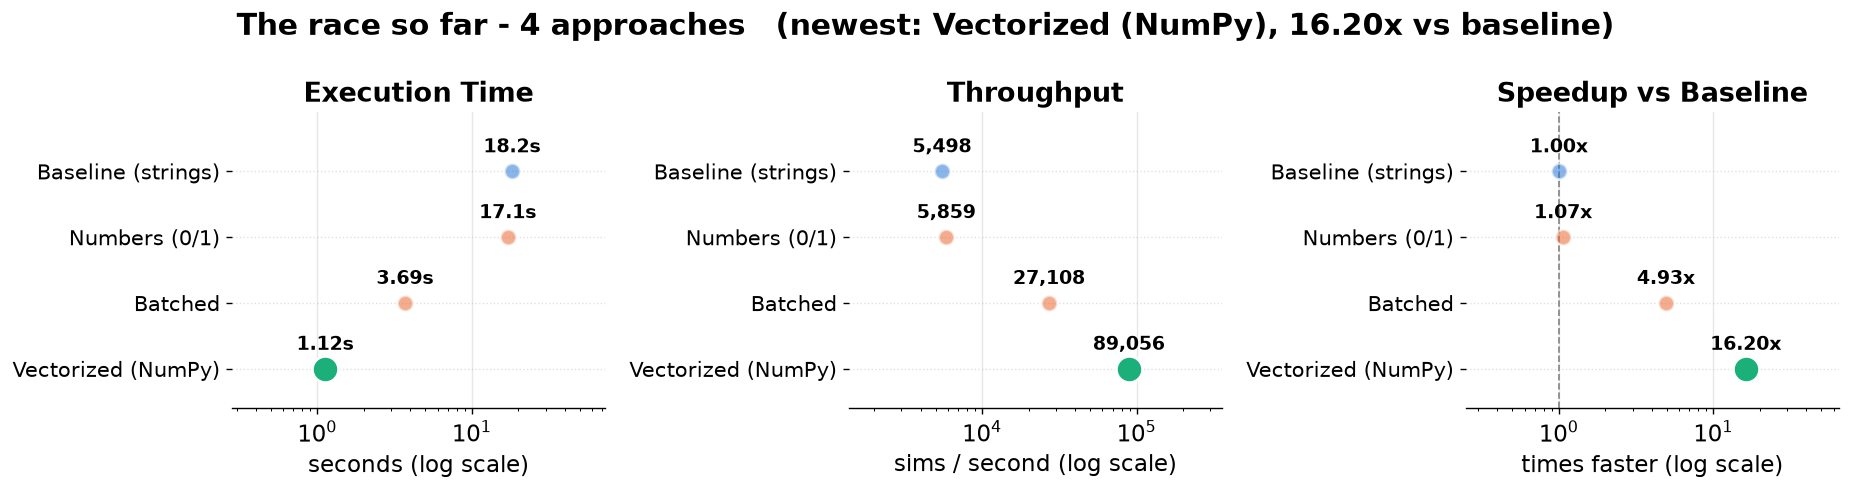

In [181]:
# Vectorization joins the race - redraw the scoreboard
add_approach("Vectorized\n(NumPy)", elapsed_time_vectorized, PALETTE["aqua"])
show_race()

**Why is NumPy So Much Faster?**

1. **No Python loops:** `np.random.randint()` generates all 500 random numbers in one C-level operation
2. **Contiguous memory:** All values are stored next to each other in memory (cache-friendly)
3. **Optimized operations:** `np.sum()` is implemented in highly optimized C code
4. **No list overhead:** No Python list creation, no repeated function calls

**The Vectorization Principle:**
> Instead of looping through items one-by-one, process the **entire array** in a single operation.

This is one of the most important optimization techniques in scientific computing!

Check the scoreboard for this machine's actual number - vectorization usually lands a
**10-20x** jump over the baseline. Pound for pound it is the biggest win in this notebook:
two lines of code, no new hardware, no new concepts beyond "operate on the whole array."

**But look again at the loop count - one Python loop survived.** We still call
`count_heads_vectorized()` 100,000 times from a Python `for` loop. That outer loop is the
next target, and we attack it twice: first by **splitting it across CPU cores**, and then by
**deleting it entirely** with JAX.

**Next step:** Even faster - we can run multiple simulations in parallel using multiple CPU cores!


**Recap — how a coin is represented at each step:**

| Approach | A coin is… | Counted with |
| --- | --- | --- |
| One-at-a-time | a Python **string** (`'heads'`/`'tails'`) | `== 'heads'`, `+= 1` |
| Batched | an **int** (`0`/`1`) in a Python list | `sum()` |
| Vectorized | a value in a **NumPy array** | `np.sum` |
| Parallel | NumPy arrays, split across **CPU cores** | `np.sum` |
| GPU / JAX | a value in a **device array** | `jnp.sum` + `vmap` |

Each row hands the computer a representation it handles better than the last — that, as much as the looping strategy, is what buys the speedup.

#### The Dial: How Big Does An Array Have To Be?

"Use NumPy, it's faster" is one of the most repeated pieces of advice in Python, and it is
**not always true**. There's a dial here too - the length of the array - and it has a threshold
below which NumPy *loses*.

Here's the mechanism. Every NumPy call has a fixed setup cost: check the arguments, work out the
data type, allocate a block of memory, hand control down to C and back. Call it a **toll**. You
pay the toll once per call, no matter how much data crosses. Pure Python pays no toll at all -
it just charges you per item, forever.

So NumPy wins only when there's enough data to **spread the toll across**. Let's find the exact
crossing point by measuring the cost of *one coin flip* both ways, at array sizes from 1 to 100,000.

In [182]:
# PLUMBING - read the output, skip the code.
# Cost per single coin flip: pure Python loop vs one NumPy call, across array sizes.
def flip_python(n):
    return sum(random.choice([0, 1]) for _ in range(n))

def flip_numpy(n):
    return int(np.sum(np.random.randint(0, 2, size=n)))

flip_python(10); flip_numpy(10)      # warm-up: the very first NumPy call is not typical

sizes = [1, 10, 25, 50, 100, 500, 5_000, 100_000]
py_per, np_per = [], []

print(f"{'array size':>11} {'python µs/flip':>16} {'numpy µs/flip':>15} {'numpy is':>13}")
for n in sizes:
    reps = max(3, min(2_000, 100_000 // n))     # equal-ish total work at every size
    py  = best_time(lambda: [flip_python(n) for _ in range(reps)], 3) / (reps * n) * 1e6
    npy = best_time(lambda: [flip_numpy(n)  for _ in range(reps)], 3) / (reps * n) * 1e6
    py_per.append(py); np_per.append(npy)
    verdict = f"{py/npy:6.2f}x " + ("faster" if py > npy else "SLOWER")
    print(f"{n:11,} {py:16.4f} {npy:15.4f} {verdict:>13}")

 array size   python µs/flip   numpy µs/flip      numpy is
          1           0.6308          7.4865   0.08x SLOWER
         10           0.3276          0.6926   0.47x SLOWER


         25           0.5113          0.3152   1.62x faster
         50           0.4165          0.1591   2.62x faster


        100           0.3160          0.0711   4.44x faster
        500           0.3169          0.0169  18.73x faster


      5,000           0.3024          0.0050  60.00x faster


    100,000           0.3460          0.0038  91.96x faster


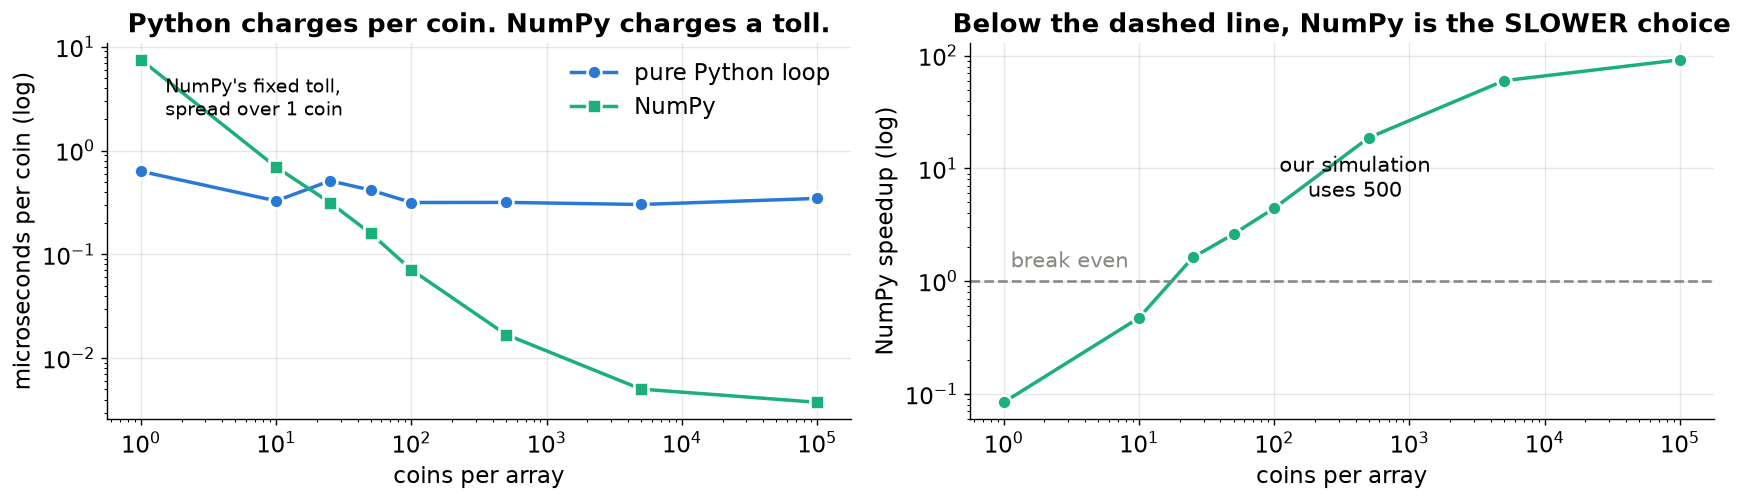

At 1 coin:       NumPy is 12x SLOWER than a plain Python loop
At 500 coins:    NumPy is 19x faster  <- where our simulation sits
At 100,000:      NumPy is 92x faster


In [183]:
# CHART - read the picture, skip the code.
# Two views of the same measurement
speedup = [p / q for p, q in zip(py_per, np_per)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.2))

ax1.plot(sizes, py_per, "-o", color=PALETTE["blue"], linewidth=2, markersize=8,
         markeredgecolor="white", markeredgewidth=1.5, label="pure Python loop")
ax1.plot(sizes, np_per, "-s", color=PALETTE["aqua"], linewidth=2, markersize=8,
         markeredgecolor="white", markeredgewidth=1.5, label="NumPy")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("coins per array"); ax1.set_ylabel("microseconds per coin (log)")
ax1.set_title("Python charges per coin. NumPy charges a toll.", fontweight="bold", fontsize=15)
ax1.legend(frameon=False); ax1.grid(alpha=0.3)
ax1.annotate("NumPy's fixed toll,\nspread over 1 coin", (sizes[0], np_per[0]),
             textcoords="offset points", xytext=(14, -32), fontsize=11)

ax2.plot(sizes, speedup, "-o", color=PALETTE["aqua"], linewidth=2, markersize=8,
         markeredgecolor="white", markeredgewidth=1.5)
ax2.axhline(1.0, color=PALETTE["muted"], linestyle="--", linewidth=1.5)
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("coins per array"); ax2.set_ylabel("NumPy speedup (log)")
ax2.set_title("Below the dashed line, NumPy is the SLOWER choice",
              fontweight="bold", fontsize=15)
ax2.grid(alpha=0.3)
ax2.annotate("break even", (sizes[0], 1.0), textcoords="offset points",
             xytext=(4, 8), fontsize=12, color=PALETTE["muted"])
ax2.annotate("our simulation\nuses 500", (500, speedup[sizes.index(500)]),
             textcoords="offset points", xytext=(-8, -34), fontsize=12, ha="center")
for ax in (ax1, ax2):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

print(f"At 1 coin:       NumPy is {1/speedup[0]:.0f}x SLOWER than a plain Python loop")
print(f"At 500 coins:    NumPy is {speedup[sizes.index(500)]:.0f}x faster  <- where our simulation sits")
print(f"At 100,000:      NumPy is {speedup[-1]:.0f}x faster")

**Vectorization is not magic. It's amortization.**

At one coin per call, NumPy is *dramatically slower* than the loop you were told to replace -
you're paying the whole toll to move a single item. Break-even shows up somewhere in the low
tens. Only well past that does NumPy start posting the numbers it's famous for.

Three things worth carrying out of this chart:

- **"Use NumPy" is advice with a precondition.** Calling NumPy inside a tight loop, on two or
  three values at a time, is a classic way to make a program *slower* while feeling like you
  optimized it. The fix is never "use NumPy more" - it's "call NumPy less, with more data."
- **Our 500 is a middling spot on this curve, and that's on purpose.** We get a solid speedup,
  but nowhere near the ceiling. If each experiment flipped 100,000 coins instead of 500, this
  exact same code would be several times better again - *the speedup you get is a consequence of
  a number you chose.*
- **It is the curve behind the `sum()` detour in Approach 3.** A batch of 100 sits far to the
  left here, where the toll still dominates - and `np.sum()` on a *list* is worse than this chart
  shows, because it has to build the array before it can start. That is the whole reason the
  builtin won. Batching still landed well short of 100x for the other reason: `random.choices()`
  hands back a Python list either way, and building it costs about what the loop cost.

### Approach 5 · Use Every Core

Every approach so far has used **one CPU core**. Your computer has more than one - probably 4, 8,
or 16 - and the other ones have been sitting idle this entire time.

**The one thing that changes:** instead of one Python doing all the simulations, we start several
Pythons and give each a share.

This is a genuinely different *kind* of change from Approaches 2-4. Those made the work smaller.
This one doesn't touch the work at all - it just does the same amount of it in more places at once.
Splitting a job that would take one person 8 hours across 8 people is the whole idea, and it works
here for a specific reason: **our simulations don't talk to each other.** Experiment #4,001 doesn't
need to know how #4,000 turned out. Work like that has a name - **embarrassingly parallel** - and
it is the easy case. (Anything where step 2 needs step 1's answer is the hard case, and no number
of cores helps.)

The catch is that "start several Pythons" is more work than it sounds, and it's the one place in
this notebook where Windows, macOS, and Linux genuinely disagree.

In [184]:
# PLUMBING - read the output, skip the code.
# Before we split the work: how many cores do you actually have?
# This is a surprisingly slippery question, so we ask it three different ways.
import multiprocessing as mp

topo = cpu_topology()
print(f"Logical CPUs (what Python reports): {topo['logical']}")
print(f"Physical cores (real, separate):    {topo['physical'] or 'could not detect'}")
print(f"Usable by this process:             {topo['usable']}")

n_cores = topo["usable"]
print(f"\nWe'll start {n_cores} worker processes - one per usable CPU.")

Logical CPUs (what Python reports): 32
Physical cores (real, separate):    16
Usable by this process:             32

We'll start 32 worker processes - one per usable CPU.


#### Wait - How Many Cores Is That?

Three numbers, and on a lot of machines they disagree. Worth understanding, because the whole
rest of this section is built on "how many things can genuinely happen at once."

| Number | What it counts |
| --- | --- |
| **Physical cores** | Actual, separate execution units carved into the silicon. This is the honest answer to "how many things can happen at the same time." |
| **Logical CPUs** | What the operating system advertises. Usually **larger** than physical, because of **hyperthreading** (Intel's name; AMD calls it SMT): one physical core pretends to be two, so that when one thread stalls waiting on memory, the other can use the idle moment. Two threads sharing one core is *not* two cores - expect maybe 20-30% extra throughput, not 100%. |
| **Usable** | How many this *process* is allowed to touch. A container, a shared server, or a Colab runtime can hand you far fewer than the box physically has. |

And on recent Intel chips there's a fourth wrinkle: **not all cores are the same kind.** A modern
Core i9 has a handful of big fast **P-cores** (performance) that hyperthread, plus a pile of small
efficient **E-cores** that don't. So a chip might be 8 P-cores + 16 E-cores = 24 physical cores
reporting **32 logical CPUs** - and eight of those "CPUs" are imaginary while sixteen of the real
ones are slower than the other eight. Apple Silicon does the same thing, with performance and
efficiency cores.

Which is why "I have 32 cores, so it'll be 32x faster" is wrong three times over. We're about to
find out what the real number is - by measuring it.

In [185]:
# Parallel version - run simulations across multiple cores
from multiprocessing import get_context, get_all_start_methods
from pathlib import Path

# Each worker is a SEPARATE Python process. Two of our three operating systems
# start those workers by re-importing the code by name, which means a function
# typed into a notebook cell is invisible to them ("Can't get attribute ...").
# The fix is to give the workers a real file they can import. We write it here so
# the notebook stays self-contained - no setup step, no separate download.
#
# We hand the workers all THREE representations - strings, ints, and NumPy - so
# that later we can ask what parallelism does to each of them.
WORKER_SRC = """
import random
import numpy as np

def run_batch_baseline(n_sims):
    "Approach 1 in a worker: one coin at a time, as the word 'heads' or 'tails'."
    out = []
    for _ in range(n_sims):
        heads = 0
        for _ in range(500):
            if random.choice(["heads", "tails"]) == "heads":
                heads += 1
        out.append(heads)
    return out

def run_batch_ints(n_sims):
    "Approach 2 in a worker: one coin at a time, as 0 or 1."
    out = []
    for _ in range(n_sims):
        heads = 0
        for _ in range(500):
            heads += random.choice([0, 1])
        out.append(heads)
    return out

def count_heads_vectorized(n_flips):
    "Same NumPy version we wrote above - the workers need their own copy."
    return int(np.sum(np.random.randint(0, 2, size=n_flips)))

def run_batch_simulations(n_sims):
    "Approach 4 in a worker - this is what each CPU core will be handed."
    return [count_heads_vectorized(500) for _ in range(n_sims)]

def run_batch_timed(n_sims):
    "Same job as above, but the worker also times its OWN math and reports it back."
    import time
    t0 = time.perf_counter()
    out = run_batch_simulations(n_sims)
    return out, time.perf_counter() - t0

def nothing(_):
    "Does no work at all. Timing THIS measures the cost of hiring a worker."
    return None
"""
Path("coin_worker.py").write_text(WORKER_SRC)
from coin_worker import (run_batch_simulations, run_batch_baseline,
                         run_batch_ints, run_batch_timed, nothing)

# Split work across cores
sims_per_core = n_simulations // n_cores

print("Wrote coin_worker.py so worker processes can import the job")
print(f"Splitting {n_simulations:,} simulations across {n_cores} cores")
print(f"Each core will run {sims_per_core:,} simulations")

Wrote coin_worker.py so worker processes can import the job
Splitting 100,000 simulations across 32 cores
Each core will run 3,125 simulations


#### One Job, Three Operating Systems

Starting a second process is the one place in this whole notebook where Windows,
macOS, and Linux genuinely disagree - so it's a good chance to see *why* real code
sometimes needs a branch per platform.

There are two ways to create a worker process:

| Method | How it works | Available on |
| --- | --- | --- |
| **fork** | Instantly clones the current process, memory and all. The clone already *has* our functions, so nothing needs importing. | Linux, macOS |
| **spawn** | Starts a brand-new Python, which **re-imports** the code by name. Slower, and it can only find things that live in a real file. | Linux, macOS, **Windows** |

Each OS gets the best method it can safely use:

- **Linux → `fork`.** Fastest, and safe here.
- **macOS → `spawn`.** macOS *has* `fork`, but Apple's system libraries start
  background threads, and cloning a threaded process can leave the copy holding a
  lock nobody will ever release - a frozen cell. Python's default on macOS is
  `spawn` for exactly this reason.
- **Windows → `spawn`.** Windows has no `fork` at all; `spawn` is the only option.

`spawn` pays a startup cost - a fresh Python *plus* a fresh `import numpy`, **per worker** - so the
parallel dot sits further right on macOS and Windows than on Linux. On a machine with a lot of
cores that bill gets big: 32 workers means 32 Pythons to start before any coin gets flipped. We're
going to measure that cost in a moment rather than hand-wave it, because on a fast machine it can
be larger than the entire job.

> **The rule `spawn` enforces:** anything a worker runs must be importable from a
> file. That is the entire reason we just wrote `coin_worker.py`.

In [186]:
# Approach 5: Parallel - the workers each run the VECTORIZED version (our best so far)
import warnings

# Pick the start method this OS can use (see the table above).
if platform.system() == "Linux" and "fork" in get_all_start_methods():
    start_method = "fork"      # Linux: fastest, and safe here
else:
    start_method = "spawn"     # macOS: avoids the threaded-fork freeze
                               # Windows: the only method that exists
print(f"Running parallel approach on {platform.system()} using '{start_method}'...")

start_time = time_module.time()

with warnings.catch_warnings():
    # On Linux, Python warns that forking a process with background threads (JAX
    # started some when we imported it) can deadlock. Safe here: the workers only
    # use numpy - they never call JAX - so they never wait on a JAX lock.
    warnings.filterwarnings("ignore", message=r".*os\.fork\(\).*", category=RuntimeWarning)
    with get_context(start_method).Pool(processes=n_cores) as pool:
        # Each core runs sims_per_core simulations
        results_per_core = pool.map(run_batch_simulations, [sims_per_core] * n_cores)

# Two `for`s in one comprehension = flatten: walk each core's list, then each result in it
all_results_parallel = [result for core_results in results_per_core for result in core_results]

end_time = time_module.time()
elapsed_time_parallel = end_time - start_time

# Calculate results
average_parallel = np.mean(all_results_parallel)
difference_parallel = abs(average_parallel - expected)

print(f"✓ Completed {len(all_results_parallel):,} simulations")
print(f"  Average: {average_parallel:.6f} heads")
print(f"  Difference from expected: {difference_parallel:.6f}")
print(f"  Time: {elapsed_time_parallel:.2f} seconds")
print(f"  Rate: {len(all_results_parallel)/elapsed_time_parallel:.0f} sims/sec")
if start_method == "spawn":
    print(f"  (includes {n_cores} fresh Python startups - 'fork' would be quicker)")

Running parallel approach on Linux using 'fork'...


✓ Completed 100,000 simulations
  Average: 250.164480 heads
  Difference from expected: 0.164480
  Time: 0.91 seconds
  Rate: 109426 sims/sec


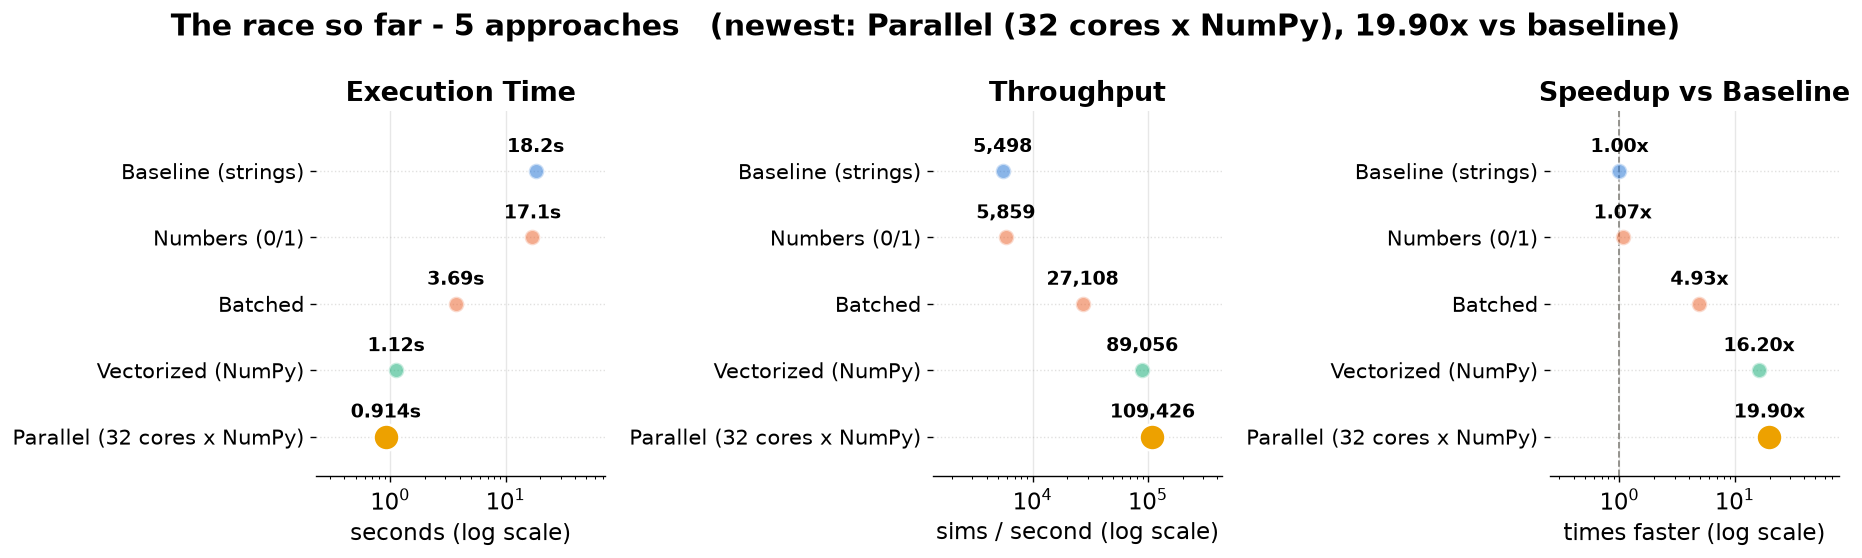

In [187]:
# Parallel joins the race - redraw the scoreboard
# Note WHAT is being parallelized: each core is running Approach 4, not Approach 1.
# We give the cores our best code, not our first code. (More on why, just below.)
# sims=... because n_cores rarely divides 100,000 evenly - we report what really ran.
add_approach(f"Parallel\n({n_cores} cores x NumPy)", elapsed_time_parallel,
             PALETTE["yellow"], sims=len(all_results_parallel))
show_race()

In [188]:
# PLUMBING - read the output, skip the code.
# Before judging the result: how much of that time was actual WORK?
# Two measurements instead of one guess:
#   1. Time a pool whose workers do NOTHING. Whatever that costs is pure hiring -
#      starting Pythons, importing numpy in each one, shipping messages around.
#   2. Run the real job again, but have every worker time its OWN math and hand
#      the number back. Anything left over after hiring and math is coordination.

def hire_workers():
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=r".*os\.fork\(\).*", category=RuntimeWarning)
        with get_context(start_method).Pool(processes=n_cores) as pool:
            pool.map(nothing, [None] * n_cores)

hiring_cost = best_time(hire_workers, 3)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=r".*os\.fork\(\).*", category=RuntimeWarning)
    with get_context(start_method).Pool(processes=n_cores) as pool:
        timed = pool.map(run_batch_timed, [sims_per_core] * n_cores)

worker_math   = [seconds for _, seconds in timed]
math_parallel = max(worker_math)          # the critical path - nobody finishes before the slowest
core_seconds  = sum(worker_math)          # CPU time burned in total, adding every worker up
moving_par    = max(elapsed_time_parallel - hiring_cost - math_parallel, 0.0)

print(f"Whole parallel run:            {elapsed_time_parallel:.3f}s")
print(f"  just hiring {n_cores:>3} workers:    {hiring_cost:.3f}s"
      f"   ({hiring_cost/elapsed_time_parallel*100:.0f}% of it)")
print(f"  the slowest worker's math:   {math_parallel:.3f}s"
      f"   ({math_parallel/elapsed_time_parallel*100:.0f}% of it)")
print(f"  handing work out and back:   {moving_par:.3f}s")
print(f"  start method:                {start_method}")
print()
print(f"Add up what every worker did and you get {core_seconds:.2f} CORE-seconds of math -")
print(f"but only {math_parallel:.3f} seconds passed on the clock, because {n_cores} of them ran at once.")
print("Core-seconds are what you pay for. Wall-clock seconds are what you wait for.")

record_parts(f"Parallel\n({n_cores} cores x NumPy)", math_parallel, moving=moving_par,
             setup=hiring_cost, setup_label=f"start {n_cores} workers",
             color=PALETTE["yellow"])

print("\n" + "=" * 62)
speedup_par = elapsed_time_vectorized / elapsed_time_parallel
if speedup_par >= 1.05:
    print(f"VERDICT: parallel WON. {speedup_par:.2f}x faster than one core running NumPy.")
    print(f"         There was enough work to keep {n_cores} workers busy.")
else:
    print(f"VERDICT: parallel LOST. It came out {1/speedup_par:.2f}x SLOWER than")
    print(f"         one single core running NumPy - and now you can see exactly why.")
    print(f"         Hiring the workers cost {hiring_cost:.3f}s. The entire job only")
    print(f"         took {elapsed_time_vectorized:.3f}s to begin with. We spent more time")
    print(f"         assembling the team than the team saved.")
print("=" * 62)


Whole parallel run:            0.914s
  just hiring  32 workers:    0.571s   (62% of it)
  the slowest worker's math:   0.096s   (10% of it)
  handing work out and back:   0.247s
  start method:                fork

Add up what every worker did and you get 2.40 CORE-seconds of math -
but only 0.096 seconds passed on the clock, because 32 of them ran at once.
Core-seconds are what you pay for. Wall-clock seconds are what you wait for.

VERDICT: parallel WON. 1.23x faster than one core running NumPy.
         There was enough work to keep 32 workers busy.


#### Did More Cores Help?

**Maybe.** Read the verdict your own machine just printed, because this is the first approach in
the notebook whose answer genuinely depends on the computer you run it on - and that is the lesson,
not a bug in the notebook.

The pattern itself is three lines:

```python
with Pool(processes=n_cores) as pool:
    results = pool.map(run_batch_simulations, [sims_per_core] * n_cores)
```

`pool.map` hands each worker one chunk, waits for all of them, and gives back the answers in order.

**Why you never get the full N times faster:**

| Cost | What it is |
| --- | --- |
| **Hiring** | Each worker is a whole new Python. Under `spawn` that's a fresh interpreter *and* a fresh `import numpy` per worker - which is the number we just measured. |
| **Shipping the results** | 100,000 numbers get packed up in the workers and unpacked back here. |
| **The slowest worker** | You wait for the last one to finish, not the average one. |
| **Sharing** | Hyperthreads share a physical core, and E-cores are slower than P-cores. Worker #30 is not as good as worker #1. |

Every one of those is a **fixed** cost - it doesn't shrink when the job does. So the question
"will parallel help?" is really the question **"is there enough work left to hide the overhead
behind?"**

That's a genuinely awkward spot for us, because we already made the work *tiny*. Approaches 2-4
cut a 25-second job down to about a second. Splitting one second across 32 spawned workers can
easily cost more than it saves - a fast machine with lots of cores is the **worst** case here, not
the best one, because it has more workers to hire and less work to hide them behind.

Two experiments follow. The first asks how many workers we should have asked for. The second asks
what parallelism does to code that *hasn't* been optimized yet - and that one has a punchline.

#### The Dial: How Many Workers Should We Ask For?

We asked for one worker per usable CPU without thinking about it, which is what almost everybody
does. But we just listed three reasons that number is optimistic: hyperthreads aren't real cores,
E-cores aren't as good as P-cores, and every extra worker costs something to hire.

So it's a dial - the third one in this section - and dials get **swept**, not guessed.

We'll use the *strings* version for this. It's our slowest code, which makes it the fairest test of
pure scaling: there's plenty of work to divide, so anything that goes wrong is the parallelism's
fault and not the workload's.

In [189]:
# PLUMBING - read the output, skip the code.
# Sweep the worker-count dial. Size the job from the baseline we already timed, so
# this takes a couple of seconds on a fast machine AND on a slow one.
target_seconds = 2.0
sweep4_sims = int(n_simulations * target_seconds / elapsed_time)
sweep4_sims = min(60_000, max(2_000, sweep4_sims))

# Powers of two up to the core count, plus the core count itself, plus the number of
# PHYSICAL cores - because we expect something interesting to happen right about there.
counts, w = [], 1
while w < n_cores:
    counts.append(w); w *= 2
counts.append(n_cores)
if topo["physical"] and 1 < topo["physical"] < n_cores:
    counts.append(topo["physical"])
counts = sorted(set(counts))

def run_with(n_workers, per):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=r".*os\.fork\(\).*", category=RuntimeWarning)
        with get_context(start_method).Pool(processes=n_workers) as pool:
            pool.map(run_batch_baseline, [per] * n_workers)

worker_times = []
print(f"~{sweep4_sims:,} simulations of the STRINGS version, split different ways (best of 2)")
print(f"{'workers':>8} {'time':>9} {'speedup':>9} {'per worker':>12}")
for w in counts:
    per = max(1, sweep4_sims // w)
    t = best_time(lambda: run_with(w, per), 2)
    worker_times.append(t)
    eff = (worker_times[0] / t) / w        # 1.00 would be perfect scaling
    print(f"{w:8} {t:8.3f}s {worker_times[0]/t:8.2f}x {eff:11.0%}")

~10,996 simulations of the STRINGS version, split different ways (best of 2)
 workers      time   speedup   per worker


       1    2.019s     1.00x        100%


       2    0.958s     2.11x        105%


       4    0.572s     3.53x         88%


       8    0.463s     4.36x         54%


      16    0.479s     4.22x         26%


      32    0.656s     3.08x         10%


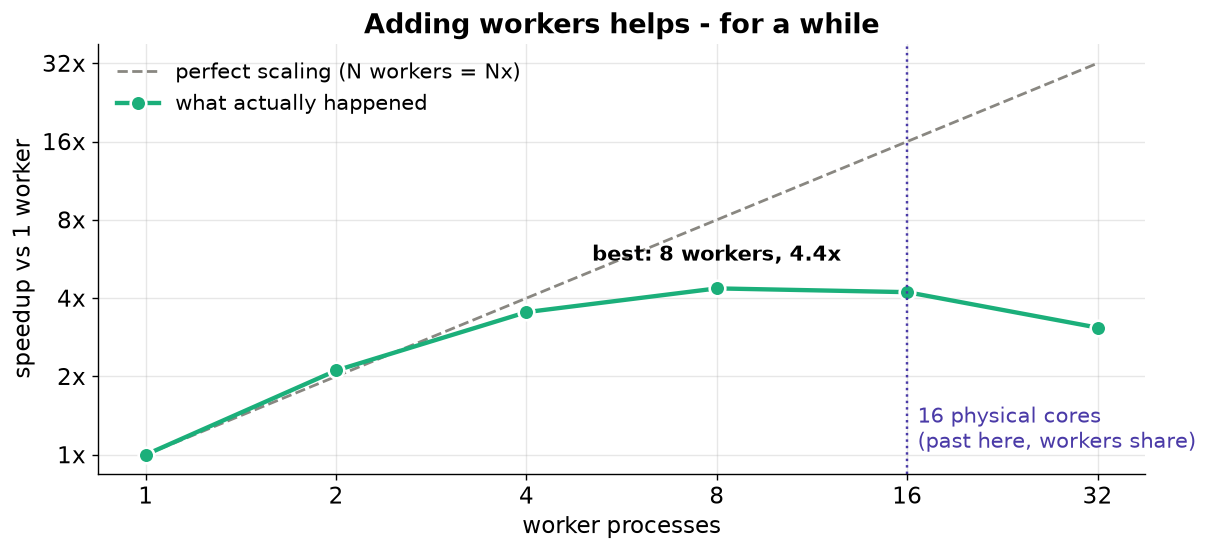

Asking for all 32 workers got 3.1x.
The best result was 4.4x, at 8 workers.
-> Asking for more than 8 made it WORSE, not better.


In [190]:
# CHART - read the picture, skip the code.
# Measured scaling vs the scaling you were promised
speedups = [worker_times[0] / t for t in worker_times]
fig, ax = plt.subplots(figsize=(10, 4.6))

ax.plot(counts, counts, "--", color=PALETTE["muted"], linewidth=1.6,
        label="perfect scaling (N workers = Nx)")
ax.plot(counts, speedups, "-o", color=PALETTE["aqua"], linewidth=2.5, markersize=9,
        markeredgecolor="white", markeredgewidth=1.5, label="what actually happened")

if topo["physical"] and 1 < topo["physical"] < n_cores:
    ax.axvline(topo["physical"], color=PALETTE["violet"], linewidth=1.4, linestyle=":")
    ax.annotate(f"{topo['physical']} physical cores\n(past here, workers share)",
                (topo["physical"], min(speedups)), textcoords="offset points",
                xytext=(6, 4), fontsize=12, color=PALETTE["violet"])

best_i = speedups.index(max(speedups))
ax.annotate(f"best: {counts[best_i]} workers, {speedups[best_i]:.1f}x",
            (counts[best_i], speedups[best_i]), textcoords="offset points",
            xytext=(0, 16), ha="center", fontsize=12, fontweight="bold")

ax.set_xscale("log", base=2); ax.set_yscale("log", base=2)
ax.set_xticks(counts); ax.set_xticklabels([str(c) for c in counts])
ax.set_yticks(counts); ax.set_yticklabels([f"{c}x" for c in counts])
ax.xaxis.set_minor_formatter(NullFormatter()); ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel("worker processes"); ax.set_ylabel("speedup vs 1 worker")
ax.set_title("Adding workers helps - for a while", fontweight="bold")
ax.legend(frameon=False, loc="upper left", fontsize=12)
ax.grid(alpha=0.3)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

print(f"Asking for all {n_cores} workers got {speedups[-1]:.1f}x.")
print(f"The best result was {speedups[best_i]:.1f}x, at {counts[best_i]} workers.")
if counts[best_i] < n_cores:
    print(f"-> Asking for more than {counts[best_i]} made it WORSE, not better.")

**The gap between the two lines is the whole story.** They start together - two workers really
is close to twice as fast - and then the measured line peels away and flattens. Sometimes it bends
back down.

Three separate things are bending that curve, and they kick in at different points:

1. **Hyperthreads aren't cores.** Past the physical-core mark (the dotted line, if we could detect
   it) each new "CPU" is sharing execution hardware with one that's already busy. You get some
   extra throughput, not double. The bend often shows up *earlier* than that line - a shared
   server, a container, or a laptop that's also running a browser gives you fewer cores in
   practice than the chip has on paper.
2. **Not all cores are equal.** On a chip with P-cores and E-cores, the first workers land on the
   fast cores and the later ones don't. And `pool.map` waits for the *slowest* worker, so a job
   stuck on an E-core sets the finishing time for everybody.
3. **Every worker costs something to hire**, and you pay that for all of them up front. Double the
   workers, double the hiring bill, while each one's share of the work gets smaller.

Put together, you get the shape on this chart, which shows up in essentially every parallel system
ever measured. It has a name - **Amdahl's law** - and the short version is: *the part of your
program that can't be split sets a hard ceiling on how much splitting the rest can help.*

**The practical rule:** "one worker per CPU" is a reasonable first guess and a bad final answer.
Sweep it once, find where your curve flattens, and use that.

#### The Experiment: Cores Are A Multiplier, Not A Fix

The last two charts were both about *how many* workers. This one is about **what you give them.**

There's a real temptation to treat parallelism as the thing you reach for when code is too slow -
"this is taking forever, let me throw more cores at it." So let's test that instinct head-on: run
all three representations - strings, ints, and NumPy - both **serially** and across **every
worker**, and put them on one axis.

In [191]:
# PLUMBING - read the output, skip the code.
# Same three functions, run two ways each.
# Size the job from the baseline time we already measured, so the slow version takes a
# few seconds on YOUR machine - a fixed number here would be far too small on a fast box
# and far too slow on a laptop. Rounded to whole chunks so every worker gets the same share.
sweep3_sims = int(n_simulations * 3.0 / elapsed_time)
sweep3_sims = min(60_000, max(n_cores * 50, sweep3_sims))
per_core    = max(1, sweep3_sims // n_cores)
sweep3_sims = per_core * n_cores

jobs = [
    ("Strings (Approach 1)", run_batch_baseline,      PALETTE["blue"]),
    ("Ints (Approach 2)",    run_batch_ints,          PALETTE["orange"]),
    ("NumPy (Approach 4)",   run_batch_simulations,   PALETTE["aqua"]),
]
serial_t, parallel_t = [], []

def run_parallel(fn):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=r".*os\.fork\(\).*", category=RuntimeWarning)
        with get_context(start_method).Pool(processes=n_cores) as pool:
            pool.map(fn, [per_core] * n_cores)

print(f"{sweep3_sims:,} simulations, each way (best of 2), {per_core:,} per worker")
print(f"{'representation':>22} {'1 core':>10} {'%d cores' % n_cores:>10} {'result':>16}")
for name, fn, _c in jobs:
    s = best_time(lambda: fn(sweep3_sims), 2)
    q = best_time(lambda: run_parallel(fn), 2)
    serial_t.append(s); parallel_t.append(q)
    tag = f"{s/q:.2f}x faster" if q <= s else f"{q/s:.2f}x SLOWER"
    print(f"{name:>22} {s:9.3f}s {q:9.3f}s {tag:>16}")

16,480 simulations, each way (best of 2), 515 per worker
        representation     1 core   32 cores           result


  Strings (Approach 1)     2.783s     0.892s     3.12x faster


     Ints (Approach 2)     2.529s     0.748s     3.38x faster


    NumPy (Approach 4)     0.155s     0.542s     3.50x SLOWER


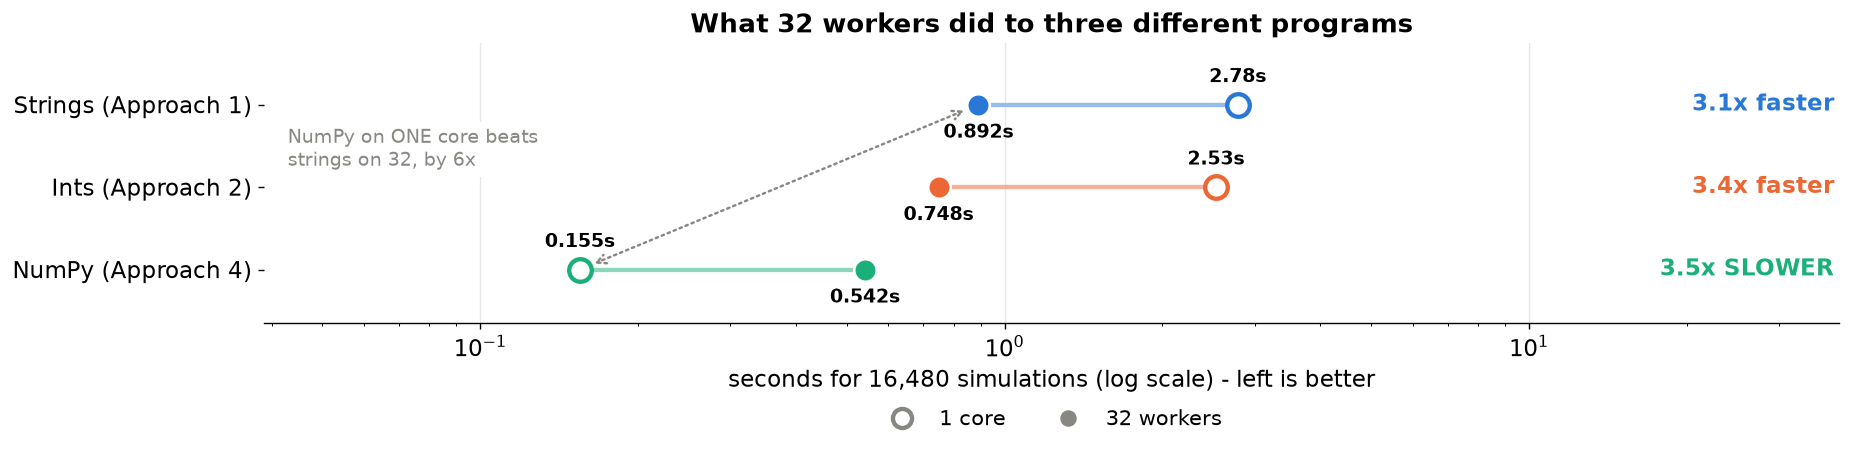

In [192]:
# CHART - read the picture, skip the code.
# One row per representation: open dot = 1 core, filled dot = every worker.
fig, ax = plt.subplots(figsize=(15, 4.0))
for y, ((name, _fn, c), s, q) in enumerate(zip(jobs, serial_t, parallel_t)):
    ax.plot([q, s], [y, y], "-", color=c, linewidth=2.5, alpha=0.5, zorder=1)
    ax.plot(s, y, "o", markersize=13, markerfacecolor="white", markeredgecolor=c,
            markeredgewidth=2.5, zorder=3)
    ax.plot(q, y, "o", markersize=13, color=c, markeredgecolor="white",
            markeredgewidth=1.5, zorder=3)
    # One label above, one below - they collide otherwise when the dots sit close.
    ax.annotate(f"{s:.3g}s", (s, y), textcoords="offset points", xytext=(0, 13),
                ha="center", fontsize=11, fontweight="bold")
    ax.annotate(f"{q:.3g}s", (q, y), textcoords="offset points", xytext=(0, -19),
                ha="center", fontsize=11, fontweight="bold")
    # Verdict parked at the right edge, where nothing can ever overlap it.
    tag = f"{s/q:.1f}x faster" if q <= s else f"{q/s:.1f}x SLOWER"
    ax.annotate(tag, xy=(0.997, y), xycoords=("axes fraction", "data"),
                ha="right", va="center", fontsize=13, color=c, fontweight="bold")

ax.set_xscale("log")
ax.set_yticks(range(len(jobs)))
ax.set_yticklabels([j[0] for j in jobs], fontsize=13)
ax.set_ylim(len(jobs) - 0.35, -0.75)
ax.set_xlim(min(serial_t + parallel_t) / 4, max(serial_t + parallel_t) * 14)
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel(f"seconds for {sweep3_sims:,} simulations (log scale) - left is better")
ax.set_title(f"What {n_cores} workers did to three different programs",
             fontweight="bold", fontsize=15)
ax.grid(axis="x", alpha=0.3)
ax.plot([], [], "o", markersize=11, markerfacecolor="white",
        markeredgecolor=PALETTE["muted"], markeredgewidth=2.5, label="1 core")
ax.plot([], [], "o", markersize=11, color=PALETTE["muted"],
        markeredgecolor="white", markeredgewidth=1.5, label=f"{n_cores} workers")
ax.legend(frameon=False, fontsize=12, ncol=2,
          loc="upper center", bbox_to_anchor=(0.5, -0.24))
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)

# The whole lesson in one arrow - but only draw it if it's actually true here.
if serial_t[2] < parallel_t[0]:
    ax.annotate("", xy=(serial_t[2], 2), xytext=(parallel_t[0], 0),
                arrowprops=dict(arrowstyle="<->", color=PALETTE["muted"], lw=1.4,
                                linestyle=":", shrinkA=9, shrinkB=9))
    ax.annotate(f"NumPy on ONE core beats\nstrings on {n_cores}, by {parallel_t[0]/serial_t[2]:.0f}x",
                xy=(0.015, 0.62), xycoords="axes fraction", fontsize=11,
                ha="left", va="center", color=PALETTE["muted"],
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none"))
plt.tight_layout(); plt.show()

Read the three lines top to bottom. Whatever the exact numbers on your machine,
**the slow code got more out of the cores than the fast code did** - and the fast code may well
have gone backwards.

That's the opposite of what you'd hope for, and it isn't a mistake:

- The slow versions have **so much work** that the fixed costs - hiring workers, shipping results
  back - vanish next to it. Lots to divide, little overhead, so the cores actually get used.
- The fast version has **so little work left** that those same fixed costs *are* the total. Split a
  job that takes a twentieth of a second across dozens of workers and you will reliably spend more
  time hiring the team than the team saves.

So parallelism **flatters bad code**. Its speedup number looks most impressive exactly where the
underlying program is worst, and most disappointing exactly where the program is best. Which is a
trap, because that number is capped and the other one isn't.

Now follow the dotted arrow - or if there isn't one on your chart, just compare the leftmost dot to
the blue filled dot.

> ### Optimize first, parallelize second.
>
> **Buying more cores multiplies whatever code you give them.  Multiplying slow code by 8 is worse
> than fixing it once.**
>
> Look at where those dots actually landed. The string version running on **every core you own** is
> still slower than the NumPy version running on **one**. And you can't buy your way out of it:
> cores multiply, and a multiplier is **capped at the number of cores you have** - and the last two
> charts showed you don't even get that. Approach 4 was a 10-20x head start over Approach 1. Your
> core count can't close that gap even in theory, and in practice it does far worse than its
> theory.
>
> This is the single most useful thing on this page. When something is too slow, the order is:
>
> 1. **Do less work.** (Approaches 2-4: a better representation, fewer Python loops.)
> 2. **Then** spread the work that's left across cores. (Approach 5.)
>
> Doing it in the other order means paying for hardware to run code you should have fixed - and it
> feels like progress the entire time, because the speedup number is *bigger* when you do it wrong.

### Approach 6 · JAX On The CPU

**The Ultimate Speedup: Graphics Processing Units**

CPUs are great generalists - they handle all kinds of tasks. But GPUs are **specialists** built for one thing: performing the same operation on thousands of data points simultaneously.

**Why GPUs are perfect for simulations:**
- **Massive parallelism:** A GPU has thousands of tiny cores (vs 4-16 on a CPU)
- **Built for arrays:** GPUs excel at mathematical operations on large arrays
- **SIMD architecture:** Single Instruction, Multiple Data - exactly what we need!

**The catch:** GPUs use special libraries like CuPy (CUDA) or JAX. We'll use **JAX** because:
- Works on both CPU and GPU (same code!)
- Just-in-time compilation for extreme speed
- Familiar NumPy-like syntax

**Note:** We run JAX on the **CPU** first, as a fair baseline. Then, in the optional section right after, the *exact same code* runs on the **GPU** if this machine has one (the setup cell above already detected that). Let's see JAX on the CPU first.

#### From NumPy to JAX - Three Small Changes and One Big One

JAX is deliberately NumPy-shaped, so most of the next cell will look familiar. Three things
change in small ways; one changes in a big way.

**The small ones - same idea, different spelling:**

| NumPy | JAX | What's different |
| --- | --- | --- |
| `np.random.randint(0, 2, size=n)` | `jax_random.bernoulli(key, p=0.5, shape=(n,))` | JAX makes you hand it a **key** |
| `np.sum(flips)` | `jnp.sum(flips)` | same function, `jnp` instead of `np` |
| the answer is already in RAM | the answer lives **on a device** | copy it back with `np.asarray(...)` |

**Why the `key`?** NumPy keeps a hidden, global "where am I in the random sequence" counter -
that's why `np.random.randint()` needs no setup. JAX refuses to have one, because a single shared
counter is exactly what falls apart when thousands of GPU cores all want a random number at the
same instant: whose turn is it? So in JAX, randomness is **a value you pass in**. `PRNGKey(42)`
creates one, and `split(key, n)` turns it into `n` independent keys - one per simulation. It's
more typing, and you get something real for it: the same key gives the same answer, on any
machine, on any number of cores.

**Now the big one - `vmap` deletes our last Python loop.**

Every approach so far, including the parallel one, still ran a Python `for` loop over the 100,000
simulations. NumPy vectorized *inside* one simulation. **`jax.vmap` vectorizes across all of them:**

```python
# What we have been doing - Python calls the function 100,000 times
results = [count_heads_vectorized(500) for _ in range(100_000)]

# vmap - describe ONE simulation, then ask for 100,000 of them in a single call
batch_fn = jax.vmap(count_heads_jax_single, in_axes=(None, 0))
results  = batch_fn(500, keys)      # `keys` holds 100,000 keys - and there is no Python loop
```

`in_axes=(None, 0)` is the instruction sheet: *"`n_flips` is the same for every simulation
(`None` - don't spread it), and `keys` should be spread along axis 0 - one key per simulation."*

Finally, `jax.jit` wraps the whole thing so it is **compiled to machine code once** and reused
after that. Compiling is a genuine cost; we time it separately below so you can see it, and the
"is this a fair race?" section right after explains why keeping it separate matters.

**The ladder, finished:**

| Approach | Loop over 100,000 sims | Loop over 500 flips | Python loop trips |
| --- | --- | --- | --- |
| Baseline | Python `for` | Python `for` | 25,000,000 |
| Batched | Python `for` | Python `for`, 5 batches | 500,000 |
| Vectorized (NumPy) | Python `for` | **gone** | 100,000 |
| Parallel | Python `for`, split across cores | **gone** | 100,000, shared out |
| **JAX + `vmap` + `jit`** | **gone** | **gone** | **0** |

That last row is the whole point of this section. Everything else was making the loop cheaper.
JAX gets rid of it.

In [193]:
if JAX_AVAILABLE:
    # GPU/JAX-optimized version using JAX arrays
    def count_heads_jax_single(n_flips, key):
        """Flip coins for a single simulation using JAX."""
        flips = jax_random.bernoulli(key, p=0.5, shape=(n_flips,))
        heads = jnp.sum(flips)
        return heads
    
    
    # Better approach: Vectorize across ALL simulations at once
    def count_heads_jax_batch(n_flips, n_sims, key):
        """Run ALL simulations at once in JAX - much more efficient!"""
        # Split the key into n_sims different keys
        keys = jax_random.split(key, n_sims)
        
        # Use vmap to vectorize the function across all simulations
        # This runs all simulations in parallel within JAX
        batch_fn = jax.vmap(count_heads_jax_single, in_axes=(None, 0))
        results = batch_fn(n_flips, keys)
        
        return results
    
    # JIT compile the batch function
    count_heads_jax_batch_jit = jax.jit(count_heads_jax_batch, static_argnums=(0, 1))
    
    # Test it
    test_key = jax_random.PRNGKey(0)
    test_results = count_heads_jax_batch_jit(500, 10, test_key)
    print(f"Test run: Got {len(test_results)} results")
    print(f"  First 5 results: {test_results[:5]}")
    print(f"  Average: {jnp.mean(test_results):.1f} heads")
else:
    print("Skipping JAX implementation - JAX not available")

Test run: Got 10 results
  First 5 results: [253 265 264 257 260]
  Average: 252.3 heads


#### Wait - Is This a Fair Race?

Our first attempt looked slow, but the stopwatch was catching things that aren't really JAX's compute:

1. **Compilation is one-time.** The *first* call to a JIT-compiled function compiles it to machine code - a cost you pay once, then reuse. We "warm it up" before the stopwatch, and also time that compile separately so you can see it.
2. **Getting results back costs too.** Pulling 100,000 values off the device *one at a time* (`[int(x) for x in results]`) is painfully slow. We grab them in one shot with `np.asarray(...)`, and call `.block_until_ready()` so we actually wait for the async work to finish.

**And about "does it use all the CPUs?"** For this run we pin JAX to the **CPU** on purpose, so it's a clean baseline. JAX exposes the CPU as a single *device*, so it does **not** fan work across processes the way our `multiprocessing` version does. But one device is not one core: XLA (JAX's compiler) multithreads a single computation under the hood and uses several cores - a different mechanism, still parallel. And on a machine with a **GPU**, the *exact same code* runs across its many cores with no changes - that's the optional GPU section coming up.

In [194]:
if JAX_AVAILABLE:
    # Approach 6: JAX on the CPU (optimized with vmap) - measured FAIRLY this time.
    # We pin the work to the CPU device so this is a clean CPU number; the GPU gets
    # its own section below.
    print(f"Running JAX on the CPU ({cpu_summary()})...")
    master_key = jax_random.PRNGKey(42)

    with jax.default_device(cpu_device):
        # The FIRST call compiles the function to machine code - a one-time cost.
        # Time it once so students see it, then reuse the compiled function.
        t0 = time_module.time()
        warmup = count_heads_jax_batch_jit(500, n_simulations, master_key)
        warmup.block_until_ready()
        compile_time = time_module.time() - t0

        # Now time the STEADY-STATE speed (compiled function, bulk transfer back).
        # Three stopwatches, not one - JAX is asynchronous, so calling the function
        # and waiting for its answer are separate events we can measure apart.
        start_time = time_module.time()
        jax_results = count_heads_jax_batch_jit(500, n_simulations, master_key)
        t_launched = time_module.time()             # the call already returned; no math done yet
        jax_results.block_until_ready()             # NOW wait for the device to finish
        t_computed = time_module.time()
        all_results_jax = np.asarray(jax_results)   # bulk transfer - NOT one int at a time!
        elapsed_time_jax = time_module.time() - start_time

    launch_jax   = t_launched - start_time
    math_jax     = t_computed - t_launched
    transfer_jax = elapsed_time_jax - (t_computed - start_time)

    average_jax = np.mean(all_results_jax)
    difference_jax = abs(average_jax - expected)

    print(f"✓ Completed {len(all_results_jax):,} simulations")
    print(f"  Average: {average_jax:.6f} heads")
    print(f"  Difference from expected: {difference_jax:.6f}")
    print(f"  One-time compile: {compile_time:.2f}s (paid once, then reused)")
    print(f"  Steady-state time: {elapsed_time_jax:.4f} seconds, made of:")
    print(f"      launching the work:      {launch_jax*1000:7.2f} ms")
    print(f"      the math itself:         {math_jax*1000:7.2f} ms")
    print(f"      copying answers back:    {transfer_jax*1000:7.2f} ms")
    print(f"  Rate: {len(all_results_jax)/elapsed_time_jax:.0f} sims/sec")

    record_parts("JAX\n(CPU)", math_jax, moving=launch_jax + transfer_jax,
                 setup=compile_time, setup_label="JIT compile", color=PALETTE["magenta"])
else:
    print("Skipping JAX timing - JAX not available")

Running JAX on the CPU (x86_64, 32 logical CPUs)...


✓ Completed 100,000 simulations
  Average: 249.982720 heads
  Difference from expected: 0.017280
  One-time compile: 0.73s (paid once, then reused)
  Steady-state time: 0.4464 seconds, made of:
      launching the work:         0.28 ms
      the math itself:          446.09 ms
      copying answers back:       0.06 ms
  Rate: 223998 sims/sec


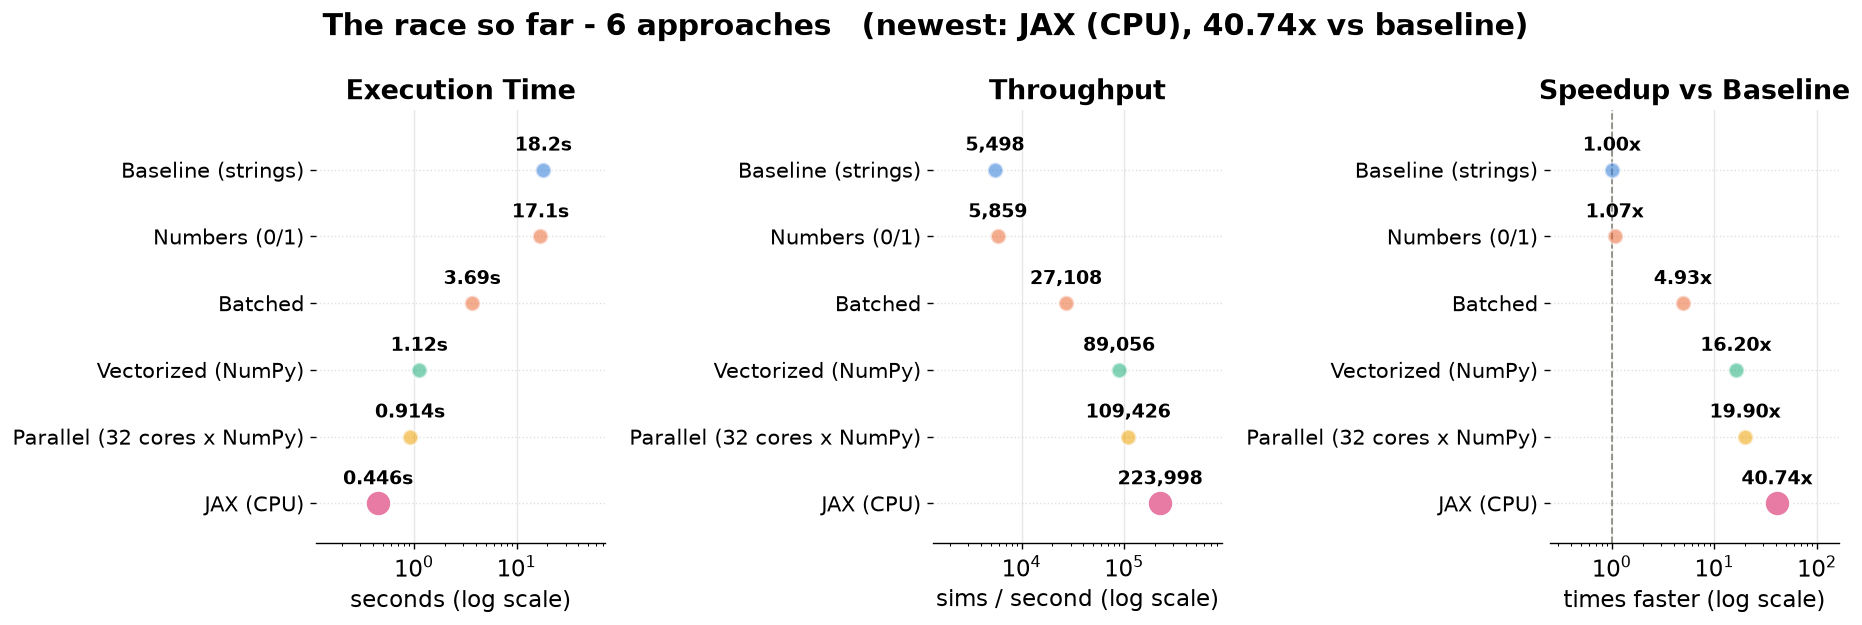

In [195]:
# JAX (CPU) joins the race - redraw the scoreboard (JAX time is post-compile)
if JAX_AVAILABLE:
    add_approach("JAX\n(CPU)", elapsed_time_jax, PALETTE["magenta"])
    show_race()
else:
    print("Skipping JAX - JAX not available")

**Understanding GPU/JAX Performance**

**What makes JAX special?**

1. **JIT compilation:** JAX compiles your Python function to optimized machine code the first time it runs (a one-time cost you then reuse).
2. **Vectorization with `vmap`:** it runs all 100,000 simulations *inside* JAX in one shot, instead of a Python loop calling it 100,000 times.
3. **Write once, run anywhere:** the *same* code runs on CPU **or** GPU with no changes - JAX just targets whatever device you hand it.

**Measured fairly, JAX is right at the front of the pack - even on CPU.** Once we compile once and transfer the results in bulk, its *compute* time is on par with multiprocessing here. Our first, naive attempt looked slow only because the stopwatch was catching the one-time compile and a slow value-by-value transfer off the device - not the math.

**The lesson matters as much as the number: benchmark the thing you actually care about.** Watch for hidden costs - compilation, and moving data on and off a device - and separate the one-time price from the steady-state speed.

**So which approach "wins"?** It depends on your hardware and problem:

| Approach | Best for |
| --- | --- |
| One-at-a-time | learning, debugging, tiny jobs |
| Batched | a stepping stone toward vectorized thinking |
| Vectorized (NumPy) | most scientific computing - great speed for little effort |
| Parallel (multiprocessing) | CPU-bound, independent work spread across cores |
| JAX (CPU) | big array math with no GPU; a stepping stone to the GPU |
| JAX (GPU) | big array math on a GPU, and gradient-based / ML work |

There's no single winner - **match the tool to the hardware and the problem.** And that's the perfect cue for the next part: we hand that *exact same JAX code* to a **GPU** - which runs automatically whenever this notebook is on a machine that has one. (Then, in the Super Bonus, a wildcard that beats them all with no libraries at all.)

### Approach 7 · The Same Code on the GPU (when one is available)

This section is **optional and self-detecting.** If the machine running the notebook has a GPU that
JAX can reach, the cell below runs our simulation on it and adds a **GPU** dot to the race. If not,
it prints what it found and why, then moves on - nothing breaks.

The remarkable part: **we don't change the simulation code at all.** It's the exact same
`count_heads_jax_batch_jit` from above - we just tell JAX to place the work on the GPU device
instead of the CPU. Different silicon underneath, identical Python on top.

**"JAX can reach"** is doing real work in that first sentence, and it is not the same as "you own a
GPU":

| You have | Can JAX use it? |
| --- | --- |
| NVIDIA GPU on **Linux** | **Yes** - `uv sync --extra gpu-nvidia` |
| Apple Silicon Mac | **Yes** - `uv sync --extra gpu-apple` (macOS 14+) |
| NVIDIA GPU on **Windows** | **No** - and this catches people out. JAX publishes its CUDA support for Linux only. A brand-new RTX card sitting in a Windows desktop is invisible to JAX no matter what you install. Use **WSL2** or **[Google Colab](https://colab.research.google.com/github/statmike/teaching-python/blob/main/python-overview.ipynb)** - both covered in [the readme](https://github.com/statmike/teaching-python). |
| Google Colab with a T4 runtime | **Yes**, and nothing to install |

We also print *what* hardware is doing the work - the CPU model and core count for the CPU runs,
the GPU model and memory for the GPU run - because "how fast" only means something once you know
"on what."

In [196]:
# Approach 7: JAX on the GPU - runs ONLY if this machine has one (auto-detected above)
if JAX_AVAILABLE and ACCELERATOR is not None:
    print(f"GPU detected -> {device_summary(ACCELERATOR)}")
    print(f"(CPU, for comparison: {cpu_summary()})\n")

    master_key = jax_random.PRNGKey(42)

    # Same code, same JIT'd function - we just place the work on the GPU device.
    with jax.default_device(ACCELERATOR):
        t0 = time_module.time()
        warmup = count_heads_jax_batch_jit(500, n_simulations, master_key)
        warmup.block_until_ready()
        compile_time_gpu = time_module.time() - t0

        start_time = time_module.time()
        gpu_out = count_heads_jax_batch_jit(500, n_simulations, master_key)
        t_launched = time_module.time()             # the call returned before the GPU started
        gpu_out.block_until_ready()                 # NOW wait for the GPU to finish
        t_computed = time_module.time()
        all_results_jax_gpu = np.asarray(gpu_out)   # bulk transfer back to the CPU
        elapsed_time_jax_gpu = time_module.time() - start_time

    launch_gpu   = t_launched - start_time
    math_gpu     = t_computed - t_launched
    transfer_gpu = elapsed_time_jax_gpu - (t_computed - start_time)

    average_gpu = np.mean(all_results_jax_gpu)

    print(f"✓ Completed {len(all_results_jax_gpu):,} simulations on the GPU")
    print(f"  Average: {average_gpu:.6f} heads  (expected {expected})")
    print(f"  One-time compile: {compile_time_gpu:.2f}s (paid once, then reused)")
    print(f"  Steady-state time: {elapsed_time_jax_gpu:.4f} seconds, made of:")
    print(f"      launching the work:      {launch_gpu*1000:7.2f} ms")
    print(f"      the math itself:         {math_gpu*1000:7.2f} ms")
    print(f"      copying answers back:    {transfer_gpu*1000:7.2f} ms  <- off the card, over PCIe")
    print(f"  Rate: {len(all_results_jax_gpu)/elapsed_time_jax_gpu:,.0f} sims/sec")
    print(f"  Speedup vs JAX-CPU: {elapsed_time_jax/elapsed_time_jax_gpu:.1f}x")

    record_parts(f"JAX GPU\n({ACCELERATOR.platform})", math_gpu, moving=launch_gpu + transfer_gpu,
                 setup=compile_time_gpu, setup_label="JIT compile", color=PALETTE["teal"])

    # The GPU joins the race - redraw the progressive scoreboard with the new result
    add_approach(f"JAX GPU\n({ACCELERATOR.platform})", elapsed_time_jax_gpu, PALETTE["teal"])
    show_race()
else:
    # "JAX has no GPU" and "this computer has no GPU" are different sentences.
    # Check with the driver directly so we can tell the student which one it is.
    card = nvidia_card()
    print("Skipping the GPU section - JAX has no GPU device here. (Nothing is broken.)\n")
    if card and platform.system() == "Windows":
        print(f"  You DO have a GPU: {card}")
        print("  JAX just cannot reach it, because JAX ships CUDA support for Linux only.")
        print("  There is no package that fixes this on native Windows. Two ways to run")
        print("  this section on that card:")
        print("    1. Google Colab  - one click, T4 already selected, nothing to install:")
        print("       https://colab.research.google.com/github/statmike/teaching-python/blob/main/python-overview.ipynb")
        print("    2. WSL2          - install Ubuntu inside Windows, then re-run there")
        print("  Both are written up step by step in the readme:")
        print("       https://github.com/statmike/teaching-python")
    elif card:
        print(f"  You DO have a GPU: {card}")
        print("  JAX's CUDA build just isn't installed. Run:  uv sync --extra gpu-nvidia")
    elif platform.system() == "Darwin" and platform.machine() == "arm64":
        print("  This Mac has a GPU, but the JAX Metal plugin isn't installed.")
        print("  Run:  uv sync --extra gpu-apple      (needs macOS 14 or newer)")
    else:
        print("  No GPU found on this machine at all - which is completely fine.")
        print("  Every lesson above this point already ran. To see this one:")
        print("    Google Colab - one click, T4 already selected, nothing to install:")
        print("    https://colab.research.google.com/github/statmike/teaching-python/blob/main/python-overview.ipynb")

Skipping the GPU section - JAX has no GPU device here. (Nothing is broken.)

  No GPU found on this machine at all - which is completely fine.
  Every lesson above this point already ran. To see this one:
    Google Colab - one click, T4 already selected, nothing to install:
    https://colab.research.google.com/github/statmike/teaching-python/blob/main/python-overview.ipynb


## Bonus: Understanding Binary Representation

*~10 min · 38 cells · optional, and safe to skip entirely*

How does a computer count with just 0s and 1s?

Let's discover how binary works!

This looks like a detour, and it pays off two sections from now: the fastest coin-flipper in the
whole notebook is built entirely out of what's on this page.


### Counting With Only Two Digits

We count in tens because we have ten fingers. A computer has two states - on and off - so it
counts in twos. Same idea, fewer digits, longer numbers.

In [197]:
# First, review how WE count - decimal (base 10)
# We use 10 digits: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9

# In decimal, each position is a power of 10
number = 347
# Position values:  100s   10s   1s
#                    3      4     7
# Calculation: 3×100 + 4×10 + 7×1
3*100 + 4*10 + 7*1

347

In [198]:
# Binary uses only 2 digits: 0 and 1 (base 2)
# Each position is a power of 2
# Position values:  16s   8s   4s   2s   1s
#                    1     0    1    0    1
# What number is 10101 in decimal? Let's calculate!

# Converting binary 10101 to decimal
1*16 + 0*8 + 1*4 + 0*2 + 1*1

21

In [199]:
# Python has a built-in function to convert to binary!
bin(21)  # Same number we just calculated!

'0b10101'

In [200]:
# The '0b' prefix means "binary"
bin(5), bin(10), bin(15)

('0b101', '0b1010', '0b1111')

In [201]:
# Let's see the pattern
bin(0), bin(1), bin(2), bin(3)

('0b0', '0b1', '0b10', '0b11')

In [202]:
bin(4), bin(5), bin(6), bin(7)

('0b100', '0b101', '0b110', '0b111')

In [203]:
bin(8), bin(9), bin(10), bin(11)

('0b1000', '0b1001', '0b1010', '0b1011')

In [204]:
bin(12), bin(13), bin(14), bin(15)

('0b1100', '0b1101', '0b1110', '0b1111')

### Making Random Bits

Remember `random.getrandbits()`. It hands you *n* coin flips packed into a single number, and it
is the whole basis of the fastest approach in this notebook.

In [205]:
# Now let's generate random binary numbers!
# Generate a random 1-bit number (0 or 1)
r = random.getrandbits(1)
r, bin(r), format(r, '01b')

(0, '0b0', '0')

In [206]:
# Random 2-bit number (0 to 3)
r = random.getrandbits(2)
r, bin(r), format(r, '02b')

(0, '0b0', '00')

In [207]:
# Random 3-bit number (0 to 7)
r = random.getrandbits(3)
r, bin(r), format(r, '03b')

(7, '0b111', '111')

In [208]:
# Random 4-bit number (0 to 15)
r = random.getrandbits(4)
r, bin(r), format(r, '04b')

(7, '0b111', '0111')

In [209]:
# Random 64-bit number - computers often use 64-bit numbers!
r = random.getrandbits(64)
r, bin(r), format(r, '064b')

(980733250164803574,
 '0b110110011100010000111011000111100011011111001100011111110110',
 '0000110110011100010000111011000111100011011111001100011111110110')

### Why Binary Matters

- Computer memory: measured in bits (binary digits) and bytes (8 bits)
- IP addresses: converted to binary for routing
- Colors in graphics: RGB values (0-255 each, which is 8 bits)
- File sizes: 8 bits = 1 byte, 1024 bytes = 1 KB

 
Everything in a computer is ultimately 0s and 1s!

### Try It Yourself

Work each one out in your head first, then run the cell.

In [210]:
# Challenge 1: What is binary 1111 in decimal?
# Try to calculate it yourself first!
# Answer:
1*8 + 1*4 + 1*2 + 1*1

15

In [211]:
# Challenge 2: What's the largest number with 8 bits?
# Hint: All 1s - 11111111
# Answer:
1*128 + 1*64 + 1*32 + 1*16 + 1*8 + 1*4 + 1*2 + 1*1

255

In [212]:
# Verify with Python
bin(255)  # This is 8 bits all set to 1!

'0b11111111'

In [213]:
# Fun fact: This is why RGB colors go from 0-255
# Each color channel (Red, Green, Blue) uses 8 bits!
red = 255    # All 1s - maximum red
green = 128  # 10000000 - half green  
blue = 0     # All 0s - no blue
# Result: bright orange-red color!

### Bitwise Operators - Working On Bits Directly

Everything so far has been about *reading* binary. Python also lets you **operate** on the bits
of a number directly, with seven tools. They look strange the first time, but each one does
something very simple, and the Super Bonus section right after this is built entirely out of them.

| Operator | Name | In one sentence |
| --- | --- | --- |
| `&` | AND | a `1` only where **both** numbers have a `1` |
| `\|` | OR | a `1` where **either** number has a `1` |
| `^` | XOR | a `1` where the two numbers **differ** |
| `~` | NOT | flips every bit |
| `<<` | left shift | slide the bits left - each slide **doubles** the number |
| `>>` | right shift | slide the bits right - each slide **halves** it |
| `.bit_count()` | popcount | how many `1`s are in there |

The trick to reading all of them: **they work column by column.** Line the two numbers up in
binary, and the operator decides each column on its own, with no carrying and no borrowing.

In [214]:
# A tiny helper so we can SEE the bits instead of just the number
def bits(n, width=8):
    return format(n, f'0{width}b')

a = 12    # 00001100
b = 10    # 00001010
print(f"a = {a:3}  ->  {bits(a)}")
print(f"b = {b:3}  ->  {bits(b)}")

a =  12  ->  00001100
b =  10  ->  00001010


#### `&` - AND

A `1` only in the columns where *both* inputs have a `1`. Its everyday use is
**testing**: `x & mask` is how you ask "is that particular bit switched on?"

In [215]:
print(f"  {bits(a)}   (a = {a})")
print(f"& {bits(b)}   (b = {b})")
print(f"  --------")
print(f"  {bits(a & b)}   (a & b = {a & b})   <- only column 3 had a 1 in BOTH")

# The testing pattern: is bit number 2 switched on?
print()
print("is bit 2 on in a?", (a & 0b00000100) != 0)
print("is bit 4 on in a?", (a & 0b00010000) != 0)

  00001100   (a = 12)
& 00001010   (b = 10)
  --------
  00001000   (a & b = 8)   <- only column 3 had a 1 in BOTH

is bit 2 on in a? True
is bit 4 on in a? False


#### `|` - OR

A `1` wherever *either* input has one. Its everyday use is **switching a bit on**
without disturbing any of the others.

In [216]:
print(f"  {bits(a)}   (a = {a})")
print(f"| {bits(b)}   (b = {b})")
print(f"  --------")
print(f"  {bits(a | b)}   (a | b = {a | b})   <- a 1 in every column that had one anywhere")

# Switching a bit ON, leaving the rest alone
print()
print("a          ", bits(a))
print("a | bit 0  ", bits(a | 0b00000001), " <- turned the last bit on")

  00001100   (a = 12)
| 00001010   (b = 10)
  --------
  00001110   (a | b = 14)   <- a 1 in every column that had one anywhere

a           00001100
a | bit 0   00001101  <- turned the last bit on


#### `^` - XOR ("exclusive or")

A `1` only where the two inputs **disagree**. Its everyday use is
**flipping** a bit: XOR with a `1` turns a bit into its opposite, and XOR with a `0` leaves it alone.
That makes it a literal coin flip.

In [217]:
print(f"  {bits(a)}   (a = {a})")
print(f"^ {bits(b)}   (b = {b})")
print(f"  --------")
print(f"  {bits(a ^ b)}   (a ^ b = {a ^ b})   <- 1 only where they DISAGREE")

# XOR is its own undo - do it twice and you are back where you started
print()
print("a            ", bits(a))
print("a ^ b        ", bits(a ^ b))
print("a ^ b ^ b    ", bits(a ^ b ^ b), " <- back to a")

  00001100   (a = 12)
^ 00001010   (b = 10)
  --------
  00000110   (a ^ b = 6)   <- 1 only where they DISAGREE

a             00001100
a ^ b         00000110
a ^ b ^ b     00001100  <- back to a


#### `~` - NOT

Flips every single bit. There's a surprise waiting here, and it's a good one:
`~12` is not `243`, it's `-13`. Python (like your CPU) stores negative numbers using a scheme
called *two's complement*, where flipping all the bits of `n` gives you `-n - 1`. If what you
actually want is "flip the bits inside an 8-bit box," mask the result back down.

In [218]:
print("~a in Python:", ~a, "   <- not what you might expect!")
print("the rule:     ~n == -n - 1  ->", -a - 1)

# Keep it inside an 8-bit box: flip, then mask off everything above bit 7
print()
print("a            ", bits(a))
print("~a & 0xFF    ", bits(~a & 0xFF), " <- every bit flipped, inside 8 bits")

~a in Python: -13    <- not what you might expect!
the rule:     ~n == -n - 1  -> -13

a             00001100
~a & 0xFF     11110011  <- every bit flipped, inside 8 bits


#### `<<` and `>>` - The Shifts

Slide every bit left or right. Sliding left by one doubles the
number (same as adding a `0` on the right of a decimal number multiplies it by ten); sliding right
by one halves it, throwing away whatever falls off the end.

The important use isn't arithmetic though - it's **building a mask**. `1 << k` is a number with a
single `1` sitting in position `k`, which is exactly the thing you hand to `&` and `|`.

In [219]:
one = 1
for k in range(5):
    print(f"1 << {k}  =  {bits(one << k)}  =  {one << k:3}")

print()
print(f"a       {bits(a)} = {a}")
print(f"a << 1  {bits(a << 1)} = {a << 1}   (doubled)")
print(f"a >> 1  {bits(a >> 1)} = {a >> 1}   (halved)")
print(f"a >> 3  {bits(a >> 3)} = {a >> 3}   (12 / 8 = 1.5, but bits have no halves - the rest falls off)")

1 << 0  =  00000001  =    1
1 << 1  =  00000010  =    2
1 << 2  =  00000100  =    4
1 << 3  =  00001000  =    8
1 << 4  =  00010000  =   16

a       00001100 = 12
a << 1  00011000 = 24   (doubled)
a >> 1  00000110 = 6   (halved)
a >> 3  00000001 = 1   (12 / 8 = 1.5, but bits have no halves - the rest falls off)


#### `.bit_count()` - Popcount

Not an operator but a method on every integer: it counts how many
`1`s are in the number. Modern CPUs have a **single instruction** for this (called POPCNT), so no
matter how big the number, counting its `1` bits is nearly free.

In [220]:
print(f"{bits(a)}  has {a.bit_count()} ones")
print(f"{bits(b)}  has {b.bit_count()} ones")
print(f"{bits(255)}  has {(255).bit_count()} ones")

# And it does not care how big the number is
big = random.getrandbits(1000)
print(f"\na random 1000-bit number has {big.bit_count()} ones out of 1000")
print("(...which should be somewhere near 500. Does that sound like anything?)")

00001100  has 2 ones
00001010  has 2 ones
11111111  has 8 ones

a random 1000-bit number has 516 ones out of 1000
(...which should be somewhere near 500. Does that sound like anything?)


### The Same Seven Tools, In Coin-World

Read that table one more time, but pretend every bit is a coin - `1` for heads, `0` for tails.
This is the entire Super Bonus section in advance:

| Operator | With bits | With **coins** |
| --- | --- | --- |
| `1 << k` | a `1` in position `k` | *"point at coin number k"* |
| `\|` | switch a bit on | *"set that coin to heads"* |
| `&` | test a bit | *"is that coin heads?"* |
| `^` | flip a bit | *"flip that coin over"* |
| `~` | flip every bit | *"flip the whole table over"* |
| `getrandbits(n)` | n random bits | *"toss n coins at once"* |
| `.bit_count()` | count the `1`s | *"how many came up heads?"* |

That last pair is the punchline. **One call tosses the coins, one call counts the heads** - and
neither one loops.

Two things to carry into the next section: **`random.getrandbits()`**, which flips a whole
pile of coins in one call, and **`.bit_count()`**, which counts the heads in one instruction.
Everything below is those two, plus the shift-and-mask pattern you just learned.

## Super Bonus: One Int, Many Coins

*~4 min · 5 cells · optional - but it is the fastest approach in the whole notebook*

The whole "Make Iterations Faster" story was really one question asked over and over: *what's the best way to **represent** a coin?* Strings, then ints, then a NumPy array, then an array handed to a compiler or a GPU - each
faster than the one before.

Here's the densest representation of all: **one bit per coin.** A single 1 or 0 inside an integer *is* a coin - heads or tails. Once coins are bits, the computer's built-in bit tricks do the counting almost for free.

First, the tools. Every operator below means something concrete in coin-world:


In [221]:
# Pack several coins into ONE number. Bit = 1 -> HEADS, bit = 0 -> tails.
# We read bits right-to-left: bit 0 is coin #0.
def show(coins, n=8):
    bits = format(coins, f'0{n}b')                      # e.g. '00001000'
    faces = ['H' if b == '1' else 't' for b in bits]    # 'X if test else Y' picks one of two
    return f"{bits}  ->  {' '.join(faces)}"

coins = 0
print("start (all tails): ", show(coins))

# <<  builds a "mask" pointing at ONE coin:  1 << 3  is ...00001000
coin3 = 1 << 3
print("mask for coin #3:  ", show(coin3))

# |   turns a coin to HEADS (set that bit)
coins = coins | coin3
print("set coin #3 heads: ", show(coins))

# &   TESTS a coin (is it heads?)
print("is coin #3 heads? ", (coins & coin3) != 0)
print("is coin #5 heads? ", (coins & (1 << 5)) != 0)

# ^   FLIPS a coin (toggle the bit) - a literal coin flip!
coins = coins ^ coin3
print("flip coin #3:      ", show(coins))

# >>  shifts every coin right (drops coin #0)
coins = (1 << 0) | (1 << 1) | (1 << 7)                  # three heads
print("three heads:       ", show(coins), " heads =", coins.bit_count())
print("shift right by 1:  ", show(coins >> 1))

start (all tails):  00000000  ->  t t t t t t t t
mask for coin #3:   00001000  ->  t t t t H t t t
set coin #3 heads:  00001000  ->  t t t t H t t t
is coin #3 heads?  True
is coin #5 heads?  False
flip coin #3:       00000000  ->  t t t t t t t t
three heads:        10000011  ->  H t t t t t H H  heads = 3
shift right by 1:   01000001  ->  t H t t t t t H


Now the payoff. `random.getrandbits(n)` flips **n coins in a single call**, and `.bit_count()` counts the heads (the 1-bits) in essentially **one CPU instruction** (the hardware POPCNT). No loop. No NumPy. No imports.

In [222]:
# Flip 500 coins at once, count heads at once
flips = random.getrandbits(500)     # 500 random bits = 500 coin flips
heads = flips.bit_count()           # count the 1s (heads)
print(f"Flipped 500 coins in one call.  Heads: {heads}")
print("Each 0/1 in that giant number is one coin - and Python ints can be ANY size,")
print("so a 500-bit (or 500,000-bit) number is no problem.")

Flipped 500 coins in one call.  Heads: 239
Each 0/1 in that giant number is one coin - and Python ints can be ANY size,
so a 500-bit (or 500,000-bit) number is no problem.


In [223]:
# Race it over the SAME workload as before: 100,000 experiments of 500 flips.
# (Reusing the baseline and NumPy times we already measured above.)
def run_bitboard():
    return [random.getrandbits(500).bit_count() for _ in range(n_simulations)]

bitboard_time = best_time(run_bitboard)
results_bitboard = run_bitboard()

print(f"Bitboard: {n_simulations:,} sims in {bitboard_time:.4f}s")
print(f"  Average heads: {np.mean(results_bitboard):.2f}  (expected {expected})")
print(f"  vs baseline (strings):  {elapsed_time / bitboard_time:,.0f}x faster")
print(f"  vs NumPy (vectorized):  {elapsed_time_vectorized / bitboard_time:,.0f}x faster")
print("\n...pure standard-library Python, no imports at all.")

Bitboard: 100,000 sims in 0.0213s


  Average heads: 249.98  (expected 250)
  vs baseline (strings):  856x faster
  vs NumPy (vectorized):  53x faster

...pure standard-library Python, no imports at all.


## The Whole Field - Every Approach at Once

*~2 min · 2 cells · the closing scoreboard*

Time for the final scoreboard. How does one-integer-per-experiment stack up against
*everything* - batching, NumPy, parallel, even JAX? Here's the whole race on one dashboard.

(Fairness note, one more time: the JAX dots are **steady-state** - *after* its one-time
compile. The bitboard needs no compile and no imports at all.)


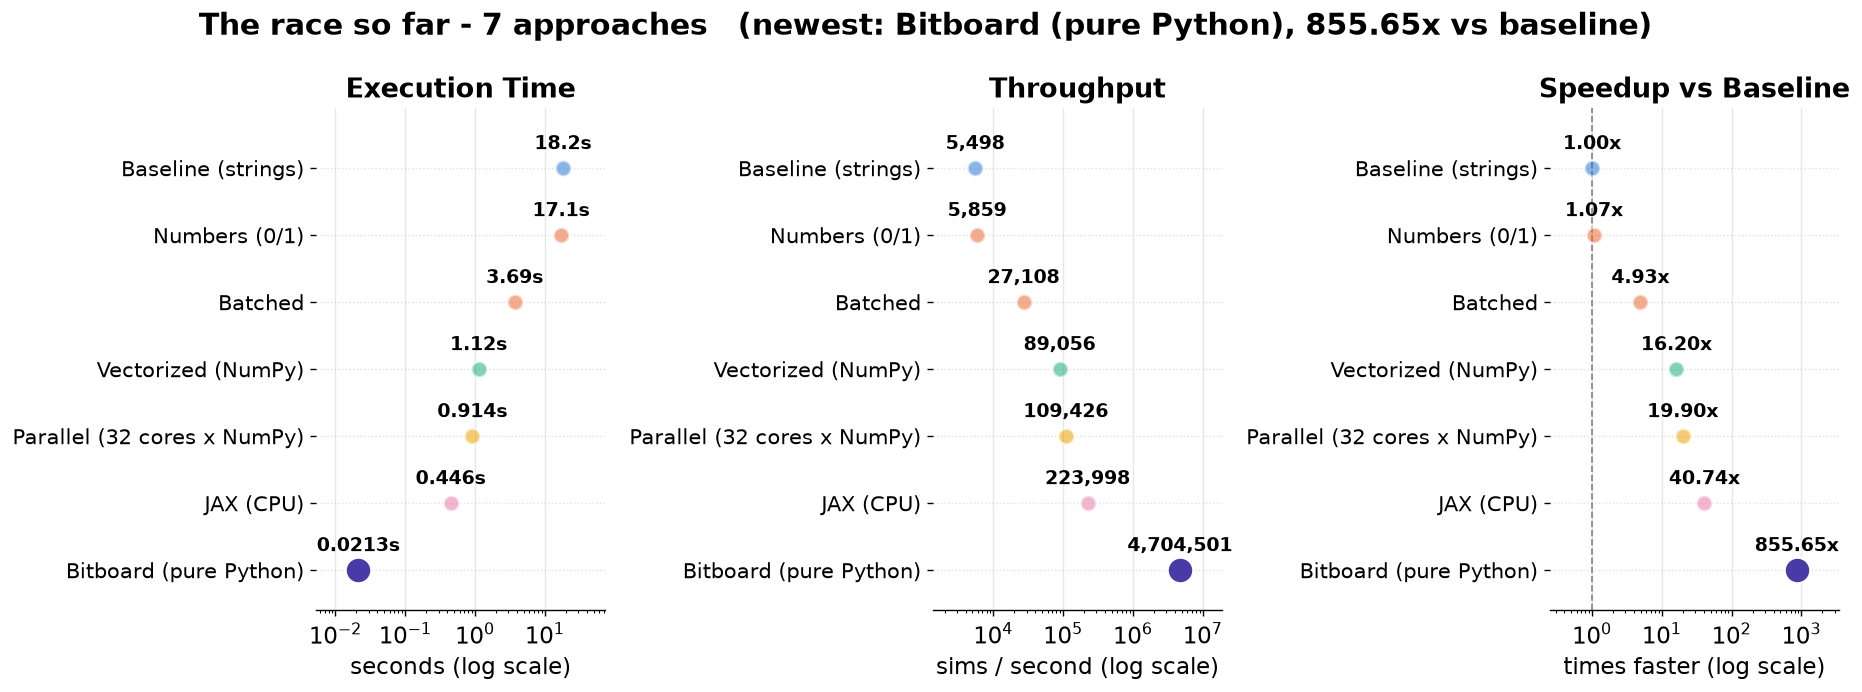

In [224]:
# The bitboard joins the race - the final scoreboard, all approaches at once
add_approach("Bitboard\n(pure Python)", bitboard_time, PALETTE["violet"])
show_race()

## Where The Time Really Goes

*~5 min · 5 cells · the closing idea*

Every dot on that scoreboard is one number, and one number hides the story.

**Start with an honest confession about those numbers.** Each one is the wall-clock time of a
run - *not* the time spent doing math. For most of the approaches there's no difference, because
arithmetic is all they do. For the last three there's an enormous difference, and it isn't even
charged the same way from row to row:

| Approach | What its scoreboard number actually contains |
| --- | --- |
| Baseline, Numbers, Batched, Vectorized, Bitboard | all of it, because arithmetic is all they do |
| Parallel | the math **plus** starting the workers **plus** shuttling work and answers around - our code hires a fresh crew every run, so it pays for the crew every run |
| JAX (CPU and GPU) | the math **plus** launching and copying answers back - but **not** the one-time compile, which we timed and printed separately |

So the scoreboard was never lying, but it was quietly answering two different questions: *"what
do I wait for starting cold?"* on the parallel row, and *"what do I wait for once it's warm?"*
on the JAX rows. That's a real inconsistency, and it's the single most common reason two
benchmarks of the same code disagree. The fix isn't a fairer single number. **The fix is to stop
using a single number.**

Every run we timed splits into three kinds of second:

| Part | What it is | When you pay it |
| --- | --- | --- |
| **Setup** | getting the machinery ready - starting workers, compiling, waking a device | **once**, then reused |
| **Moving data** | handing the work out, collecting the answers back | **every run** |
| **The math** | the numerical computation we actually wanted | **every run** |

Approaches 1, 2 and 3 aren't in the chart below, and that absence is the lesson: a plain Python
`for` loop has no machinery at all. It is 100% math - and still the slowest thing in this
notebook. Every bit of speed we won came from *adding* machinery, and machinery is never free.

Each approach keeps the colour it had on the scoreboard. The three parts are told apart by
**shape** on the left and by **shade** on the right, so every row still reads as one approach.


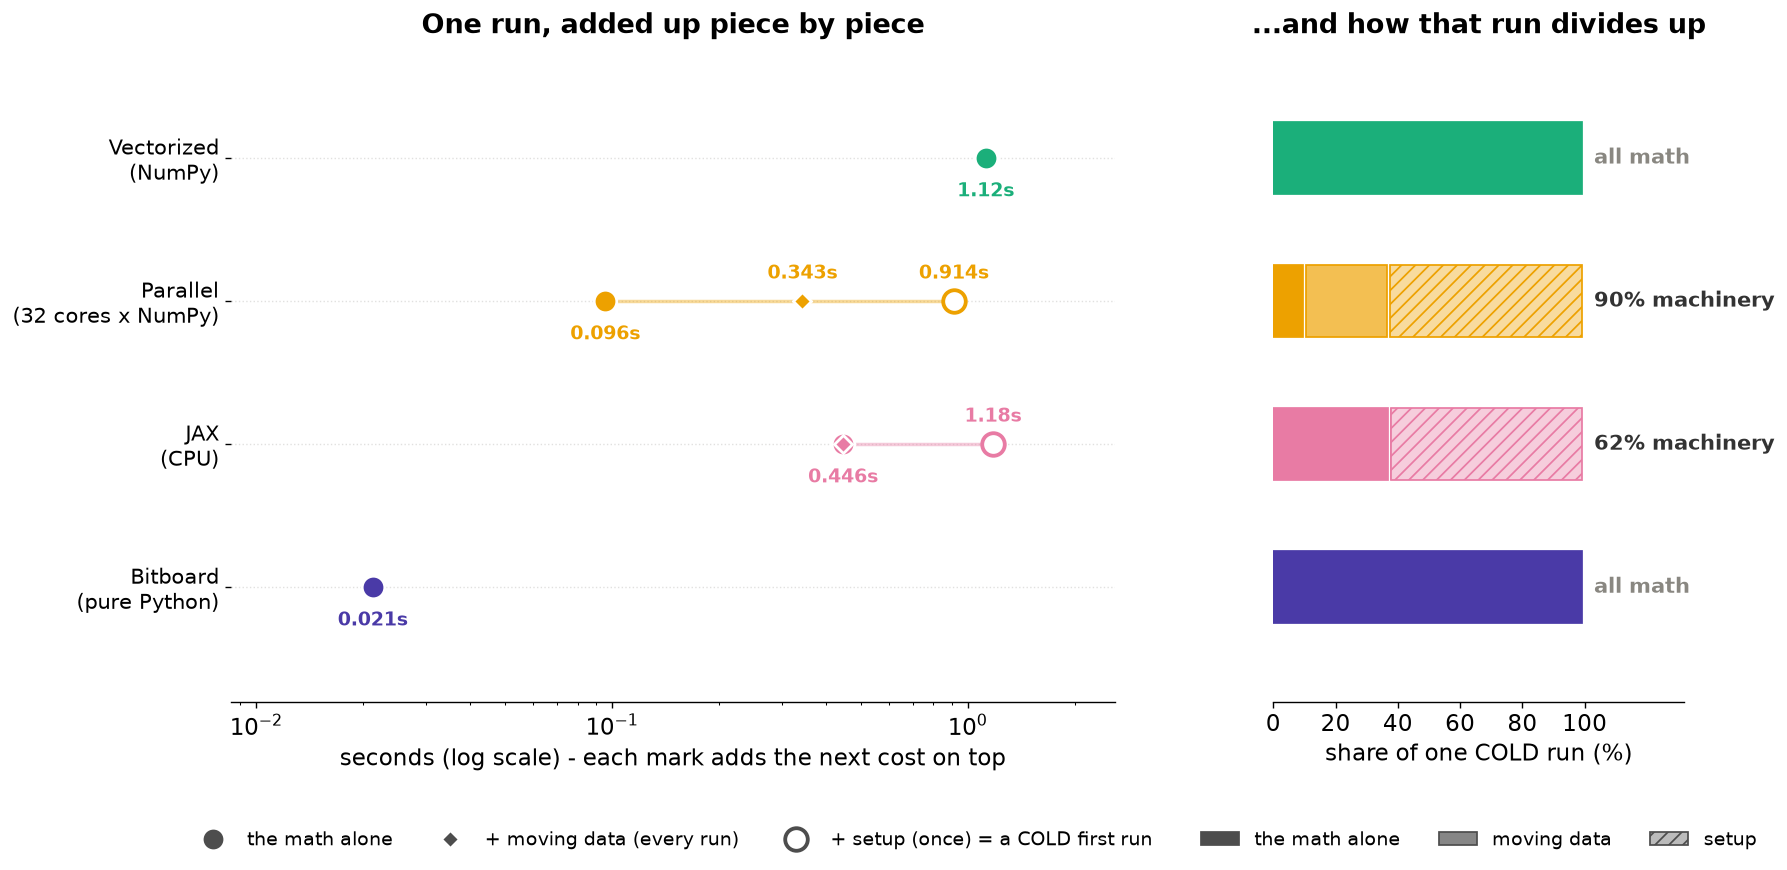

In [225]:
# CHART - read the picture, skip the code.
# Two approaches have no machinery whatsoever - their entire time IS the math.
record_parts("Vectorized\n(NumPy)", elapsed_time_vectorized)
record_parts("Bitboard\n(pure Python)", bitboard_time)

import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Walk the scoreboard in ITS order and pull ITS colours, so an approach looks the
# same here as it did there. Anything with no breakdown recorded is simply skipped.
rows = [(r["name"], {**TIME_PARTS[r["name"]], "color": r["color"]})
        for r in RESULTS if r["name"] in TIME_PARTS]

def tint(color, amount):
    """Mix a colour with white. amount=0 leaves it alone, 1 makes it white.
    Same hue, lighter - so a stacked bar can stay one approach's colour."""
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

# (key, marker, size, filled?, bar tint, bar hatch, label)  - read in this order.
STEPS = [("math",   "o", 13, True,  0.00, None,  "the math alone"),
         ("moving", "D",  7, True,  0.32, None,  "+ moving data (every run)"),
         ("setup",  "o", 13, False, 0.62, "///", "+ setup (once) = a COLD first run")]

fig, (ax_t, ax_p) = plt.subplots(1, 2, figsize=(14.5, 1.15 * len(rows) + 2.6),
                                 gridspec_kw={"width_ratios": [2.15, 1.0]})
ys = list(range(len(rows)))[::-1]          # first entry at the top

# ---- left: running total, in real seconds, on a log axis ---------------------
# Each mark adds the next cost ON TOP of the one before it. That keeps the marks
# in order, so the connecting line means "and then, and then" - and the last mark
# is a number you can actually act on: what one cold run costs.
reach = []
for y, (name, p) in zip(ys, rows):
    c = p["color"]
    ax_t.axhline(y, color=PALETTE["muted"], alpha=0.25, lw=0.8, ls=":", zorder=0)

    running, pts = 0.0, []
    for k, mk, ms, fill, *_ in STEPS:
        if p[k] <= 0 and k != "math":
            continue                       # nothing to add, so nothing to draw
        running += p[k]
        pts.append((running, mk, ms, fill))
    reach += [v for v, *_ in pts]

    if len(pts) > 1:
        ax_t.plot([pts[0][0], pts[-1][0]], [y, y], color=c, lw=2.0, alpha=0.4, zorder=1)

    labelled = 0.0
    for i, (v, mk, ms, fill) in enumerate(pts):
        ax_t.plot(v, y, mk, ms=ms, zorder=3,
                  mfc=c if fill else "white",
                  mec="white" if fill else c,      # a ring so overlapping marks separate
                  mew=1.6 if fill else 2.2)
        # Only label a mark that actually moved the total. Otherwise the number
        # sits on top of the previous one and says nothing new.
        if i == 0 or v > labelled * 1.08:
            ax_t.annotate(fmt_seconds(v), (v, y), textcoords="offset points",
                          xytext=(0, -22 if i == 0 else 13), ha="center",
                          fontsize=11, fontweight="bold", color=c)
            labelled = v

ax_t.set_xscale("log")
ax_t.set_xlim(min(reach) / 2.5, max(reach) * 2.2)
ax_t.set_yticks(ys); ax_t.set_yticklabels([n for n, _ in rows], fontsize=12)
ax_t.set_ylim(-0.8, len(rows) - 0.2)
ax_t.set_xlabel("seconds (log scale) - each mark adds the next cost on top")
ax_t.set_title("One run, added up piece by piece", fontweight="bold")
ax_t.xaxis.set_minor_formatter(NullFormatter())
for side in ("top", "right", "left"):
    ax_t.spines[side].set_visible(False)
ax_t.legend(handles=[Line2D([], [], marker=mk, ls="", ms=ms, label=lab,
                            mfc="#4d4d4d" if fill else "white",
                            mec="white" if fill else "#4d4d4d",
                            mew=1.6 if fill else 2.2)
                     for _, mk, ms, fill, _, _, lab in STEPS],
            loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=3,
            frameon=False, fontsize=11)

# ---- right: the same cold run as a share of 100% -----------------------------
GAP = 1.0                                   # a sliver of background between segments
for y, (name, p) in zip(ys, rows):
    c = p["color"]
    one_run = p["setup"] + p["moving"] + p["math"]
    left = 0.0
    for k, _, _, _, amt, hatch, _ in STEPS:
        share = p[k] / one_run * 100
        if share <= 0:
            continue
        ax_p.barh(y, max(share - GAP, share * 0.5), left=left, height=0.5,
                  color=tint(c, amt), edgecolor=c, linewidth=1.0,
                  hatch=hatch, zorder=2)
        left += share
    machinery = (p["setup"] + p["moving"]) / one_run * 100
    ax_p.annotate("all math" if machinery < 1 else f"{machinery:.0f}% machinery",
                  (103, y), va="center", fontsize=12, fontweight="bold",
                  color=PALETTE["muted"] if machinery < 1 else "#333333",
                  annotation_clip=False)

ax_p.set_xlim(0, 132); ax_p.set_xticks([0, 20, 40, 60, 80, 100]); ax_p.set_ylim(-0.8, len(rows) - 0.2)
ax_p.set_yticks([])
ax_p.set_xlabel("share of one COLD run (%)")
ax_p.set_title("...and how that run divides up", fontweight="bold")
for side in ("top", "right", "left"):
    ax_p.spines[side].set_visible(False)
ax_p.legend(handles=[Patch(facecolor=tint("#4d4d4d", amt), edgecolor="#4d4d4d",
                           hatch=hatch, label=lab.lstrip("+ ").split(" (")[0])
                     for _, _, _, _, amt, hatch, lab in STEPS],
            loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=3,
            frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


**Left panel: one run, added up.** Read a row left to right. The big filled circle is the math
on its own - the work you actually asked for. The diamond adds what it cost to move data around,
and the hollow circle adds the one-time setup on top of that. So the *last* mark on each row is
the honest cold-start price of that approach, and the gaps between marks are what each piece of
machinery charged you. A row with one lonely circle did nothing but arithmetic.

**And this is where the confession from a moment ago becomes a picture.** On the parallel row,
the scoreboard showed you the *hollow circle* - the whole cold run, hiring included. On the JAX
rows it showed you the *diamond* - everything except the hollow circle. Same chart, two different
marks. Now you can see the gap those two conventions were hiding.

Where a middle mark seems to be missing, it's there - its cost was just too small to separate
from the mark before it. JAX's launch-and-copy-back is measured in *tenths of a millisecond*,
so at this scale it hides behind the math dot rather than earning its own label.

Now look at where the hollow circles land. On many machines the one-time setup for JAX, or for
the worker pool, costs more all by itself than an entire run of one of the faster approaches.
That is not a reason to avoid them. It is a reason to *not judge them with a stopwatch that
starts cold*.

**Right panel: that same cold run, as shares of 100%.** Same colour per approach, going from
palest (machinery) to full strength (the math). The hatched block is the part you would not pay
a second time. A row labelled `% machinery` is telling you how little of your wait was
arithmetic - and on some of these rows the answer is genuinely shocking.

And then there's the bottom row. The fastest approach in the whole notebook is also the only one
with no setup, no transfer, and no library - it is all math, and there is barely any of it.

### But Setup Is Only Paid Once

Here's what that right-hand panel can't show you. Nobody runs a simulation once. You run it,
change a parameter, run it again, change another one, run it two hundred more times.

Setup doesn't get charged again on any of those runs. So the real question isn't "which approach
is fastest?" - it's **"which approach is fastest for the number of times I'm actually going to
run it?"** Those can be different answers, and the chart below is where they change places.


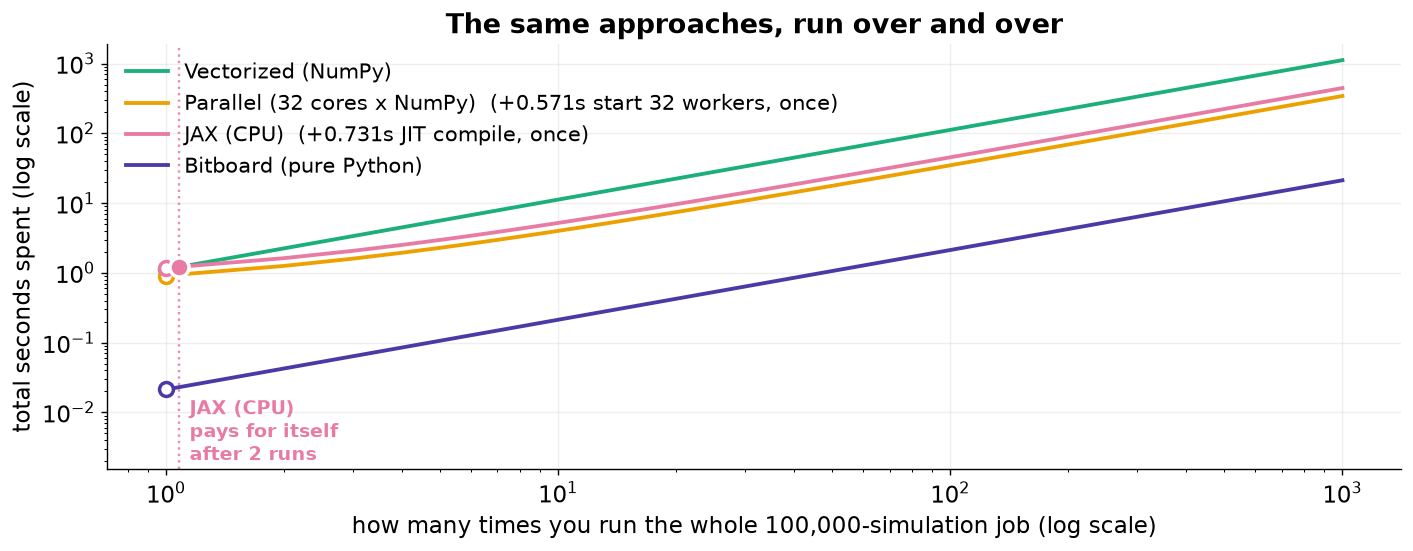

Measured on THIS machine, against NumPy (which has no setup to work off):
  - Parallel (32 cores x NumPy): ahead of NumPy from the very first run - its setup is smaller than what one run saves.
  - JAX (CPU): takes 2 runs to work off its 0.731s of setup, then it's ahead of NumPy for good.


In [226]:
# CHART - read the picture, skip the code.
# If you run the whole job N times, what does it cost in total?
#   total(N) = setup (paid once)  +  N x (moving data + math)
# A shallow line means cheap repeats; a line that starts high has a setup bill to
# work off first. Where two lines cross, the winner changes.
runs = np.unique(np.round(np.logspace(0, 3, 90)).astype(int))

fig, ax = plt.subplots(figsize=(11.5, 4.6))
per_run = {}
for name, p in rows:
    per_run[name] = p["moving"] + p["math"]
    label = name.replace("\n", " ")
    if p["setup"] > 0:
        label += f"  (+{fmt_seconds(p['setup'])} {p['setup_label']}, once)"
    ax.plot(runs, p["setup"] + runs * per_run[name], lw=2.2,
            color=p["color"], label=label, zorder=2)
    # The hollow dot at N=1 is the same cold-run number as the last mark on the
    # previous chart. This is where every line starts.
    ax.plot(1, p["setup"] + per_run[name], "o", ms=8, mfc="white",
            mec=p["color"], mew=2, zorder=3)

# Where does a setup cost actually pay for itself? Compare against NumPy: no setup
# at all, so it is the thing you'd reach for if you were only running this once.
REF = "Vectorized\n(NumPy)"
verdicts, crossings = [], []
for name, p in rows:
    if name == REF or p["setup"] <= 0:
        continue
    saved = per_run[REF] - per_run[name]
    plain = name.replace("\n", " ")
    if saved <= 0:
        verdicts.append(f"{plain}: never catches NumPy - each run costs more, so the gap only grows.")
        continue
    n_star = p["setup"] / saved
    if n_star <= 1:
        verdicts.append(f"{plain}: ahead of NumPy from the very first run - "
                        f"its setup is smaller than what one run saves.")
    else:
        cross = p["setup"] + n_star * per_run[name]
        ax.plot(n_star, cross, "o", ms=11, color=p["color"],
                mec="white", mew=2, zorder=4)
        # Drop a line to the axis and label it down there, where nothing else lives -
        # the same trick the worker-count chart used for the physical-core mark.
        ax.axvline(n_star, color=p["color"], ls=":", lw=1.4, alpha=0.85, zorder=1)
        n_runs = int(np.ceil(n_star))        # you cannot run something 1.4 times
        crossings.append((n_star, n_runs, name.replace("\n", " "), p["color"]))
        verdicts.append(f"{plain}: takes {n_runs} runs to work off its "
                        f"{fmt_seconds(p['setup'])} of setup, then it's ahead of NumPy for good.")

ax.set_xscale("log"); ax.set_yscale("log")
# Only sink the axis floor if there are break-even labels that need somewhere to
# live down there. On a machine with no crossings, that strip is just dead space.
floor = min(p["setup"] + per_run[n] for n, p in rows) / (14 if crossings else 2.5)
ax.set_ylim(bottom=floor)
for n_star, n_runs, plain, colour in crossings:   # labels sit in the empty strip at the bottom
    ax.annotate(f"{plain}\npays for itself\nafter {n_runs} runs",
                (n_star, floor * 1.1), ha="left", va="bottom", fontsize=11,
                fontweight="bold", color=colour,
                textcoords="offset points", xytext=(6, 0))
ax.set_xlabel(f"how many times you run the whole {n_simulations:,}-simulation job (log scale)")
ax.set_ylabel("total seconds spent (log scale)")
ax.set_title("The same approaches, run over and over", fontweight="bold")
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.grid(True, which="major", alpha=0.2, lw=0.8)
ax.legend(loc="upper left", frameon=False, fontsize=12)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

print("Measured on THIS machine, against NumPy (which has no setup to work off):")
for v in verdicts:
    print("  -", v)


**Every line ends up as the same straight diagonal - what matters is where each one *starts*,
and how long it takes to settle onto that diagonal.** Far enough to the right, doubling the runs
doubles the time for all of them; that's what the shared slope means. The interesting part is the
left edge. A line that begins high has a setup bill it hasn't worked off yet, and a line that
begins low but sits above another one is simply losing every run on merit. An approach can lose
the first race and still win the marathon - but only if its setup is what's holding it back.

That gives you a genuinely useful rule, and it is not "use the fastest thing":

| If you are going to run it... | Reach for |
| --- | --- |
| **once** | whatever has the least machinery. Setup you never amortize is just waiting. |
| **a few times, while you're still writing it** | the same. Debugging beats benchmarking early on. |
| **hundreds of times, unchanged** | the steepest setup you can stomach - it stops mattering fast. |

Three things worth carrying out of this section:

1. **A benchmark that includes setup is measuring a different question.** Both questions are
   real. "How long until I see an answer *right now*" and "how long will a thousand of these
   take" have different winners, and the only way to be wrong is to not say which one you asked.
2. **"One-time" is a promise about reuse, not about the clock.** Our parallel run pays hiring
   *every single time*, because the code builds a fresh pool and throws it away. Keep the pool
   alive between runs and that cost becomes genuinely one-time - which is exactly the assumption
   the chart above makes for it. Same machine, same code, different answer, entirely because of
   when you throw the workers away.
3. **Moving data is nobody's favourite part and it never goes away.** Setup amortizes. Copying
   answers back does not. On a GPU it is often the part that ends up deciding the race, which is
   why the trick with real accelerators is to keep the data *there* and do more work on it,
   rather than shuttling it back and forth.

And the champion of the whole notebook has none of the three. No setup, no transfer, no library -
just a smaller pile of arithmetic. **The cheapest machinery is the machinery you found a way not
to need.**


## Coins <-> Bytes - The Last Idea

*~2 min · 3 cells · the last word*

A big integer and raw **bytes** are two views of the exact same bits:


In [227]:
data = flips.to_bytes(63, 'big')        # 500 bits fit in 63 bytes
back = int.from_bytes(data, 'big')      # ...and turn the bytes back into the number
print(f"As bytes: {len(data)} bytes")
print(f"Round-trips exactly? {back == flips}")

As bytes: 63 bytes
Round-trips exactly? True


This is how everything on a computer really works: images, network packets, and files are bits grouped into bytes and *interpreted*. Coins all the way down.

**Why this is the perfect ending.** We kept asking "what's the best representation of a coin?" and kept finding faster ones. The densest is a single bit - and once coins are bits, the machine's native tools (`getrandbits`, `bit_count`, hardware POPCNT) do the work almost for free: no NumPy, no GPU, no imports.

That's the whole notebook in one idea: **choose the representation the machine already loves, and the speed comes for free.**